# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term Group Project Template

**Team Members:** Huy Nguyen
**Date:** 04/01/2026
**GitHub Repository:** https://github.com/Huynguyen-175/ITAI2373-NewsBot-Midterm

---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [x] **Module 1:** NLP applications and real-world context
- [x] **Module 2:** Text preprocessing pipeline
- [x] **Module 3:** TF-IDF feature extraction
- [x] **Module 4:** POS tagging analysis
- [x] **Module 5:** Syntax parsing and semantic analysis
- [x] **Module 6:** Sentiment and emotion analysis
- [x] **Module 7:** Text classification system
- [x] **Module 8:** Named Entity Recognition

---

## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [1]:
# Install required packages (run this cell first!)
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 32.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


✅ All packages installed successfully!


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


## 📊 Data Loading and Exploration

### 🎯 Module 1: Understanding Our NLP Application

Before we dive into the technical implementation, let's understand the real-world context of our NewsBot Intelligence System. This system addresses several business needs:

1. **Media Monitoring:** Automatically categorize and track news coverage
2. **Business Intelligence:** Extract key entities and sentiment trends
3. **Content Management:** Organize large volumes of news content
4. **Market Research:** Understand public sentiment about topics and entities

**💡 Discussion Question:** What other real-world applications can you think of for this type of system? Consider different industries and use cases.

In [16]:
# ============================================================
# KAGGLE API SETUP
# ============================================================
# STEP 1: Install Kaggle API
!pip install kaggle

# STEP 2: Upload kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# STEP 3: Set up API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API setup complete!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (2).json
✅ Kaggle API setup complete!


In [18]:
# ============================================================
# LOAD DATASET IN GOOGLE COLAB
# >>> Here I'm using BBC News Dataset
# ============================================================
# STEP 1: Download and unzip
!kaggle competitions download -c learn-ai-bbc --force
!unzip -o learn-ai-bbc.zip
!ls -la

# STEP 2: Load with correct column names
import pandas as pd
import os

print("Available CSV files:")
for file in os.listdir('.'):
    if file.endswith('.csv'):
        print(f"  - {file}")

df = pd.read_csv('BBC News Train.csv')  # ✅ Correct filename for this dataset
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# BBC dataset uses 'Category' (capital C) not 'category'
print(f"Categories: {df['Category'].unique()}")

100% 1.85M/1.85M [00:00<00:00, 137MB/s]

Archive:  learn-ai-bbc.zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      
total 10252
drwxr-xr-x 1 root root    4096 Apr  1 15:43  .
drwxr-xr-x 1 root root    4096 Apr  1 15:09  ..
-rw-r--r-- 1 root root   10369 Dec  2  2019 'BBC News Sample Solution.csv'
-rw-r--r-- 1 root root 1712432 Dec  2  2019 'BBC News Test.csv'
-rw-r--r-- 1 root root 3351206 Dec  2  2019 'BBC News Train.csv'
drwxr-xr-x 4 root root    4096 Mar 30 13:29  .config
-rw-r--r-- 1 root root  205333 Apr  1 15:38  dataset_overview.png
-rw-r--r-- 1 root root      69 Apr  1 15:28 'kaggle (1).json'
-rw-r--r-- 1 root root      69 Apr  1 15:41 'kaggle (2).json'
-rw-r--r-- 1 root root      69 Apr  1 15:24  kaggle.json
-rw-r--r-- 1 root root 1936538 Dec  2  2019  learn-ai-bbc.zip
-rw-r--r-- 1 root root 3238496 Apr  1 15:34  newsbot_dataset.csv
drwxr-xr-x 1 root root    4096 Mar 30 13:29  sample_data
Available CSV fil

📊 DATASET OVERVIEW
Total articles     : 1440
Unique categories  : 5
Categories         : ['business', 'entertainment', 'politics', 'sport', 'tech']
Columns            : ['article_id', 'content', 'category']
Date range         : ℹ️ No date column in this dataset
Unique sources     : ℹ️ No source column in this dataset

🔍 MISSING VALUES
article_id    0
content       0
category      0
dtype: int64
✅ No missing values found

📈 CATEGORY DISTRIBUTION
category
sport            342
business         335
politics         266
entertainment    263
tech             234
Name: count, dtype: int64

Most common  : sport (342 articles)
Least common : tech (234 articles)
Balance ratio: 0.68 (⚠️ Slightly imbalanced)

📏 TEXT LENGTH DISTRIBUTION
       char_count  word_count
count      1440.0      1440.0
mean       2234.3       385.2
std        1211.7       212.2
min         501.0        90.0
25%        1451.2       253.0
50%        1964.0       337.0
75%        2754.0       468.2
max       18387.0      334

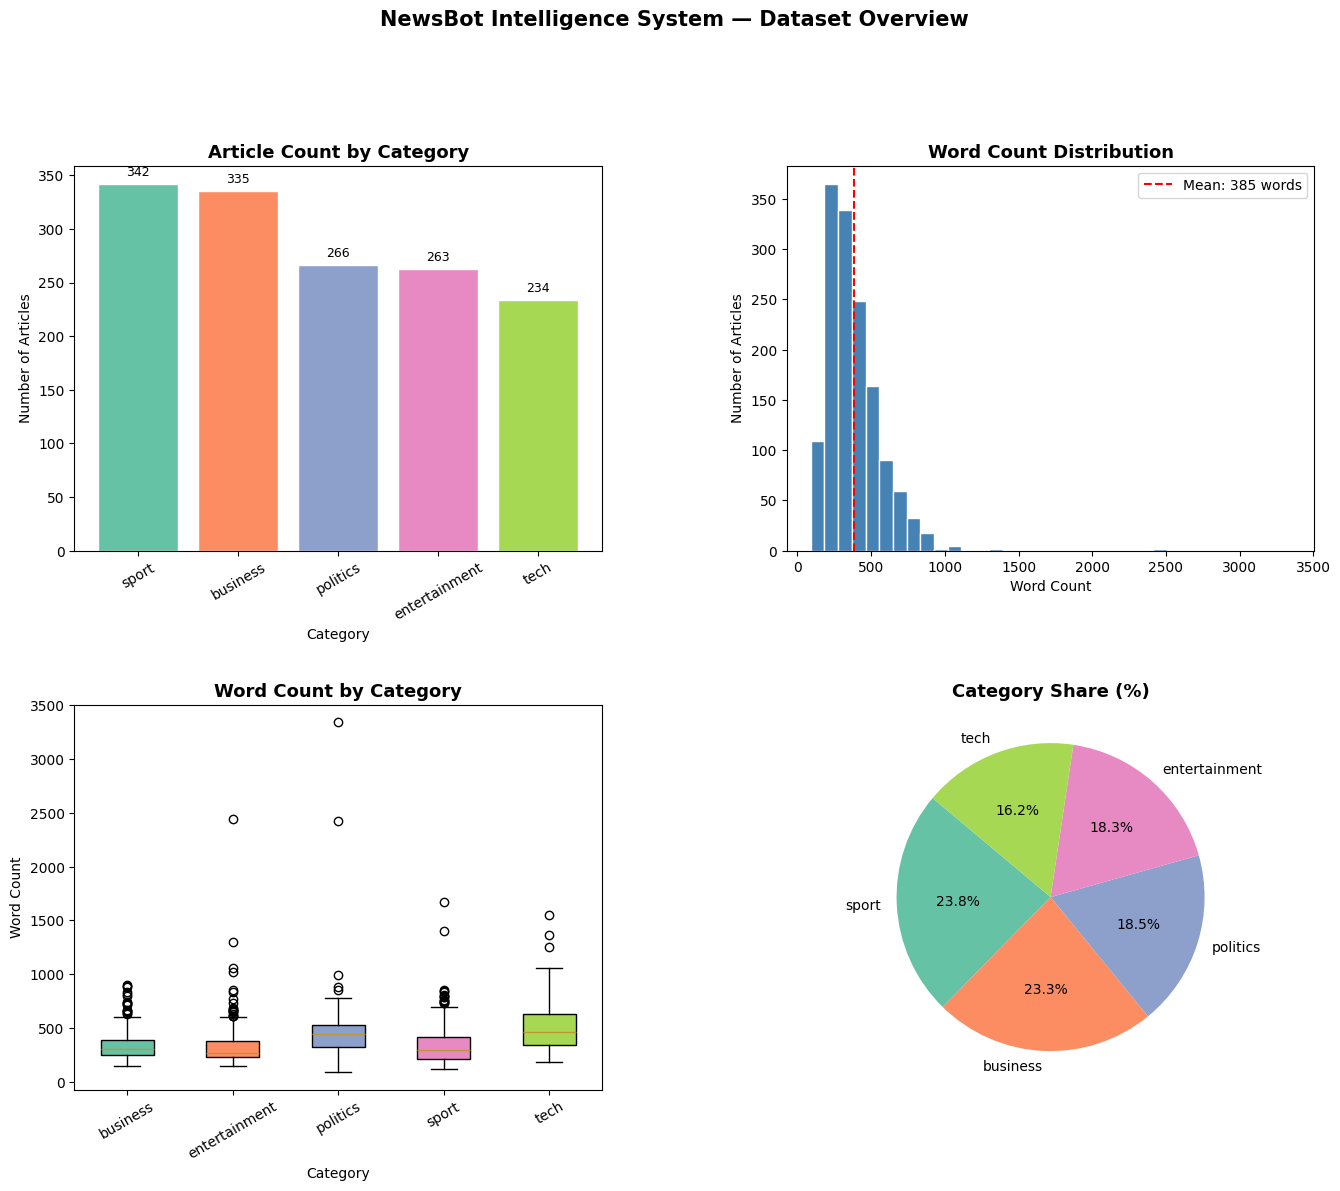


✅ All visualizations saved as 'dataset_overview.png'
✅ Exploratory analysis complete — ready for Module 2!


In [19]:
# ============================================================
# MODULE 1: DATASET EXPLORATION & BUSINESS CONTEXT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Load dataset ───────────────────────────────────────────
df = pd.read_csv('newsbot_dataset.csv')

# ============================================================
# SECTION 1: DATASET OVERVIEW
# ============================================================
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total articles     : {len(df)}")
print(f"Unique categories  : {df['category'].nunique()}")
print(f"Categories         : {sorted(df['category'].unique().tolist())}")
print(f"Columns            : {df.columns.tolist()}")

# ── Handle optional columns gracefully ────────────────────
if 'date' in df.columns:
    print(f"Date range         : {df['date'].min()} to {df['date'].max()}")
else:
    print("Date range         : ℹ️ No date column in this dataset")

if 'source' in df.columns:
    print(f"Unique sources     : {df['source'].nunique()}")
else:
    print("Unique sources     : ℹ️ No source column in this dataset")

# ============================================================
# SECTION 2: MISSING VALUES CHECK
# ============================================================
print("\n🔍 MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("✅ No missing values found")
else:
    print(f"⚠️ Total missing values: {missing.sum()} — dropping affected rows")
    df = df.dropna(subset=['content', 'category']).reset_index(drop=True)
    print(f"✅ Rows after cleaning: {len(df)}")

# ============================================================
# SECTION 3: CATEGORY DISTRIBUTION
# ============================================================
print("\n📈 CATEGORY DISTRIBUTION")
print("=" * 50)
category_counts = df['category'].value_counts()
print(category_counts)
print(f"\nMost common  : {category_counts.idxmax()} ({category_counts.max()} articles)")
print(f"Least common : {category_counts.idxmin()} ({category_counts.min()} articles)")
balance_ratio = category_counts.min() / category_counts.max()
print(f"Balance ratio: {balance_ratio:.2f} ({'✅ Balanced' if balance_ratio > 0.7 else '⚠️ Slightly imbalanced'})")

# ============================================================
# SECTION 4: TEXT LENGTH DISTRIBUTION
# ============================================================
print("\n📏 TEXT LENGTH DISTRIBUTION")
print("=" * 50)
df['char_count'] = df['content'].str.len()
df['word_count']  = df['content'].str.split().str.len()

stats = df[['char_count', 'word_count']].describe().round(1)
print(stats)

print(f"\nArticles < 50 words  : {(df['word_count'] < 50).sum()} (potential junk)")
print(f"Articles > 800 words : {(df['word_count'] > 800).sum()} (long-form)")

# ── Word count per category ────────────────────────────────
print("\n📐 AVG WORD COUNT BY CATEGORY")
print("=" * 50)
print(df.groupby('category')['word_count']
        .agg(['mean', 'min', 'max'])
        .round(0)
        .rename(columns={'mean':'Avg','min':'Min','max':'Max'}))

# ============================================================
# SECTION 5: SOURCE DISTRIBUTION (if available)
# ============================================================
if 'source' in df.columns:
    print("\n📰 SOURCE DISTRIBUTION")
    print("=" * 50)
    source_counts = df['source'].value_counts()
    print(source_counts.head(10))
else:
    print("\n📰 SOURCE DISTRIBUTION")
    print("=" * 50)
    print("ℹ️ BBC News dataset — single source (BBC)")
    print("   All articles originate from bbc.co.uk")

# ============================================================
# SECTION 6: DATA QUALITY SUMMARY
# ============================================================
print("\n🛡️ DATA QUALITY SUMMARY")
print("=" * 50)
dupes = df.duplicated(subset=['content']).sum()
short = (df['word_count'] < 20).sum()
long  = (df['word_count'] > 1000).sum()
print(f"Duplicate articles    : {dupes}  {'✅' if dupes == 0 else '⚠️ remove these'}")
print(f"Very short (< 20 wds) : {short}  {'✅' if short == 0 else '⚠️ review these'}")
print(f"Very long  (>1000 wds): {long}  {'✅' if long == 0 else 'ℹ️ acceptable'}")
print(f"Total usable articles : {len(df)}")

# ============================================================
# SECTION 7: VISUALIZATIONS
# ============================================================
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Category distribution bar chart ───────────────
ax1 = fig.add_subplot(gs[0, 0])
colors = sns.color_palette("Set2", len(category_counts))
bars = ax1.bar(category_counts.index, category_counts.values, color=colors, edgecolor='white')
ax1.set_title('Article Count by Category', fontsize=13, fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Number of Articles')
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, category_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9)

# ── Plot 2: Word count histogram ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['word_count'], bins=35, color='steelblue', edgecolor='white')
ax2.axvline(df['word_count'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['word_count'].mean():.0f} words")
ax2.set_title('Word Count Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Number of Articles')
ax2.legend()

# ── Plot 3: Boxplot — word count by category ──────────────
ax3 = fig.add_subplot(gs[1, 0])
categories = sorted(df['category'].unique())
data_by_cat = [df[df['category'] == c]['word_count'].values for c in categories]
bp = ax3.boxplot(data_by_cat, labels=categories, patch_artist=True)
for patch, color in zip(bp['boxes'], sns.color_palette("Set2", len(categories))):
    patch.set_facecolor(color)
ax3.set_title('Word Count by Category', fontsize=13, fontweight='bold')
ax3.set_xlabel('Category')
ax3.set_ylabel('Word Count')
ax3.tick_params(axis='x', rotation=30)

# ── Plot 4: Category share pie chart ──────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.pie(category_counts.values,
        labels=category_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("Set2", len(category_counts)),
        startangle=140)
ax4.set_title('Category Share (%)', fontsize=13, fontweight='bold')

plt.suptitle('NewsBot Intelligence System — Dataset Overview',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ All visualizations saved as 'dataset_overview.png'")
print("✅ Exploratory analysis complete — ready for Module 2!")

## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

In [20]:
# ============================================================
# MODULE 2: TEXT PREPROCESSING PIPELINE
# ============================================================
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# ── Step 1: Text Cleaning ──────────────────────────────────
def clean_text(text):
    """
    Comprehensive text cleaning function.
    Handles: HTML, URLs, emails, special characters, whitespace.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ── Step 2: Full Preprocessing Pipeline ───────────────────
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline:
    clean → tokenize → remove stopwords → lemmatize → filter short words
    """
    text = clean_text(text)

    if not text:
        return ""

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]

    # Lemmatize
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Filter very short tokens
    tokens = [t for t in tokens if len(t) > 2]

    return ' '.join(tokens)

# ── Step 3: Quick Sanity Test ──────────────────────────────
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. <b>Breaking:</b> #TechNews CEO said 'we're growing fast'"

print("🧪 PREPROCESSING FUNCTION TEST")
print("=" * 60)
print(f"Original  : {sample_text}")
print(f"Cleaned   : {clean_text(sample_text)}")
print(f"Processed : {preprocess_text(sample_text)}")
print("\n✅ Preprocessing functions ready!")

🧪 PREPROCESSING FUNCTION TEST
Original  : Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. <b>Breaking:</b> #TechNews CEO said 'we're growing fast'
Cleaned   : apple inc announced record quarterly earnings today visit for more info breaking technews ceo said were growing fast
Processed : apple inc announced record quarterly earnings today visit info breaking technews ceo said growing fast

✅ Preprocessing functions ready!


🧹 Preprocessing all articles...
✅ Preprocessing complete!

📝 BEFORE AND AFTER EXAMPLES

Example 1 [BUSINESS]:
  Original  : worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charg...
  Processed : worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company ...

Example 2 [BUSINESS]:
  Original  : german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in eur...
  Processed : german business confidence slide german business confidence fell february knocking hope speedy recovery europe largest e...

Example 3 [BUSINESS]:
  Original  : bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc world service poll believe the wor...
  Processed : bbc poll indicates economic gloom citizen majority nation surveyed bbc world service poll believe world economy worsenin...

📏 1. TEXT LENGT

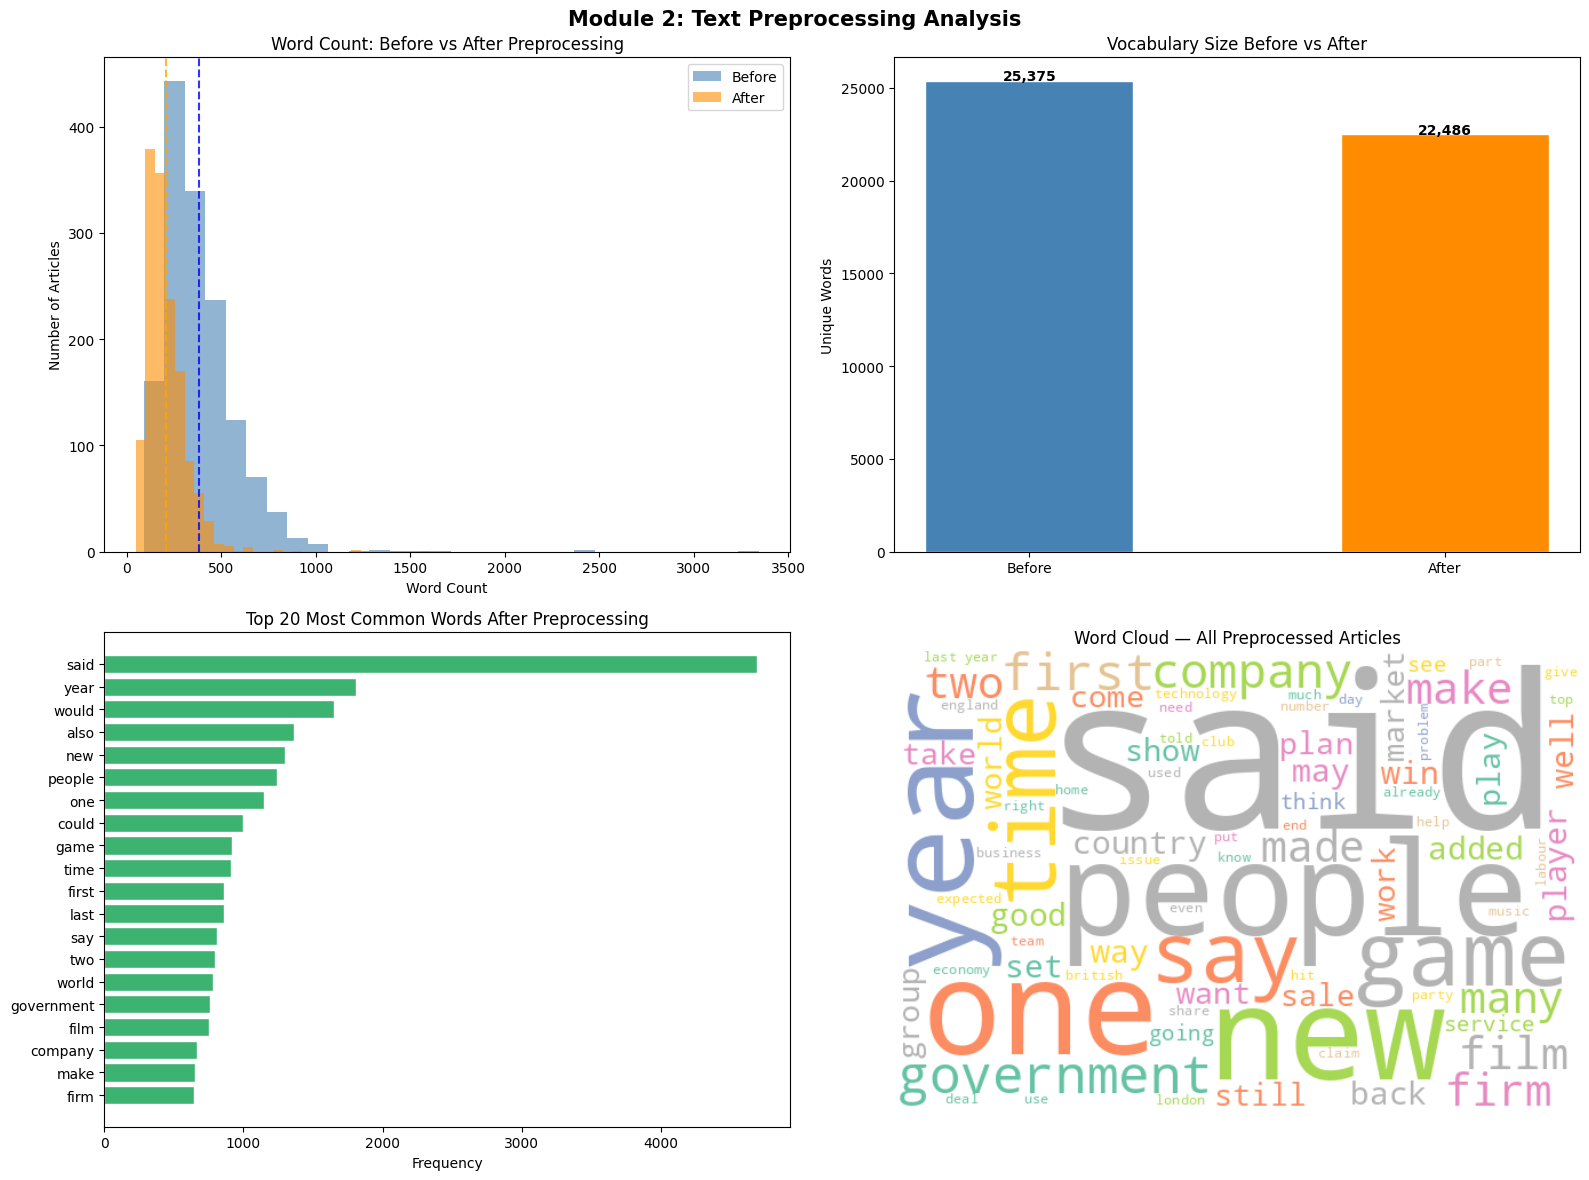


✅ Visualizations saved as 'module2_preprocessing.png'
✅ Module 2 complete — ready for Module 3!


In [21]:
# ============================================================
# MODULE 2: APPLY PREPROCESSING + ANALYSIS
# ============================================================
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

print("🧹 Preprocessing all articles...")
print("=" * 60)

# ── Apply preprocessing ────────────────────────────────────
# NOTE: BBC dataset has only 'content', no 'title' column
df['content_clean']     = df['content'].apply(clean_text)
df['content_processed'] = df['content'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# ── Before & After Examples ───────────────────────────────
print("\n📝 BEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(3):
    print(f"\nExample {i+1} [{df.iloc[i]['category'].upper()}]:")
    print(f"  Original  : {df.iloc[i]['content'][:120]}...")
    print(f"  Processed : {df.iloc[i]['content_processed'][:120]}...")

# ============================================================
# STUDENT TASK: PREPROCESSING ANALYSIS
# ============================================================

# ── 1. Text length before vs after ────────────────────────
print("\n📏 1. TEXT LENGTH — BEFORE vs AFTER")
print("=" * 60)
df['len_before'] = df['content'].str.split().str.len()
df['len_after']  = df['content_processed'].str.split().str.len()
df['reduction']  = ((df['len_before'] - df['len_after']) / df['len_before'] * 100).round(1)

print(f"  Avg words BEFORE : {df['len_before'].mean():.0f}")
print(f"  Avg words AFTER  : {df['len_after'].mean():.0f}")
print(f"  Avg reduction    : {df['reduction'].mean():.1f}%")
print(f"  Min words after  : {df['len_after'].min()}")
print(f"  Max words after  : {df['len_after'].max()}")

# ── 2. Unique vocabulary before vs after ──────────────────
print("\n📚 2. VOCABULARY SIZE — BEFORE vs AFTER")
print("=" * 60)
all_words_before = ' '.join(df['content_clean']).split()
all_words_after  = ' '.join(df['content_processed']).split()

vocab_before = len(set(all_words_before))
vocab_after  = len(set(all_words_after))
print(f"  Unique words BEFORE : {vocab_before:,}")
print(f"  Unique words AFTER  : {vocab_after:,}")
print(f"  Vocabulary reduction: {((vocab_before - vocab_after)/vocab_before*100):.1f}%")
print(f"  Total tokens BEFORE : {len(all_words_before):,}")
print(f"  Total tokens AFTER  : {len(all_words_after):,}")

# ── 3. Most common words after preprocessing ──────────────
print("\n🔤 3. TOP 20 MOST COMMON WORDS (after preprocessing)")
print("=" * 60)
word_freq = Counter(all_words_after)
top_20 = word_freq.most_common(20)
for word, count in top_20:
    bar = '█' * (count // 100)
    print(f"  {word:<20} {count:>5}  {bar}")

# ── 4. Most common words per category ─────────────────────
print("\n📊 4. TOP 5 WORDS PER CATEGORY")
print("=" * 60)
for cat in sorted(df['category'].unique()):
    cat_text = ' '.join(df[df['category'] == cat]['content_processed'])
    cat_freq = Counter(cat_text.split()).most_common(5)
    words = [w for w, _ in cat_freq]
    print(f"  {cat:<15}: {', '.join(words)}")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Module 2: Text Preprocessing Analysis', fontsize=15, fontweight='bold')

# ── Plot 1: Word count before vs after (histogram) ────────
axes[0,0].hist(df['len_before'], bins=30, alpha=0.6, color='steelblue', label='Before')
axes[0,0].hist(df['len_after'],  bins=30, alpha=0.6, color='darkorange', label='After')
axes[0,0].axvline(df['len_before'].mean(), color='blue',   linestyle='--', alpha=0.8)
axes[0,0].axvline(df['len_after'].mean(),  color='orange', linestyle='--', alpha=0.8)
axes[0,0].set_title('Word Count: Before vs After Preprocessing')
axes[0,0].set_xlabel('Word Count')
axes[0,0].set_ylabel('Number of Articles')
axes[0,0].legend()

# ── Plot 2: Vocabulary reduction bar ──────────────────────
axes[0,1].bar(['Before', 'After'], [vocab_before, vocab_after],
              color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
axes[0,1].set_title('Vocabulary Size Before vs After')
axes[0,1].set_ylabel('Unique Words')
for i, v in enumerate([vocab_before, vocab_after]):
    axes[0,1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# ── Plot 3: Top 20 most common words bar chart ────────────
words_plot  = [w for w, _ in top_20]
counts_plot = [c for _, c in top_20]
axes[1,0].barh(words_plot[::-1], counts_plot[::-1], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Top 20 Most Common Words After Preprocessing')
axes[1,0].set_xlabel('Frequency')

# ── Plot 4: Word cloud ─────────────────────────────────────
wc = WordCloud(width=600, height=400,
               background_color='white',
               colormap='Set2',
               max_words=80).generate(' '.join(all_words_after))
axes[1,1].imshow(wc, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('Word Cloud — All Preprocessed Articles')

plt.tight_layout()
plt.savefig('module2_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualizations saved as 'module2_preprocessing.png'")
print("✅ Module 2 complete — ready for Module 3!")

## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [24]:
# ============================================================
# MODULE 3: TF-IDF FEATURE EXTRACTION AND ANALYSIS
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("📊 MODULE 3: TF-IDF FEATURE EXTRACTION")
print("=" * 60)

# ── Step 1: Build TF-IDF Vectorizer ───────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,       # Top 5000 most important terms
    ngram_range=(1, 2),      # Unigrams and bigrams
    min_df=2,                # Ignore terms in fewer than 2 docs
    max_df=0.95,             # Ignore terms in more than 95% of docs
    sublinear_tf=True        # Apply log normalization to TF
)

# Fit and transform on processed content
tfidf_matrix = tfidf_vectorizer.fit_transform(df['content_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix shape     : {tfidf_matrix.shape}")
print(f"   Articles (rows)        : {tfidf_matrix.shape[0]}")
print(f"   Features/terms (cols)  : {tfidf_matrix.shape[1]}")
print(f"   Matrix sparsity        : {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}")
print(f"   N-gram range           : (1, 2) — unigrams + bigrams")
print(f"   Vocabulary size        : {len(feature_names):,} terms")

# ── Step 2: Global Top Terms ───────────────────────────────
print("\n🔤 TOP 20 GLOBAL TF-IDF TERMS")
print("=" * 60)
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_global_idx = mean_tfidf.argsort()[::-1][:20]
for i, idx in enumerate(top_global_idx, 1):
    print(f"  {i:>2}. {feature_names[idx]:<30} score: {mean_tfidf[idx]:.5f}")

# ── Step 3: Parameter Comparison ──────────────────────────
print("\n⚙️ PARAMETER OPTIMIZATION COMPARISON")
print("=" * 60)
configs = [
    {"max_features": 1000, "ngram_range": (1,1), "label": "1000 features, unigrams"},
    {"max_features": 3000, "ngram_range": (1,1), "label": "3000 features, unigrams"},
    {"max_features": 5000, "ngram_range": (1,2), "label": "5000 features, uni+bigrams ✅ (chosen)"},
    {"max_features": 8000, "ngram_range": (1,2), "label": "8000 features, uni+bigrams"},
]
for cfg in configs:
    v = TfidfVectorizer(max_features=cfg['max_features'],
                        ngram_range=cfg['ngram_range'],
                        min_df=2, max_df=0.95)
    m = v.fit_transform(df['content_processed'])
    sparsity = 1 - m.nnz / (m.shape[0] * m.shape[1])
    print(f"  {cfg['label']}")
    print(f"    → Shape: {m.shape} | Sparsity: {sparsity:.2%}")

📊 MODULE 3: TF-IDF FEATURE EXTRACTION
✅ TF-IDF matrix shape     : (1440, 5000)
   Articles (rows)        : 1440
   Features/terms (cols)  : 5000
   Matrix sparsity        : 97.48%
   N-gram range           : (1, 2) — unigrams + bigrams
   Vocabulary size        : 5,000 terms

🔤 TOP 20 GLOBAL TF-IDF TERMS
   1. said                           score: 0.03531
   2. year                           score: 0.02398
   3. would                          score: 0.02163
   4. also                           score: 0.02028
   5. new                            score: 0.01961
   6. one                            score: 0.01826
   7. people                         score: 0.01781
   8. last                           score: 0.01716
   9. could                          score: 0.01684
  10. time                           score: 0.01648
  11. first                          score: 0.01636
  12. two                            score: 0.01550
  13. game                           score: 0.01530
  14. world       

🏷️ TOP 10 TF-IDF TERMS BY CATEGORY

  📁 BUSINESS
      1. said                           0.04064
      2. firm                           0.03869
      3. company                        0.03793
      4. market                         0.03564
      5. year                           0.03268
      6. share                          0.03067
      7. growth                         0.02964
      8. economy                        0.02838
      9. bank                           0.02815
     10. sale                           0.02682

  📁 ENTERTAINMENT
      1. film                           0.06379
      2. award                          0.04181
      3. star                           0.03905
      4. show                           0.03286
      5. actor                          0.03210
      6. best                           0.03133
      7. music                          0.03057
      8. year                           0.02956
      9. said                           0.02949
     10. band       

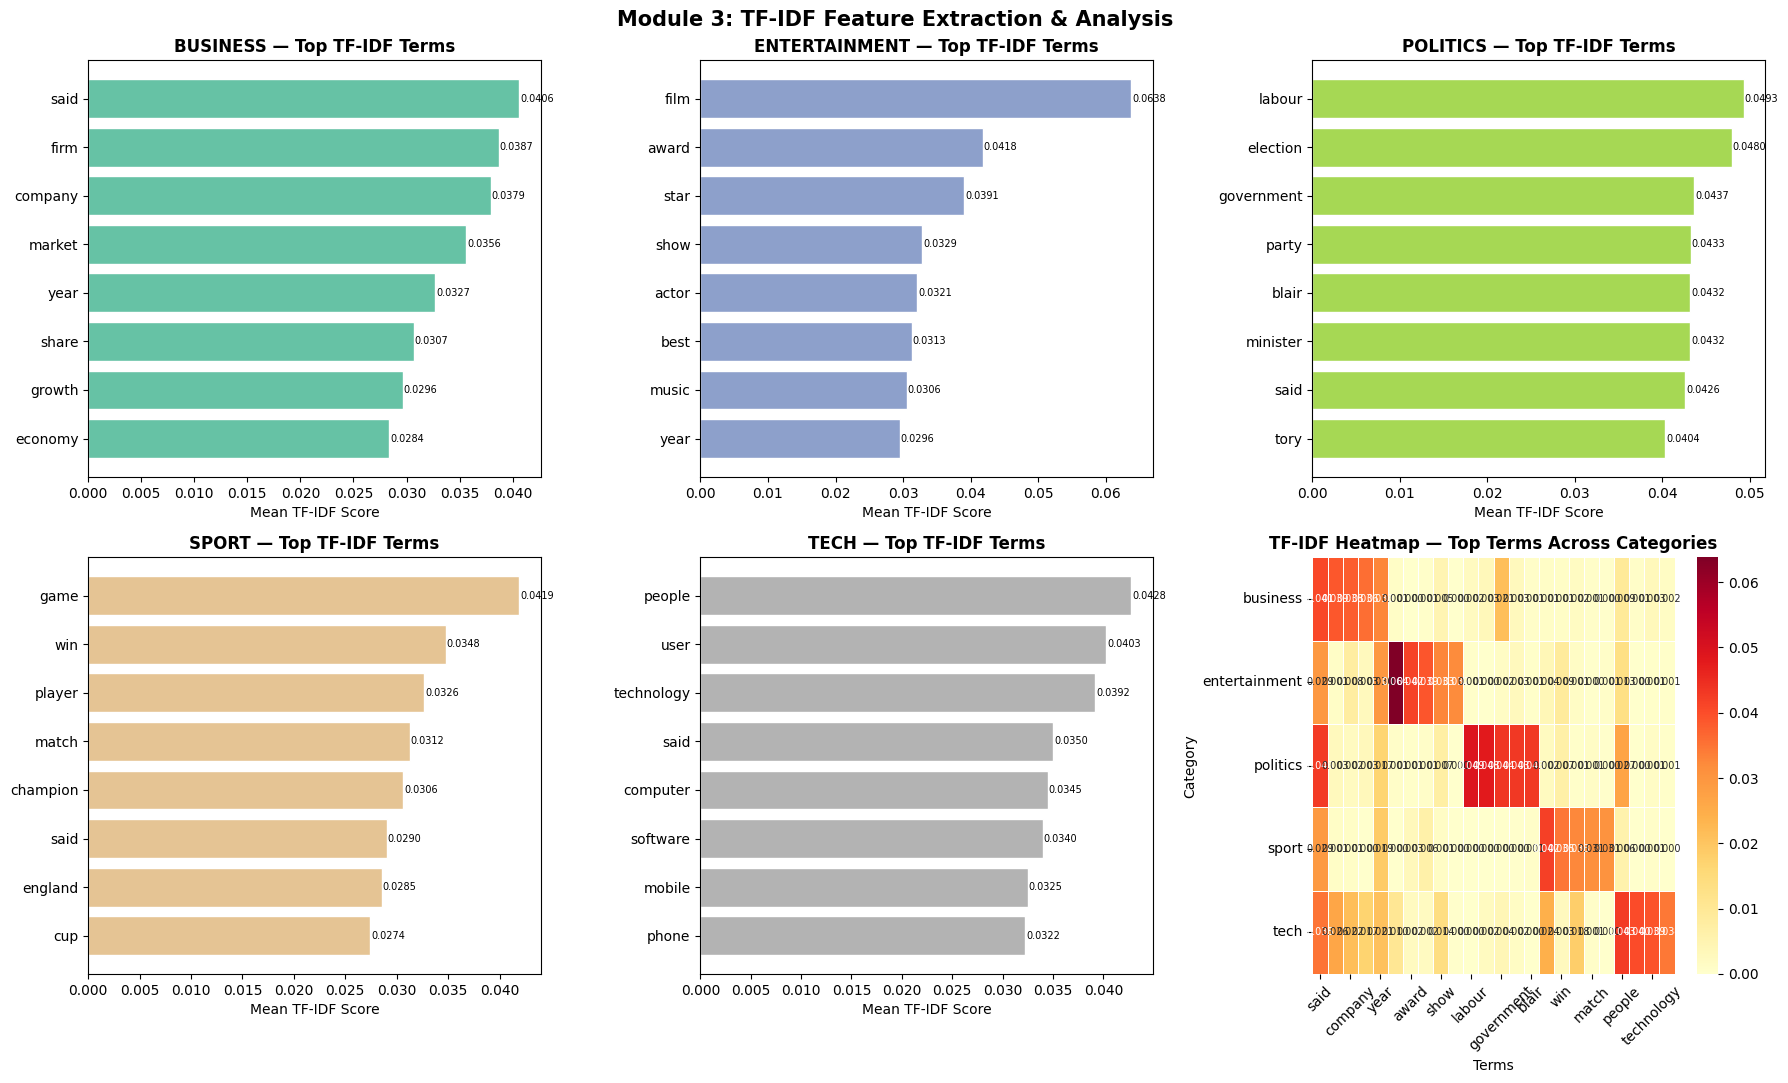

✅ Visualizations saved as 'module3_tfidf.png'


In [25]:
# ============================================================
# MODULE 3: CATEGORY-SPECIFIC TERM ANALYSIS & VISUALIZATION
# ============================================================

# ── Step 1: Top Terms Per Category ────────────────────────
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category
    by averaging TF-IDF scores across all articles in that category.
    """
    # Get indices of articles in this category
    cat_indices = df[df['category'] == category].index.tolist()

    # Get TF-IDF scores for those articles
    cat_matrix = tfidf_matrix[cat_indices]

    # Average TF-IDF score per term
    mean_scores = np.asarray(cat_matrix.mean(axis=0)).flatten()

    # Get top N indices
    top_indices = mean_scores.argsort()[::-1][:n_terms]

    return [(feature_names[i], mean_scores[i]) for i in top_indices]

# Print top terms per category
print("🏷️ TOP 10 TF-IDF TERMS BY CATEGORY")
print("=" * 60)
categories = sorted(df['category'].unique())
category_terms = {}

for cat in categories:
    terms = get_top_tfidf_terms(cat, n_terms=10)
    category_terms[cat] = terms
    print(f"\n  📁 {cat.upper()}")
    for rank, (term, score) in enumerate(terms, 1):
        print(f"     {rank:>2}. {term:<30} {score:.5f}")

# ── Step 2: Feature Importance ────────────────────────────
print("\n\n📊 FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Terms that are UNIQUE to each category (high score in one, low in others)
print("  Terms most distinctive per category (uniqueness score):")
all_cat_scores = {}
for cat in categories:
    indices = df[df['category'] == cat].index.tolist()
    scores  = np.asarray(tfidf_matrix[indices].mean(axis=0)).flatten()
    all_cat_scores[cat] = scores

score_matrix = np.array([all_cat_scores[c] for c in categories])

for i, cat in enumerate(categories):
    # Uniqueness = score in this category vs max score in other categories
    other_max = np.delete(score_matrix, i, axis=0).max(axis=0)
    uniqueness = score_matrix[i] - other_max
    top_unique_idx = uniqueness.argsort()[::-1][:5]
    unique_terms = [feature_names[j] for j in top_unique_idx]
    print(f"  {cat:<15}: {', '.join(unique_terms)}")

# ============================================================
# VISUALIZATIONS
# ============================================================
n_cats = len(categories)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Module 3: TF-IDF Feature Extraction & Analysis',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, n_cats))

# ── Plot 1–5: Top terms bar chart per category ────────────
for idx, (cat, color) in enumerate(zip(categories, colors)):
    ax = axes[idx]
    terms_scores = category_terms[cat]
    terms  = [t for t, _ in terms_scores][:8]
    scores = [s for _, s in terms_scores][:8]

    bars = ax.barh(terms[::-1], scores[::-1], color=color, edgecolor='white')
    ax.set_title(f'{cat.upper()} — Top TF-IDF Terms', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')
    for bar, score in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', va='center', fontsize=7)

# ── Plot 6: TF-IDF Heatmap — top 5 terms per category ────
ax6 = axes[5]
top5_terms_per_cat = {}
for cat in categories:
    top5_terms_per_cat[cat] = [t for t, _ in get_top_tfidf_terms(cat, 5)]

all_top_terms = list(dict.fromkeys(
    [t for terms in top5_terms_per_cat.values() for t in terms]
))

heatmap_data = pd.DataFrame(index=categories, columns=all_top_terms, dtype=float)
for cat in categories:
    indices = df[df['category'] == cat].index.tolist()
    scores  = np.asarray(tfidf_matrix[indices].mean(axis=0)).flatten()
    for term in all_top_terms:
        term_idx = np.where(feature_names == term)[0]
        heatmap_data.loc[cat, term] = scores[term_idx[0]] if len(term_idx) > 0 else 0.0

sns.heatmap(heatmap_data.astype(float),
            ax=ax6, cmap='YlOrRd',
            annot=True, fmt='.3f',
            linewidths=0.5, annot_kws={'size': 7})
ax6.set_title('TF-IDF Heatmap — Top Terms Across Categories', fontweight='bold')
ax6.set_xlabel('Terms')
ax6.set_ylabel('Category')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('module3_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualizations saved as 'module3_tfidf.png'")

## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [26]:
# ============================================================
# MODULE 4: PART-OF-SPEECH PATTERN ANALYSIS
# ============================================================
import nltk
from nltk import pos_tag, word_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── POS Tag Groups ─────────────────────────────────────────
# We group Penn Treebank tags into readable categories
POS_GROUPS = {
    'Noun':        ['NN', 'NNS', 'NNP', 'NNPS'],
    'Verb':        ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'],
    'Adjective':   ['JJ', 'JJR', 'JJS'],
    'Adverb':      ['RB', 'RBR', 'RBS'],
    'Pronoun':     ['PRP', 'PRP$', 'WP', 'WP$'],
    'Preposition': ['IN'],
    'Conjunction': ['CC'],
    'Determiner':  ['DT'],
    'Number':      ['CD'],
    'Modal':       ['MD'],
}

def get_pos_group(tag):
    """Map a Penn Treebank POS tag to a readable group."""
    for group, tags in POS_GROUPS.items():
        if tag in tags:
            return group
    return 'Other'

def analyze_pos_patterns(text):
    """
    Analyze POS patterns in text.
    Returns:
      - pos_counts      : raw count per POS group
      - pos_proportions : % of each POS group
      - pos_tags        : full list of (word, tag) tuples
      - top_nouns       : most common nouns
      - top_verbs       : most common verbs
      - top_adjectives  : most common adjectives
    """
    if not text or pd.isna(text):
        return None

    # Tokenize and tag
    tokens   = word_tokenize(str(text).lower())
    pos_tags = pos_tag(tokens)

    # Count by group
    pos_counts = defaultdict(int)
    nouns, verbs, adjectives = [], [], []

    for word, tag in pos_tags:
        group = get_pos_group(tag)
        pos_counts[group] += 1
        if group == 'Noun':        nouns.append(word)
        elif group == 'Verb':      verbs.append(word)
        elif group == 'Adjective': adjectives.append(word)

    total = sum(pos_counts.values()) or 1

    pos_proportions = {k: v / total for k, v in pos_counts.items()}

    return {
        'pos_counts':      dict(pos_counts),
        'pos_proportions': pos_proportions,
        'pos_tags':        pos_tags,
        'top_nouns':       Counter(nouns).most_common(5),
        'top_verbs':       Counter(verbs).most_common(5),
        'top_adjectives':  Counter(adjectives).most_common(5),
        'total_tokens':    total,
        'noun_verb_ratio': (pos_counts['Noun'] / pos_counts['Verb']
                            if pos_counts['Verb'] > 0 else 0),
    }

def extract_pos_ngrams(text, n=2):
    """
    Extract POS n-grams (sequences of POS tags).
    Useful for finding common grammatical patterns like Noun+Verb, Adj+Noun.
    """
    tokens   = word_tokenize(str(text).lower())
    pos_tags = pos_tag(tokens)
    tag_seq  = [get_pos_group(tag) for _, tag in pos_tags]

    ngrams = []
    for i in range(len(tag_seq) - n + 1):
        ngrams.append(tuple(tag_seq[i:i+n]))
    return ngrams

# ── Sanity Test ────────────────────────────────────────────
sample = "The prime minister announced a new economic policy to boost growth."
result = analyze_pos_patterns(sample)

print("🧪 POS ANALYSIS FUNCTION TEST")
print("=" * 60)
print(f"Sample text : {sample}")
print(f"\nPOS proportions:")
for pos, prop in sorted(result['pos_proportions'].items(),
                        key=lambda x: x[1], reverse=True):
    bar = '█' * int(prop * 40)
    print(f"  {pos:<15} {prop:.2%}  {bar}")
print(f"\nTop nouns      : {result['top_nouns']}")
print(f"Top verbs      : {result['top_verbs']}")
print(f"Top adjectives : {result['top_adjectives']}")
print(f"Noun/Verb ratio: {result['noun_verb_ratio']:.2f}")

🧪 POS ANALYSIS FUNCTION TEST
Sample text : The prime minister announced a new economic policy to boost growth.

POS proportions:
  Adjective       25.00%  ██████████
  Noun            25.00%  ██████████
  Determiner      16.67%  ██████
  Verb            16.67%  ██████
  Other           16.67%  ██████

Top nouns      : [('minister', 1), ('policy', 1), ('growth', 1)]
Top verbs      : [('announced', 1), ('boost', 1)]
Top adjectives : [('prime', 1), ('new', 1), ('economic', 1)]
Noun/Verb ratio: 1.50


🏷️ Running POS analysis on all articles...
(This may take 1–2 minutes)


  0%|          | 0/1440 [00:00<?, ?it/s]

✅ POS analysis complete!

📊 1. POS DISTRIBUTION BY CATEGORY
                 Noun    Verb  Adjective  Adverb  Preposition  Conjunction  Determiner   Modal
category                                                                                      
business       0.3227  0.1848     0.1053  0.0335       0.1324       0.0247      0.0998  0.0122
entertainment  0.3263  0.1832     0.1046  0.0330       0.1222       0.0278      0.0994  0.0098
politics       0.2936  0.2011     0.0975  0.0373       0.1180       0.0284      0.1037  0.0189
sport          0.2913  0.1944     0.1038  0.0427       0.1193       0.0307      0.0941  0.0134
tech           0.2969  0.1928     0.1005  0.0407       0.1234       0.0305      0.0974  0.0169

✍️  2. WRITING STYLE DIFFERENCES
  Category          Noun%   Verb%    Adj%    Adv%  N/V Ratio
  -------------------------------------------------------
  business         32.3%   18.5%   10.5%    3.4%       1.78
  entertainment    32.6%   18.3%   10.5%    3.3%       1.85
  

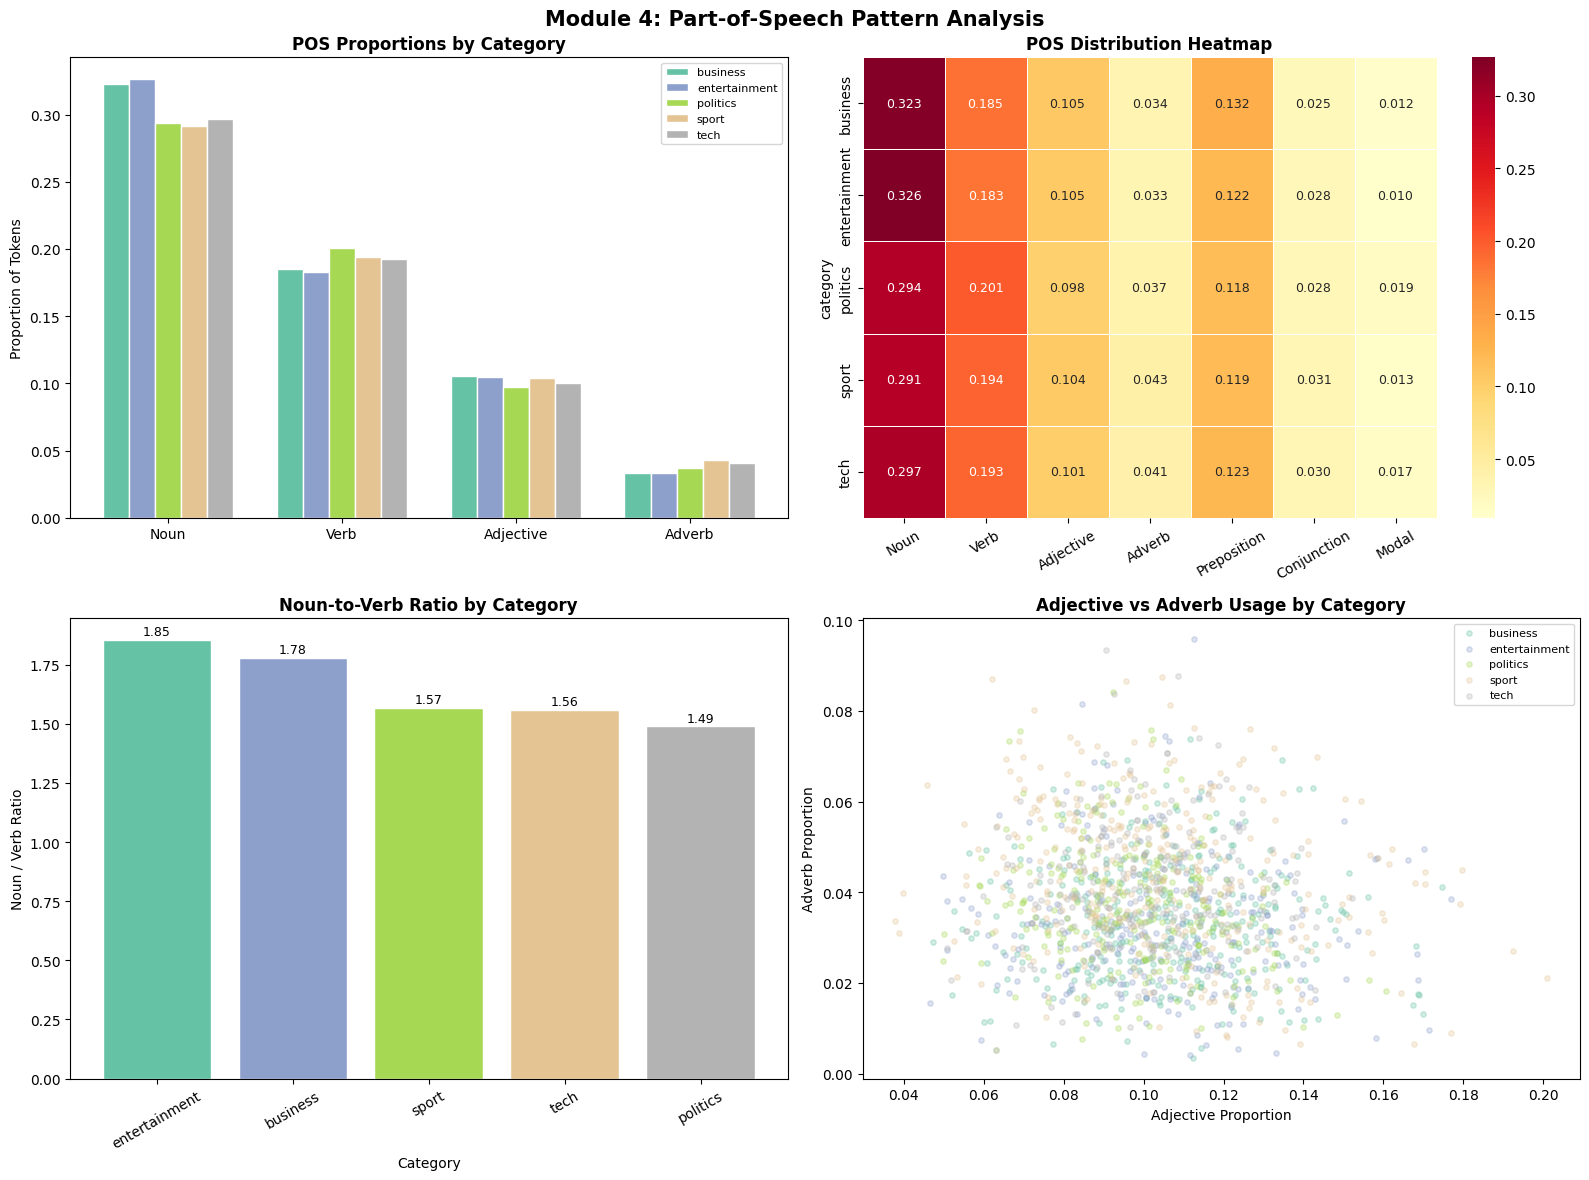


✅ Visualizations saved as 'module4_pos_analysis.png'


In [29]:
# ============================================================
# MODULE 4: APPLY POS ANALYSIS TO FULL DATASET
# ============================================================
from tqdm.auto import tqdm
tqdm.pandas()

print("🏷️ Running POS analysis on all articles...")
print("(This may take 1–2 minutes)")
print("=" * 60)

# ── Apply to dataset (use cleaned but not fully processed text
#    so POS tagger sees natural sentence structure) ──────────
df['pos_results'] = df['content_clean'].progress_apply(analyze_pos_patterns)

# ── Extract key metrics into columns ──────────────────────
main_pos = ['Noun', 'Verb', 'Adjective', 'Adverb',
            'Preposition', 'Conjunction', 'Determiner', 'Modal']

for pos in main_pos:
    df[f'pos_{pos.lower()}'] = df['pos_results'].apply(
        lambda x: x['pos_proportions'].get(pos, 0) if x else 0
    )

df['noun_verb_ratio']  = df['pos_results'].apply(
    lambda x: x['noun_verb_ratio'] if x else 0)
df['total_pos_tokens'] = df['pos_results'].apply(
    lambda x: x['total_tokens'] if x else 0)

print("✅ POS analysis complete!\n")

# ── 1. POS Distribution by Category ──────────────────────
print("📊 1. POS DISTRIBUTION BY CATEGORY")
print("=" * 60)
pos_cols = [f'pos_{p.lower()}' for p in main_pos]
pos_by_cat = df.groupby('category')[pos_cols].mean().round(4)
pos_by_cat.columns = main_pos
print(pos_by_cat.to_string())

# ── 2. Writing Style Differences ──────────────────────────
print("\n✍️  2. WRITING STYLE DIFFERENCES")
print("=" * 60)
print(f"  {'Category':<15} {'Noun%':>7} {'Verb%':>7} {'Adj%':>7} {'Adv%':>7} {'N/V Ratio':>10}")
print("  " + "-" * 55)
for cat in sorted(df['category'].unique()):
    sub = df[df['category'] == cat]
    n   = sub['pos_noun'].mean()
    v   = sub['pos_verb'].mean()
    a   = sub['pos_adjective'].mean()
    adv = sub['pos_adverb'].mean()
    nv  = sub['noun_verb_ratio'].mean()
    print(f"  {cat:<15} {n:>6.1%} {v:>7.1%} {a:>7.1%} {adv:>7.1%} {nv:>10.2f}")

# ── 3. Top Nouns/Verbs/Adjectives per Category ────────────
print("\n🔤 3. TOP WORDS BY POS TAG PER CATEGORY")
print("=" * 60)
for cat in sorted(df['category'].unique()):
    cat_results = df[df['category'] == cat]['pos_results'].dropna()
    all_nouns = []
    all_verbs = []
    all_adjs  = []
    for r in cat_results:
        all_nouns += [w for w, _ in r['top_nouns']]
        all_verbs += [w for w, _ in r['top_verbs']]
        all_adjs  += [w for w, _ in r['top_adjectives']]
    top_n = [w for w, _ in Counter(all_nouns).most_common(5)]
    top_v = [w for w, _ in Counter(all_verbs).most_common(5)]
    top_a = [w for w, _ in Counter(all_adjs).most_common(5)]
    print(f"\n  📁 {cat.upper()}")
    print(f"     Nouns      : {', '.join(top_n)}")
    print(f"     Verbs      : {', '.join(top_v)}")
    print(f"     Adjectives : {', '.join(top_a)}")

# ── 4. Common POS Bigram Patterns ─────────────────────────
print("\n🔗 4. COMMON POS BIGRAM PATTERNS (top 5 per category)")
print("=" * 60)
for cat in sorted(df['category'].unique()):
    cat_texts = df[df['category'] == cat]['content_clean'].dropna()
    all_bigrams = []
    for text in cat_texts[:100]:   # sample 100 for speed
        all_bigrams += extract_pos_ngrams(text, n=2)
    top_bigrams = Counter(all_bigrams).most_common(5)
    patterns = [f"{a}+{b}" for (a, b), _ in top_bigrams]
    print(f"  {cat:<15}: {', '.join(patterns)}")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Module 4: Part-of-Speech Pattern Analysis',
             fontsize=15, fontweight='bold')

categories  = sorted(df['category'].unique())
plot_colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

# ── Plot 1: Grouped bar — POS proportions by category ─────
ax1 = axes[0, 0]
pos_plot   = ['Noun', 'Verb', 'Adjective', 'Adverb']
x          = np.arange(len(pos_plot))
bar_width  = 0.15
for i, (cat, color) in enumerate(zip(categories, plot_colors)):
    vals = [df[df['category'] == cat][f'pos_{p.lower()}'].mean()
            for p in pos_plot]
    ax1.bar(x + i * bar_width, vals, bar_width,
            label=cat, color=color, edgecolor='white')
ax1.set_title('POS Proportions by Category', fontweight='bold')
ax1.set_xticks(x + bar_width * (len(categories) - 1) / 2)
ax1.set_xticklabels(pos_plot)
ax1.set_ylabel('Proportion of Tokens')
ax1.legend(fontsize=8)

# ── Plot 2: Heatmap of POS proportions ────────────────────
ax2 = axes[0, 1]
heatmap_df = pos_by_cat[['Noun','Verb','Adjective','Adverb',
                          'Preposition','Conjunction','Modal']]
sns.heatmap(heatmap_df, ax=ax2, cmap='YlOrRd',
            annot=True, fmt='.3f', linewidths=0.5,
            annot_kws={'size': 9})
ax2.set_title('POS Distribution Heatmap', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

# ── Plot 3: Noun/Verb ratio by category ───────────────────
ax3 = axes[1, 0]
nv_means = df.groupby('category')['noun_verb_ratio'].mean().sort_values(ascending=False)
bars = ax3.bar(nv_means.index, nv_means.values,
               color=plot_colors[:len(nv_means)], edgecolor='white')
ax3.set_title('Noun-to-Verb Ratio by Category', fontweight='bold')
ax3.set_xlabel('Category')
ax3.set_ylabel('Noun / Verb Ratio')
ax3.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, nv_means.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=9)

# ── Plot 4: Adjective vs Adverb scatter ───────────────────
ax4 = axes[1, 1]
for cat, color in zip(categories, plot_colors):
    sub = df[df['category'] == cat]
    ax4.scatter(sub['pos_adjective'], sub['pos_adverb'],
                alpha=0.3, color=color, label=cat, s=15)
ax4.set_title('Adjective vs Adverb Usage by Category', fontweight='bold')
ax4.set_xlabel('Adjective Proportion')
ax4.set_ylabel('Adverb Proportion')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('module4_pos_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualizations saved as 'module4_pos_analysis.png'")

## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [31]:
# ============================================================
# MODULE 5: SYNTAX PARSING AND SEMANTIC ANALYSIS
# ============================================================
import spacy
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy model loaded: en_core_web_sm")
except OSError:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy model downloaded and loaded")

# ── Step 1: Syntactic Feature Extraction ──────────────────
def extract_syntactic_features(text):
    """
    Extract syntactic features using spaCy dependency parsing.
    Returns:
      - dep_counts       : dependency relation counts
      - dep_proportions  : proportion of each dependency type
      - subjects         : list of grammatical subjects
      - objects          : list of grammatical objects
      - root_verbs       : main verbs (sentence roots)
      - noun_chunks      : noun phrases
      - avg_sent_length  : average sentence length
      - num_sentences    : number of sentences
      - avg_tree_depth   : average dependency tree depth
    """
    if not text or pd.isna(text):
        return None

    # Limit text length for Colab performance
    doc = nlp(str(text)[:1500])

    dep_counts    = Counter()
    subjects      = []
    objects       = []
    root_verbs    = []
    noun_chunks   = []
    tree_depths   = []

    for token in doc:
        dep_counts[token.dep_] += 1

        # Extract grammatical roles
        if token.dep_ in ('nsubj', 'nsubjpass'):
            subjects.append(token.text.lower())
        if token.dep_ in ('dobj', 'pobj', 'iobj'):
            objects.append(token.text.lower())
        if token.dep_ == 'ROOT':
            root_verbs.append(token.text.lower())

        # Tree depth for this token
        depth = 0
        current = token
        while current.head != current:
            current = current.head
            depth += 1
        tree_depths.append(depth)

    # Noun chunks (noun phrases)
    noun_chunks = [chunk.text.lower() for chunk in doc.noun_chunks]

    # Sentence stats
    sentences = list(doc.sents)
    avg_sent_length = (sum(len(s) for s in sentences) /
                       len(sentences)) if sentences else 0

    total = sum(dep_counts.values()) or 1
    dep_proportions = {k: v / total for k, v in dep_counts.items()}

    return {
        'dep_counts':      dict(dep_counts),
        'dep_proportions': dep_proportions,
        'subjects':        subjects,
        'objects':         objects,
        'root_verbs':      root_verbs,
        'noun_chunks':     noun_chunks,
        'avg_sent_length': avg_sent_length,
        'num_sentences':   len(sentences),
        'avg_tree_depth':  np.mean(tree_depths) if tree_depths else 0,
    }

# ── Step 2: Semantic Role Identification ──────────────────
def extract_semantic_roles(text):
    """
    Identify semantic roles: WHO did WHAT to WHOM.
    Returns subject-verb-object (SVO) triples.
    """
    if not text or pd.isna(text):
        return []

    doc    = nlp(str(text)[:1500])
    triples = []

    for token in doc:
        if token.dep_ == 'ROOT' and token.pos_ == 'VERB':
            verb = token.lemma_

            # Find subject
            subj = next(
                (c.text for c in token.children
                 if c.dep_ in ('nsubj', 'nsubjpass')), None)

            # Find object
            obj = next(
                (c.text for c in token.children
                 if c.dep_ in ('dobj', 'pobj', 'attr')), None)

            if subj or obj:
                triples.append({
                    'subject': subj or 'unknown',
                    'verb':    verb,
                    'object':  obj  or 'unknown',
                })

    return triples

# ── Step 3: Sanity Test ────────────────────────────────────
sample = "The government announced a new policy to reduce inflation rates."
result = extract_syntactic_features(sample)
triples = extract_semantic_roles(sample)

print("🧪 SYNTAX PARSING FUNCTION TEST")
print("=" * 60)
print(f"Sample : {sample}")
print(f"\nTop dependency relations:")
for dep, count in sorted(result['dep_counts'].items(),
                         key=lambda x: x[1], reverse=True)[:8]:
    print(f"  {dep:<15} count: {count}")
print(f"\nSubjects      : {result['subjects']}")
print(f"Objects       : {result['objects']}")
print(f"Root verbs    : {result['root_verbs']}")
print(f"Noun chunks   : {result['noun_chunks'][:5]}")
print(f"Avg tree depth: {result['avg_tree_depth']:.2f}")
print(f"Avg sent len  : {result['avg_sent_length']:.1f} tokens")

print(f"\nSemantic triples (SVO):")
for t in triples:
    print(f"  [{t['subject']}] --{t['verb']}--> [{t['object']}]")

✅ spaCy model loaded: en_core_web_sm
🧪 SYNTAX PARSING FUNCTION TEST
Sample : The government announced a new policy to reduce inflation rates.

Top dependency relations:
  det             count: 2
  dobj            count: 2
  nsubj           count: 1
  ROOT            count: 1
  amod            count: 1
  aux             count: 1
  advcl           count: 1
  compound        count: 1

Subjects      : ['government']
Objects       : ['policy', 'rates']
Root verbs    : ['announced']
Noun chunks   : ['the government', 'a new policy', 'inflation rates']
Avg tree depth: 1.55
Avg sent len  : 11.0 tokens

Semantic triples (SVO):
  [government] --announce--> [policy]


🌳 Running syntax parsing on all articles...
(This may take 2–3 minutes)


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

✅ Syntax parsing complete!

📊 1. SENTENCE STRUCTURE BY CATEGORY
  Category         Avg Sent Len  Avg Tree Depth  Avg Sentences
  ------------------------------------------------------------
  business                215.5            6.17            1.2
  entertainment           177.6            5.50            1.6
  politics                211.7            6.71            1.4
  sport                   147.6            5.20            2.4
  tech                    228.7            6.14            1.3

🔗 2. TOP DEPENDENCY RELATIONS PER CATEGORY

  📁 BUSINESS
     prep            12.14%
     pobj            11.06%
     det             10.00%
     compound        8.90%
     amod            7.83%

  📁 ENTERTAINMENT
     compound        11.32%
     prep            10.84%
     pobj            10.17%
     det             9.41%
     amod            7.37%

  📁 POLITICS
     prep            10.12%
     pobj            9.62%
     det             9.41%
     compound        9.07%
     nsubj         

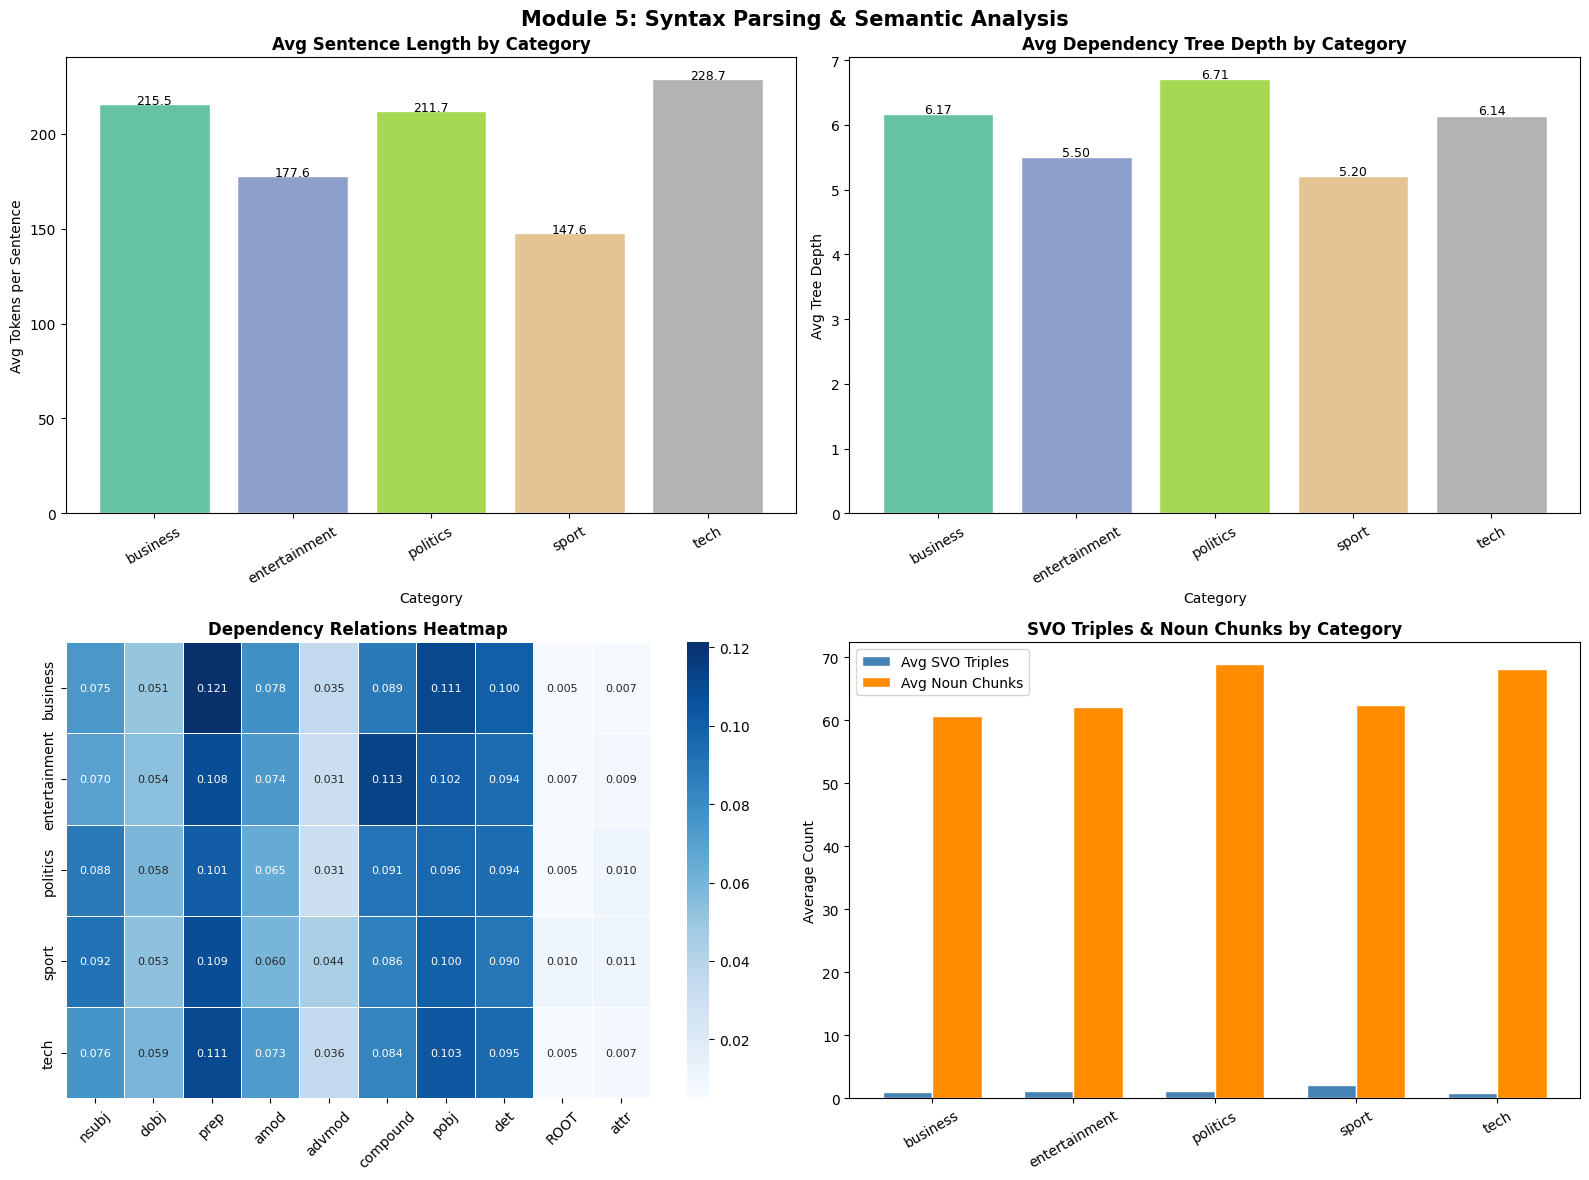


✅ Visualizations saved as 'module5_syntax.png'


In [33]:
# ============================================================
# MODULE 5: APPLY SYNTAX PARSING TO FULL DATASET
# ============================================================
from tqdm.auto import tqdm
tqdm.pandas()

print("🌳 Running syntax parsing on all articles...")
print("(This may take 2–3 minutes)")
print("=" * 60)

# ── Apply to dataset (sample 300 for speed on Colab) ──────
SAMPLE_SIZE = 300
df_syntax = (df.groupby('category', group_keys=False)
               .apply(lambda x: x.sample(min(len(x),
                      SAMPLE_SIZE // df['category'].nunique()),
                      random_state=42))
               .reset_index(drop=True))

df_syntax['syn_results'] = df_syntax['content_clean'].progress_apply(
    extract_syntactic_features)
df_syntax['svo_triples'] = df_syntax['content_clean'].progress_apply(
    extract_semantic_roles)

# ── Extract key metrics ────────────────────────────────────
df_syntax['avg_sent_length'] = df_syntax['syn_results'].apply(
    lambda x: x['avg_sent_length'] if x else 0)
df_syntax['avg_tree_depth']  = df_syntax['syn_results'].apply(
    lambda x: x['avg_tree_depth']  if x else 0)
df_syntax['num_sentences']   = df_syntax['syn_results'].apply(
    lambda x: x['num_sentences']   if x else 0)
df_syntax['num_noun_chunks'] = df_syntax['syn_results'].apply(
    lambda x: len(x['noun_chunks']) if x else 0)
df_syntax['num_svo']         = df_syntax['svo_triples'].apply(len)

print("✅ Syntax parsing complete!\n")

# ── 1. Sentence Structure Stats by Category ───────────────
print("📊 1. SENTENCE STRUCTURE BY CATEGORY")
print("=" * 60)
print(f"  {'Category':<15} {'Avg Sent Len':>13} {'Avg Tree Depth':>15} {'Avg Sentences':>14}")
print("  " + "-" * 60)
for cat in sorted(df_syntax['category'].unique()):
    sub = df_syntax[df_syntax['category'] == cat]
    print(f"  {cat:<15} "
          f"{sub['avg_sent_length'].mean():>13.1f} "
          f"{sub['avg_tree_depth'].mean():>15.2f} "
          f"{sub['num_sentences'].mean():>14.1f}")

# ── 2. Top Dependency Relations per Category ──────────────
print("\n🔗 2. TOP DEPENDENCY RELATIONS PER CATEGORY")
print("=" * 60)
key_deps = ['nsubj', 'dobj', 'prep', 'amod', 'advmod',
            'compound', 'pobj', 'det', 'ROOT', 'attr']

for cat in sorted(df_syntax['category'].unique()):
    cat_results = df_syntax[df_syntax['category'] == cat]['syn_results'].dropna()
    all_deps = Counter()
    for r in cat_results:
        all_deps.update(r['dep_counts'])
    total = sum(all_deps.values()) or 1
    top5  = [(d, all_deps[d]/total) for d in key_deps if d in all_deps]
    top5  = sorted(top5, key=lambda x: x[1], reverse=True)[:5]
    print(f"\n  📁 {cat.upper()}")
    for dep, prop in top5:
        print(f"     {dep:<15} {prop:.2%}")

# ── 3. Most Common Subjects and Objects ───────────────────
print("\n👤 3. MOST COMMON SUBJECTS & OBJECTS PER CATEGORY")
print("=" * 60)
for cat in sorted(df_syntax['category'].unique()):
    cat_results = df_syntax[df_syntax['category'] == cat]['syn_results'].dropna()
    all_subj = []
    all_obj  = []
    for r in cat_results:
        all_subj += r['subjects']
        all_obj  += r['objects']
    top_subj = [w for w, _ in Counter(all_subj).most_common(5)]
    top_obj  = [w for w, _ in Counter(all_obj).most_common(5)]
    print(f"\n  📁 {cat.upper()}")
    print(f"     Subjects : {', '.join(top_subj)}")
    print(f"     Objects  : {', '.join(top_obj)}")

# ── 4. Sample SVO Triples ─────────────────────────────────
print("\n🔍 4. SAMPLE SEMANTIC TRIPLES (SVO) PER CATEGORY")
print("=" * 60)
for cat in sorted(df_syntax['category'].unique()):
    cat_triples = df_syntax[df_syntax['category'] == cat]['svo_triples']
    all_triples = [t for triples in cat_triples for t in triples]
    print(f"\n  📁 {cat.upper()}")
    for t in all_triples[:3]:
        print(f"     [{t['subject']}] --{t['verb']}--> [{t['object']}]")

# ── 5. Dependency Parse Visualization ─────────────────────
print("\n🌳 5. DEPENDENCY PARSE — SAMPLE SENTENCE")
print("=" * 60)
sample_article = df_syntax[df_syntax['category'] == categories[0]].iloc[0]['content_clean']
sample_sentence = list(nlp(sample_article[:500]).sents)[0].text
print(f"Sentence: {sample_sentence}\n")

doc_sample = nlp(sample_sentence)
print(f"  {'Token':<20} {'POS':<10} {'Dep':<15} {'Head'}")
print("  " + "-" * 60)
for token in doc_sample:
    print(f"  {token.text:<20} {token.pos_:<10} "
          f"{token.dep_:<15} {token.head.text}")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Module 5: Syntax Parsing & Semantic Analysis',
             fontsize=15, fontweight='bold')

categories_syn = sorted(df_syntax['category'].unique())
plot_colors    = plt.cm.Set2(np.linspace(0, 1, len(categories_syn)))

# ── Plot 1: Avg sentence length by category ───────────────
ax1 = axes[0, 0]
means = [df_syntax[df_syntax['category'] == c]['avg_sent_length'].mean()
         for c in categories_syn]
bars = ax1.bar(categories_syn, means,
               color=plot_colors, edgecolor='white')
ax1.set_title('Avg Sentence Length by Category', fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Avg Tokens per Sentence')
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', fontsize=9)

# ── Plot 2: Avg tree depth by category ────────────────────
ax2 = axes[0, 1]
depths = [df_syntax[df_syntax['category'] == c]['avg_tree_depth'].mean()
          for c in categories_syn]
bars2 = ax2.bar(categories_syn, depths,
                color=plot_colors, edgecolor='white')
ax2.set_title('Avg Dependency Tree Depth by Category', fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Avg Tree Depth')
ax2.tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, depths):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=9)

# ── Plot 3: Dependency heatmap ────────────────────────────
ax3 = axes[1, 0]
dep_heatmap = pd.DataFrame(index=categories_syn, columns=key_deps, dtype=float)
for cat in categories_syn:
    cat_results = df_syntax[df_syntax['category'] == cat]['syn_results'].dropna()
    all_deps = Counter()
    for r in cat_results:
        all_deps.update(r['dep_counts'])
    total = sum(all_deps.values()) or 1
    for dep in key_deps:
        dep_heatmap.loc[cat, dep] = all_deps.get(dep, 0) / total

sns.heatmap(dep_heatmap.astype(float),
            ax=ax3, cmap='Blues',
            annot=True, fmt='.3f',
            linewidths=0.5, annot_kws={'size': 8})
ax3.set_title('Dependency Relations Heatmap', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# ── Plot 4: SVO triples count + noun chunks per category ──
ax4 = axes[1, 1]
x         = np.arange(len(categories_syn))
bar_width  = 0.35
svo_means  = [df_syntax[df_syntax['category'] == c]['num_svo'].mean()
              for c in categories_syn]
chunk_means = [df_syntax[df_syntax['category'] == c]['num_noun_chunks'].mean()
               for c in categories_syn]

ax4.bar(x - bar_width/2, svo_means,  bar_width,
        label='Avg SVO Triples',  color='steelblue',   edgecolor='white')
ax4.bar(x + bar_width/2, chunk_means, bar_width,
        label='Avg Noun Chunks', color='darkorange', edgecolor='white')
ax4.set_title('SVO Triples & Noun Chunks by Category', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(categories_syn, rotation=30)
ax4.set_ylabel('Average Count')
ax4.legend()

plt.tight_layout()
plt.savefig('module5_syntax.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualizations saved as 'module5_syntax.png'")

## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [35]:
# ============================================================
# MODULE 6: SENTIMENT AND EMOTION ANALYSIS
# ============================================================
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# ── Emotion Lexicon (NRC-style keyword mapping) ────────────
EMOTION_LEXICON = {
    'joy':        ['happy','joy','celebrate','win','success','great',
                   'excellent','wonderful','amazing','best','love',
                   'pleasure','delight','triumph','gain','profit'],
    'anger':      ['angry','anger','furious','outrage','attack','fight',
                   'war','conflict','rage','hostile','violent','dispute',
                   'clash','protest','condemn','blame'],
    'fear':       ['fear','afraid','threat','danger','risk','crisis',
                   'warning','terror','panic','concern','worry','alarming',
                   'anxious','emergency','catastrophe','collapse'],
    'sadness':    ['sad','death','loss','tragedy','grief','victim',
                   'suffer','poor','fail','decline','hurt','disappoint',
                   'mourn','devastate','unfortunate','crisis'],
    'surprise':   ['surprise','unexpected','sudden','shock','announce',
                   'reveal','discover','breaking','new','unprecedented',
                   'remarkable','astonishing','stunning','dramatic'],
    'trust':      ['trust','reliable','official','government','confirm',
                   'approve','support','agree','partner','alliance',
                   'cooperation','safe','secure','stable','strong'],
    'anticipation':['expect','plan','future','forecast','predict','soon',
                    'upcoming','growth','hope','goal','target','project',
                    'strategy','prepare','develop'],
    'disgust':    ['disgust','corrupt','scandal','fraud','abuse','lie',
                   'cheat','betray','immoral','wrong','dirty','offensive',
                   'shameful','unacceptable','terrible'],
}

# ── Step 1: Article-Level Sentiment ───────────────────────
def analyze_sentiment(text):
    """
    Analyze sentiment using VADER.
    Returns compound, positive, negative, neutral scores
    plus a sentiment label.
    """
    if not text or pd.isna(text):
        return {
            'compound':  0.0, 'positive': 0.0,
            'negative':  0.0, 'neutral':  1.0,
            'label':     'neutral',
            'intensity': 'weak',
        }

    scores = sia.polarity_scores(str(text))

    # Label based on compound score
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'

    # Intensity
    abs_compound = abs(compound)
    if abs_compound >= 0.5:
        intensity = 'strong'
    elif abs_compound >= 0.2:
        intensity = 'moderate'
    else:
        intensity = 'weak'

    return {
        'compound':  round(compound,           4),
        'positive':  round(scores['pos'],      4),
        'negative':  round(scores['neg'],      4),
        'neutral':   round(scores['neu'],      4),
        'label':     label,
        'intensity': intensity,
    }

# ── Step 2: Sentence-Level Sentiment ──────────────────────
def analyze_sentiment_by_sentence(text, n_sentences=5):
    """
    Break article into sentences and score each one.
    Returns list of (sentence, compound_score) tuples
    for the most extreme sentences.
    """
    if not text or pd.isna(text):
        return []

    sentences = sent_tokenize(str(text)[:2000])
    scored    = [(s, sia.polarity_scores(s)['compound'])
                 for s in sentences if len(s.split()) > 4]

    # Return most extreme (positive + negative) sentences
    scored_sorted = sorted(scored, key=lambda x: abs(x[1]), reverse=True)
    return scored_sorted[:n_sentences]

# ── Step 3: Emotion Detection ─────────────────────────────
def detect_emotions(text):
    """
    Detect emotions using keyword matching against EMOTION_LEXICON.
    Returns emotion scores (proportion of matching words).
    """
    if not text or pd.isna(text):
        return {e: 0.0 for e in EMOTION_LEXICON}

    words  = str(text).lower().split()
    total  = len(words) or 1
    scores = {}

    for emotion, keywords in EMOTION_LEXICON.items():
        matches      = sum(1 for w in words if w in keywords)
        scores[emotion] = round(matches / total, 5)

    return scores

# ── Sanity Test ────────────────────────────────────────────
sample_pos = "The company announced record profits and celebrated a massive success in global markets."
sample_neg = "The government faces serious crisis as corruption scandal devastates public trust."
sample_neu = "The minister held a meeting with officials to discuss the annual budget report."

print("🧪 SENTIMENT ANALYSIS FUNCTION TEST")
print("=" * 60)
for label, text in [("Positive", sample_pos),
                     ("Negative", sample_neg),
                     ("Neutral",  sample_neu)]:
    result = analyze_sentiment(text)
    emotions = detect_emotions(text)
    top_emo  = max(emotions, key=emotions.get)
    print(f"\n[{label}] {text[:70]}...")
    print(f"  Sentiment : {result['label'].upper()} "
          f"(compound: {result['compound']:+.3f}, "
          f"intensity: {result['intensity']})")
    print(f"  Scores    : pos={result['positive']:.3f}  "
          f"neg={result['negative']:.3f}  "
          f"neu={result['neutral']:.3f}")
    print(f"  Top emotion: {top_emo} ({emotions[top_emo]:.4f})")

🧪 SENTIMENT ANALYSIS FUNCTION TEST

[Positive] The company announced record profits and celebrated a massive success ...
  Sentiment : POSITIVE (compound: +0.883, intensity: strong)
  Scores    : pos=0.534  neg=0.000  neu=0.466
  Top emotion: joy (0.0769)

[Negative] The government faces serious crisis as corruption scandal devastates p...
  Sentiment : NEGATIVE (compound: -0.832, intensity: strong)
  Scores    : pos=0.154  neg=0.565  neu=0.280
  Top emotion: fear (0.0909)

[Neutral] The minister held a meeting with officials to discuss the annual budge...
  Sentiment : NEUTRAL (compound: +0.000, intensity: weak)
  Scores    : pos=0.000  neg=0.000  neu=1.000
  Top emotion: joy (0.0000)


😊 Running sentiment analysis on all articles...


  0%|          | 0/1440 [00:00<?, ?it/s]

  0%|          | 0/1440 [00:00<?, ?it/s]

✅ Sentiment & emotion analysis complete!

📊 1. OVERALL SENTIMENT DISTRIBUTION
  positive    1013 articles  (70.3%)  ████████████████████████████
  negative     416 articles  (28.9%)  ███████████
  neutral       11 articles  (0.8%)  

  Avg compound score : +0.3902
  Std compound score : 0.8061

📈 2. SENTIMENT BY CATEGORY
  Category         Avg Compound  Positive%  Negative%   Neutral%
  --------------------------------------------------------------
  business              +0.2381      62.1%      36.4%       1.5%
  entertainment         +0.5900      80.2%      19.0%       0.8%
  politics              +0.0541      53.0%      46.6%       0.4%
  sport                 +0.5492      78.9%      20.8%       0.3%
  tech                  +0.5330      78.2%      20.9%       0.9%

💭 3. DOMINANT EMOTIONS ACROSS ALL ARTICLES
  joy               473 (32.8%)  █████████████
  surprise          305 (21.2%)  ████████
  trust             237 (16.5%)  ██████
  anticipation      168 (11.7%)  ████
  fear     

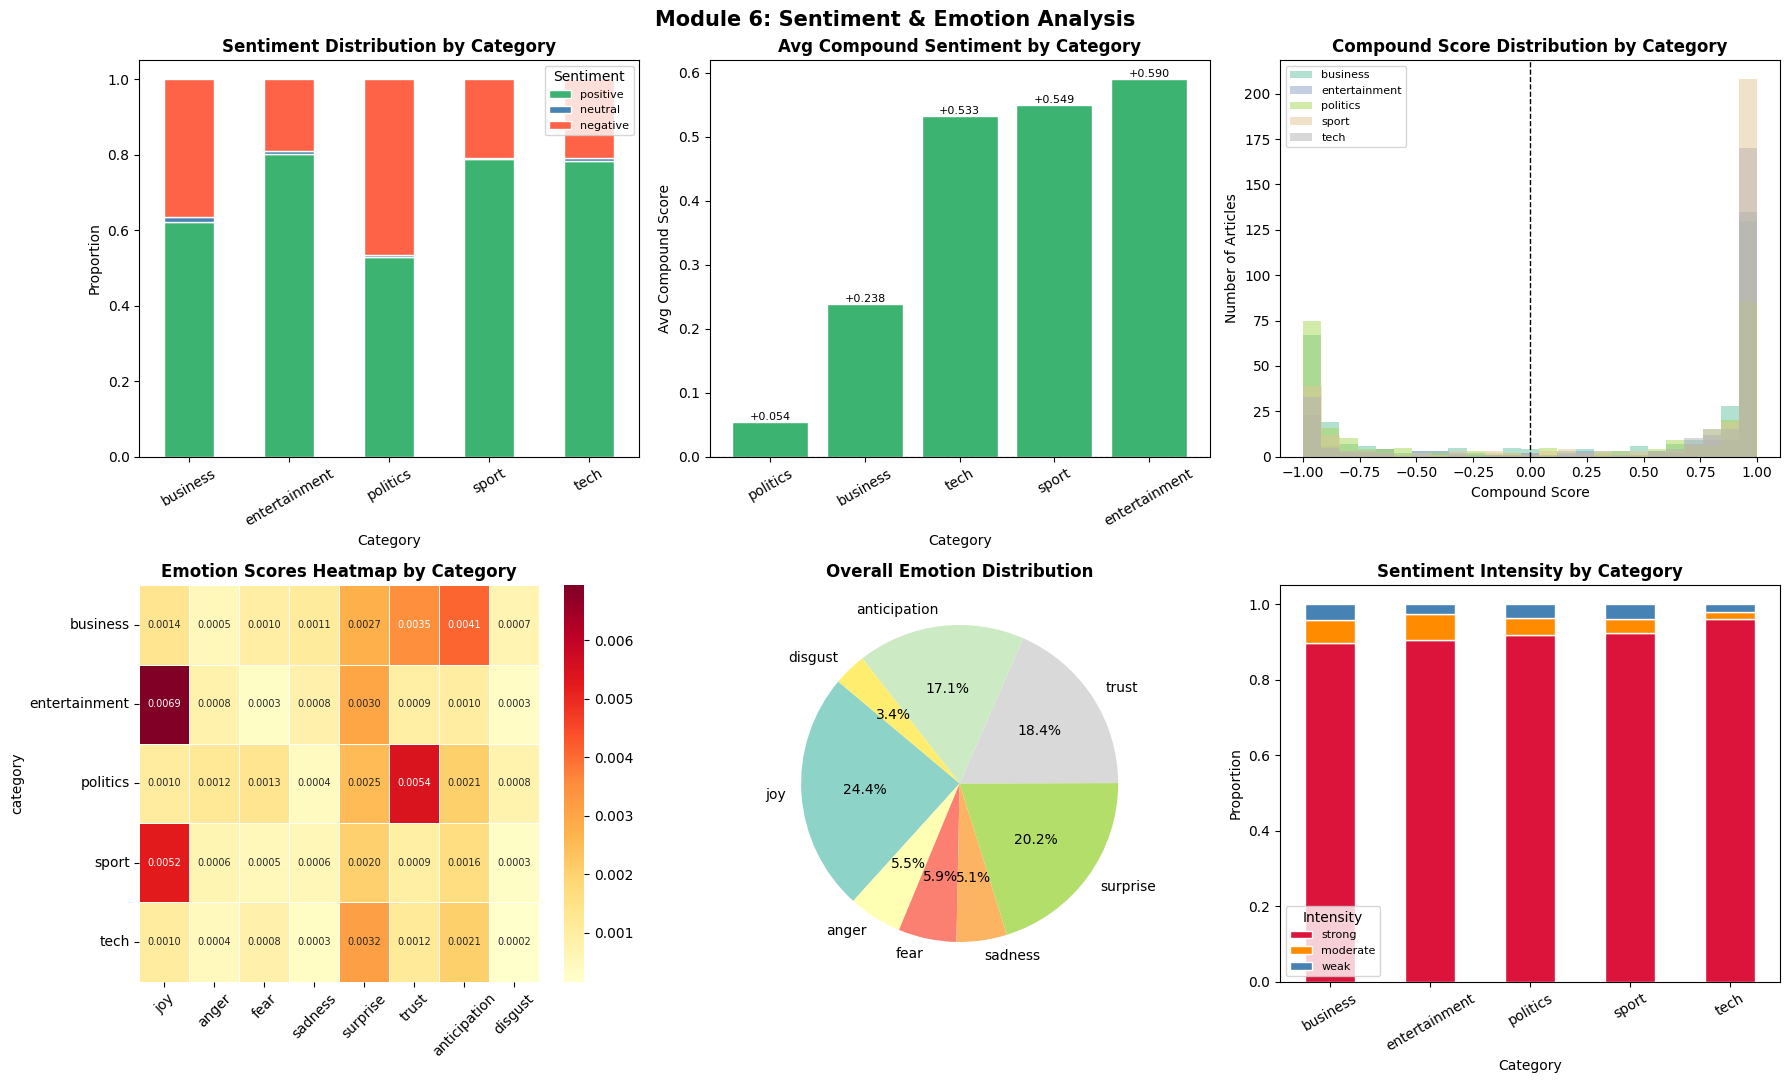


✅ Visualizations saved as 'module6_sentiment.png'


In [37]:
# ============================================================
# MODULE 6: APPLY SENTIMENT ANALYSIS TO FULL DATASET
# ============================================================
from tqdm.auto import tqdm
tqdm.pandas()

print("😊 Running sentiment analysis on all articles...")
print("=" * 60)

# ── Apply sentiment analysis ───────────────────────────────
sentiment_results = df['content'].progress_apply(analyze_sentiment)
df['sentiment_compound']  = sentiment_results.apply(lambda x: x['compound'])
df['sentiment_positive']  = sentiment_results.apply(lambda x: x['positive'])
df['sentiment_negative']  = sentiment_results.apply(lambda x: x['negative'])
df['sentiment_neutral']   = sentiment_results.apply(lambda x: x['neutral'])
df['sentiment_label']     = sentiment_results.apply(lambda x: x['label'])
df['sentiment_intensity'] = sentiment_results.apply(lambda x: x['intensity'])

# ── Apply emotion detection ────────────────────────────────
emotion_results = df['content'].progress_apply(detect_emotions)
for emotion in EMOTION_LEXICON:
    df[f'emotion_{emotion}'] = emotion_results.apply(
        lambda x: x.get(emotion, 0.0))

df['dominant_emotion'] = emotion_results.apply(
    lambda x: max(x, key=x.get))

print("✅ Sentiment & emotion analysis complete!\n")

# ── 1. Overall Sentiment Distribution ─────────────────────
print("📊 1. OVERALL SENTIMENT DISTRIBUTION")
print("=" * 60)
sentiment_counts = df['sentiment_label'].value_counts()
total = len(df)
for label, count in sentiment_counts.items():
    bar = '█' * int(count / total * 40)
    print(f"  {label:<10} {count:>5} articles  "
          f"({count/total:.1%})  {bar}")
print(f"\n  Avg compound score : {df['sentiment_compound'].mean():+.4f}")
print(f"  Std compound score : {df['sentiment_compound'].std():.4f}")

# ── 2. Sentiment by Category ──────────────────────────────
print("\n📈 2. SENTIMENT BY CATEGORY")
print("=" * 60)
print(f"  {'Category':<15} {'Avg Compound':>13} {'Positive%':>10} "
      f"{'Negative%':>10} {'Neutral%':>10}")
print("  " + "-" * 62)
for cat in sorted(df['category'].unique()):
    sub = df[df['category'] == cat]
    avg_c = sub['sentiment_compound'].mean()
    pos_p = (sub['sentiment_label'] == 'positive').mean()
    neg_p = (sub['sentiment_label'] == 'negative').mean()
    neu_p = (sub['sentiment_label'] == 'neutral').mean()
    print(f"  {cat:<15} {avg_c:>+13.4f} {pos_p:>10.1%} "
          f"{neg_p:>10.1%} {neu_p:>10.1%}")

# ── 3. Emotion Distribution ───────────────────────────────
print("\n💭 3. DOMINANT EMOTIONS ACROSS ALL ARTICLES")
print("=" * 60)
emotion_counts = df['dominant_emotion'].value_counts()
for emotion, count in emotion_counts.items():
    bar = '█' * int(count / total * 40)
    print(f"  {emotion:<15} {count:>5} ({count/total:.1%})  {bar}")

# ── 4. Emotions by Category ───────────────────────────────
print("\n🎭 4. AVERAGE EMOTION SCORES BY CATEGORY")
print("=" * 60)
emotion_cols = [f'emotion_{e}' for e in EMOTION_LEXICON]
emotion_by_cat = df.groupby('category')[emotion_cols].mean().round(5)
emotion_by_cat.columns = list(EMOTION_LEXICON.keys())
print(emotion_by_cat.to_string())

# ── 5. Most Extreme Articles ──────────────────────────────
print("\n🔥 5. MOST EXTREME ARTICLES")
print("=" * 60)
most_positive = df.loc[df['sentiment_compound'].idxmax()]
most_negative = df.loc[df['sentiment_compound'].idxmin()]
print(f"  Most POSITIVE [{most_positive['category']}] "
      f"(score: {most_positive['sentiment_compound']:+.4f})")
print(f"  → {most_positive['content'][:150]}...\n")
print(f"  Most NEGATIVE [{most_negative['category']}] "
      f"(score: {most_negative['sentiment_compound']:+.4f})")
print(f"  → {most_negative['content'][:150]}...")

# ── 6. Sample Sentence-Level Analysis ─────────────────────
print("\n📝 6. SENTENCE-LEVEL SENTIMENT SAMPLE")
print("=" * 60)
sample_article = df[df['category'] == sorted(df['category'].unique())[0]].iloc[0]['content']
sentence_scores = analyze_sentiment_by_sentence(sample_article)
print(f"  Article snippet: {sample_article[:100]}...\n")
for sent, score in sentence_scores[:4]:
    label = '🟢' if score >= 0.05 else ('🔴' if score <= -0.05 else '⚪')
    print(f"  {label} [{score:+.3f}] {sent[:90]}...")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Module 6: Sentiment & Emotion Analysis',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

categories  = sorted(df['category'].unique())
plot_colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

# ── Plot 1: Sentiment label distribution (stacked bar) ────
ax1 = axes[0]
sent_by_cat = df.groupby('category')['sentiment_label'].value_counts(
    normalize=True).unstack(fill_value=0)
sent_by_cat = sent_by_cat.reindex(
    columns=['positive','neutral','negative'], fill_value=0)
sent_by_cat.plot(kind='bar', stacked=True, ax=ax1,
                 color=['mediumseagreen','steelblue','tomato'],
                 edgecolor='white')
ax1.set_title('Sentiment Distribution by Category', fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Proportion')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(title='Sentiment', fontsize=8)

# ── Plot 2: Avg compound score by category ────────────────
ax2 = axes[1]
avg_compound = df.groupby('category')['sentiment_compound'].mean().sort_values()
bar_colors   = ['tomato' if v < 0 else 'mediumseagreen'
                for v in avg_compound.values]
bars = ax2.bar(avg_compound.index, avg_compound.values,
               color=bar_colors, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Avg Compound Sentiment by Category', fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Avg Compound Score')
ax2.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, avg_compound.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.003 if val >= 0 else -0.008),
             f'{val:+.3f}', ha='center', fontsize=8)

# ── Plot 3: Compound score distribution histogram ─────────
ax3 = axes[2]
for cat, color in zip(categories, plot_colors):
    vals = df[df['category'] == cat]['sentiment_compound']
    ax3.hist(vals, bins=25, alpha=0.5, label=cat, color=color)
ax3.axvline(0, color='black', linestyle='--', linewidth=1)
ax3.set_title('Compound Score Distribution by Category', fontweight='bold')
ax3.set_xlabel('Compound Score')
ax3.set_ylabel('Number of Articles')
ax3.legend(fontsize=8)

# ── Plot 4: Emotion heatmap ────────────────────────────────
ax4 = axes[3]
sns.heatmap(emotion_by_cat,
            ax=ax4, cmap='YlOrRd',
            annot=True, fmt='.4f',
            linewidths=0.5, annot_kws={'size': 7})
ax4.set_title('Emotion Scores Heatmap by Category', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# ── Plot 5: Dominant emotion distribution (pie) ───────────
ax5 = axes[4]
emotion_totals = df[[f'emotion_{e}' for e in EMOTION_LEXICON]].sum()
emotion_totals.index = list(EMOTION_LEXICON.keys())
emotion_totals = emotion_totals[emotion_totals > 0]
ax5.pie(emotion_totals.values,
        labels=emotion_totals.index,
        autopct='%1.1f%%',
        colors=plt.cm.Set3(np.linspace(0, 1, len(emotion_totals))),
        startangle=140)
ax5.set_title('Overall Emotion Distribution', fontweight='bold')

# ── Plot 6: Sentiment intensity breakdown ─────────────────
ax6 = axes[5]
intensity_by_cat = df.groupby('category')['sentiment_intensity'].value_counts(
    normalize=True).unstack(fill_value=0)
for col in ['strong','moderate','weak']:
    if col not in intensity_by_cat.columns:
        intensity_by_cat[col] = 0
intensity_by_cat[['strong','moderate','weak']].plot(
    kind='bar', stacked=True, ax=ax6,
    color=['crimson','darkorange','steelblue'],
    edgecolor='white')
ax6.set_title('Sentiment Intensity by Category', fontweight='bold')
ax6.set_xlabel('Category')
ax6.set_ylabel('Proportion')
ax6.tick_params(axis='x', rotation=30)
ax6.legend(title='Intensity', fontsize=8)

plt.tight_layout()
plt.savefig('module6_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualizations saved as 'module6_sentiment.png'")

## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [41]:
# ============================================================
# MODULE 7: MULTI-CLASS TEXT CLASSIFICATION SYSTEM
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("🔧 MODULE 7: PREPARING FEATURES FOR CLASSIFICATION")
print("=" * 60)

# ── Helper: safely convert df columns to sparse matrix ────
def safe_sparse(df_in, prefix):
    """
    Select columns by prefix, force to float64, drop
    any column that still contains non-numeric data.
    Returns csr_matrix or None.
    """
    cols = [c for c in df_in.columns if c.startswith(prefix)]
    if not cols:
        return None
    numeric = (df_in[cols]
               .apply(pd.to_numeric, errors='coerce')
               .fillna(0)
               .select_dtypes(include=[np.number]))
    if numeric.shape[1] == 0:
        return None
    return csr_matrix(numeric.values.astype(np.float64))

# ── Feature 1: TF-IDF on processed content ────────────────
tfidf_clf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_tfidf = tfidf_clf.fit_transform(df['content_processed'])
print(f"✅ TF-IDF features        : {X_tfidf.shape}")

# ── Feature 2: Sentiment scores ───────────────────────────
sentiment_cols = ['sentiment_compound', 'sentiment_positive',
                  'sentiment_negative', 'sentiment_neutral']
sentiment_cols = [c for c in sentiment_cols if c in df.columns]
X_sentiment = csr_matrix(
    df[sentiment_cols].apply(pd.to_numeric, errors='coerce')
                      .fillna(0).values.astype(np.float64))
print(f"✅ Sentiment features      : {X_sentiment.shape}")

# ── Feature 3: POS proportions ────────────────────────────
X_pos = safe_sparse(df, 'pos_')
if X_pos is not None:
    print(f"✅ POS features            : {X_pos.shape}")
else:
    print("⚠️  POS features not available — skipping")

# ── Feature 4: Emotion scores ─────────────────────────────
X_emotion = safe_sparse(df, 'emotion_')
if X_emotion is not None:
    print(f"✅ Emotion features        : {X_emotion.shape}")
else:
    print("⚠️  Emotion features not available — skipping")

# ── Feature 5: Text length ────────────────────────────────
length_cols = [c for c in ['char_count', 'word_count'] if c in df.columns]
X_length = csr_matrix(
    df[length_cols].apply(pd.to_numeric, errors='coerce')
                   .fillna(0).values.astype(np.float64))
print(f"✅ Text length features    : {X_length.shape}")

# ── Combine all available features ────────────────────────
feature_parts  = [X_tfidf, X_sentiment, X_length]
feature_labels = ['TF-IDF', 'Sentiment', 'Length']

if X_pos is not None:
    feature_parts.append(X_pos)
    feature_labels.append('POS')
if X_emotion is not None:
    feature_parts.append(X_emotion)
    feature_labels.append('Emotion')

X_combined = hstack(feature_parts)
print(f"\n✅ Combined feature matrix : {X_combined.shape}")
print(f"   Features used          : {', '.join(feature_labels)}")

# ── Encode labels ─────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['category'])

print(f"\n✅ Label encoding:")
for i, cls in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"   {i} → {cls:<15} ({count} articles)")

# ── Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2, random_state=42, stratify=y)

# Keep a TF-IDF only split for Naive Bayes
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y,
    test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Train / Test split:")
print(f"   Training samples  : {X_train.shape[0]}")
print(f"   Testing samples   : {X_test.shape[0]}")
print(f"   Total features    : {X_train.shape[1]:,}")

🔧 MODULE 7: PREPARING FEATURES FOR CLASSIFICATION
✅ TF-IDF features        : (1440, 8000)
✅ Sentiment features      : (1440, 4)
✅ POS features            : (1440, 9)
✅ Emotion features        : (1440, 8)
✅ Text length features    : (1440, 2)

✅ Combined feature matrix : (1440, 8023)
   Features used          : TF-IDF, Sentiment, Length, POS, Emotion

✅ Label encoding:
   0 → business        (335 articles)
   1 → entertainment   (263 articles)
   2 → politics        (266 articles)
   3 → sport           (342 articles)
   4 → tech            (234 articles)

✅ Train / Test split:
   Training samples  : 1152
   Testing samples   : 288
   Total features    : 8,023


In [42]:
# ============================================================
# MODULE 7: TRAIN AND EVALUATE MULTIPLE CLASSIFIERS
# ============================================================
print("🤖 TRAINING MULTIPLE CLASSIFIERS")
print("=" * 60)

classifiers = {
    'Naive Bayes':         (MultinomialNB(alpha=0.1),
                            X_train_tfidf, X_test_tfidf),
    'Logistic Regression': (LogisticRegression(max_iter=1000,
                                               C=1.0,
                                               random_state=42),
                            X_train, X_test),
    'Linear SVM':          (LinearSVC(C=1.0,
                                      max_iter=2000,
                                      random_state=42),
                            X_train, X_test),
    'Random Forest':       (RandomForestClassifier(n_estimators=100,
                                                   random_state=42,
                                                   n_jobs=-1),
                            X_train, X_test),
    'K-Nearest Neighbors': (KNeighborsClassifier(n_neighbors=5,
                                                 metric='cosine'),
                            X_train, X_test),
}

results        = {}
trained_models = {}
best_model_name = None
best_accuracy   = 0.0

for name, (clf, X_tr, X_te) in classifiers.items():
    print(f"\n  ▶ Training {name}...")

    clf.fit(X_tr, y_train)
    trained_models[name] = clf

    y_pred  = clf.predict(X_te)
    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, average='weighted')
    cv      = cross_val_score(clf, X_tr, y_train,
                              cv=3, scoring='accuracy')

    results[name] = {
        'accuracy':    acc,
        'f1_weighted': f1,
        'cv_mean':     cv.mean(),
        'cv_std':      cv.std(),
        'predictions': y_pred,
    }

    if acc > best_accuracy:
        best_accuracy   = acc
        best_model_name = name

    print(f"    Accuracy : {acc:.4f}")
    print(f"    F1 Score : {f1:.4f}")
    print(f"    CV Score : {cv.mean():.4f} (±{cv.std():.4f})")

# ── Summary table ──────────────────────────────────────────
print("\n\n📊 CLASSIFIER COMPARISON SUMMARY")
print("=" * 65)
print(f"  {'Model':<25} {'Accuracy':>9} {'F1':>9} "
      f"{'CV Mean':>9} {'CV Std':>8}  {'':>4}")
print("  " + "-" * 65)

for name, res in sorted(results.items(),
                        key=lambda x: x[1]['accuracy'],
                        reverse=True):
    star = " ⭐ BEST" if name == best_model_name else ""
    print(f"  {name:<25} {res['accuracy']:>9.4f} "
          f"{res['f1_weighted']:>9.4f} "
          f"{res['cv_mean']:>9.4f} "
          f"{res['cv_std']:>8.4f}{star}")

print(f"\n  🏆 Best model : {best_model_name} "
      f"(accuracy: {best_accuracy:.4f})")

🤖 TRAINING MULTIPLE CLASSIFIERS

  ▶ Training Naive Bayes...
    Accuracy : 0.9618
    F1 Score : 0.9617
    CV Score : 0.9731 (±0.0025)

  ▶ Training Logistic Regression...
    Accuracy : 0.7118
    F1 Score : 0.7051
    CV Score : 0.6849 (±0.0639)

  ▶ Training Linear SVM...
    Accuracy : 0.3021
    F1 Score : 0.2473
    CV Score : 0.2917 (±0.0759)

  ▶ Training Random Forest...
    Accuracy : 0.9306
    F1 Score : 0.9296
    CV Score : 0.9427 (±0.0037)

  ▶ Training K-Nearest Neighbors...
    Accuracy : 0.3333
    F1 Score : 0.3347
    CV Score : 0.3646 (±0.0195)


📊 CLASSIFIER COMPARISON SUMMARY
  Model                      Accuracy        F1   CV Mean   CV Std      
  -----------------------------------------------------------------
  Naive Bayes                  0.9618    0.9617    0.9731   0.0025 ⭐ BEST
  Random Forest                0.9306    0.9296    0.9427   0.0037
  Logistic Regression          0.7118    0.7051    0.6849   0.0639
  K-Nearest Neighbors          0.3333    0.

🔍 DETAILED EVALUATION — NAIVE BAYES

📋 1. CLASSIFICATION REPORT
               precision    recall  f1-score   support

     business       0.94      0.97      0.96        67
entertainment       0.96      0.94      0.95        53
     politics       0.96      0.96      0.96        53
        sport       1.00      1.00      1.00        68
         tech       0.93      0.91      0.92        47

     accuracy                           0.96       288
    macro avg       0.96      0.96      0.96       288
 weighted avg       0.96      0.96      0.96       288

📊 2. PER-CLASS BREAKDOWN
  Category         Precision   Recall       F1   Support
  -------------------------------------------------------
  business            0.9420   0.9701   0.9559        67
  entertainment       0.9615   0.9434   0.9524        53
  politics            0.9623   0.9623   0.9623        53
  sport               1.0000   1.0000   1.0000        68
  tech                0.9348   0.9149   0.9247        47

🔑 3. TOP 10 

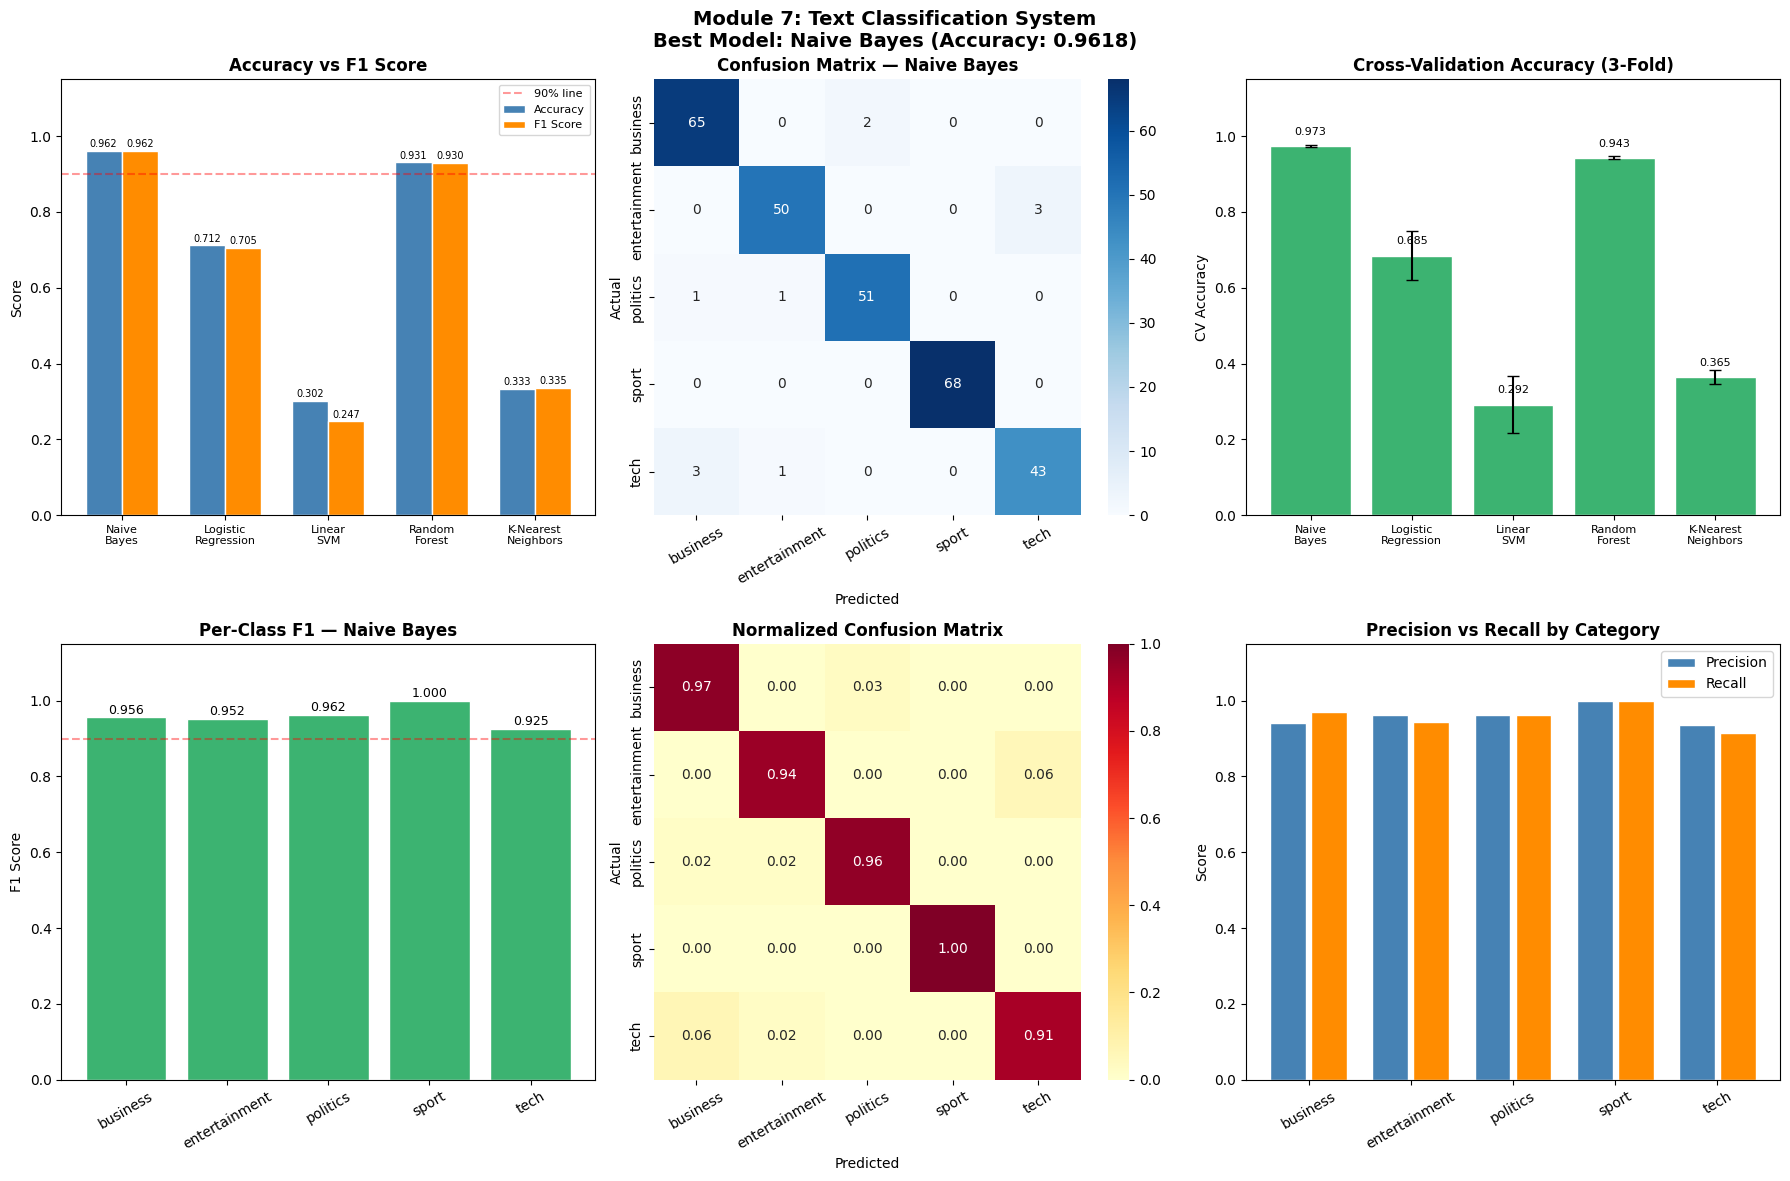


✅ Visualizations saved as 'module7_classification.png'


In [43]:
# ============================================================
# MODULE 7: DETAILED EVALUATION + VISUALIZATIONS
# ============================================================
print(f"🔍 DETAILED EVALUATION — {best_model_name.upper()}")
print("=" * 60)

best_model       = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

# ── 1. Classification report ──────────────────────────────
print("\n📋 1. CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, best_predictions,
                             target_names=le.classes_))

report_dict = classification_report(
    y_test, best_predictions,
    target_names=le.classes_,
    output_dict=True)

# ── 2. Per-class breakdown ────────────────────────────────
print("📊 2. PER-CLASS BREAKDOWN")
print("=" * 60)
print(f"  {'Category':<15} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'Support':>9}")
print("  " + "-" * 55)
for cls in le.classes_:
    m = report_dict[cls]
    print(f"  {cls:<15} {m['precision']:>10.4f} "
          f"{m['recall']:>8.4f} "
          f"{m['f1-score']:>8.4f} "
          f"{int(m['support']):>9}")

# ── 3. Feature importance ─────────────────────────────────
print(f"\n🔑 3. TOP 10 FEATURES PER CATEGORY "
      f"({best_model_name})")
print("=" * 60)
feature_names_tfidf = tfidf_clf.get_feature_names_out()

if best_model_name in ('Logistic Regression', 'Linear SVM'):
    coef = best_model.coef_
    for i, cls in enumerate(le.classes_):
        top_idx   = coef[i].argsort()[::-1][:10]
        # Only show features within TF-IDF vocab range
        top_terms = [feature_names_tfidf[j]
                     if j < len(feature_names_tfidf)
                     else f'extra_feature_{j}'
                     for j in top_idx]
        print(f"\n  📁 {cls.upper()}")
        for term, idx in zip(top_terms, top_idx):
            weight = coef[i][idx]
            bar    = '█' * min(int(abs(weight) * 20), 20)
            print(f"     {term:<30} {weight:+.4f}  {bar}")
else:
    print(f"  ℹ️  Detailed feature weights not available "
          f"for {best_model_name}.")
    print("  Top global TF-IDF terms used as features:")
    mean_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()
    top_global  = mean_scores.argsort()[::-1][:15]
    for idx in top_global:
        print(f"     {feature_names_tfidf[idx]}")

# ── 4. Error analysis ─────────────────────────────────────
print(f"\n❌ 4. ERROR ANALYSIS — misclassified articles")
print("=" * 60)

# Get test set indices
_, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2,
    random_state=42, stratify=y)

errors = [(i, y_test[j], best_predictions[j])
          for j, i in enumerate(test_idx)
          if y_test[j] != best_predictions[j]]

print(f"  Total misclassified : {len(errors)} / {len(y_test)} "
      f"({len(errors)/len(y_test):.1%})")

# Most common confusion pairs
confusion_pairs = Counter(
    (le.classes_[true], le.classes_[pred])
    for _, true, pred in errors)
print(f"\n  Most common mistakes:")
for (true, pred), count in confusion_pairs.most_common(5):
    print(f"     {true:<15} misclassified as {pred:<15} "
          f"({count}x)")

# Sample misclassified articles
print(f"\n  Sample misclassified articles:")
for i, true_idx, pred_idx in errors[:3]:
    true_label = le.classes_[true_idx]
    pred_label = le.classes_[pred_idx]
    snippet    = df.iloc[i]['content'][:120]
    print(f"\n     True: {true_label} | Predicted: {pred_label}")
    print(f"     '{snippet}...'")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Module 7: Text Classification System\n'
             f'Best Model: {best_model_name} '
             f'(Accuracy: {best_accuracy:.4f})',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

model_names = list(results.keys())
accuracies  = [results[m]['accuracy']    for m in model_names]
f1_scores   = [results[m]['f1_weighted'] for m in model_names]
cv_means    = [results[m]['cv_mean']     for m in model_names]
cv_stds     = [results[m]['cv_std']      for m in model_names]

# ── Plot 1: Accuracy vs F1 comparison ─────────────────────
ax1   = axes[0]
x     = np.arange(len(model_names))
width = 0.35
ax1.bar(x - width/2, accuracies, width,
        label='Accuracy', color='steelblue', edgecolor='white')
ax1.bar(x + width/2, f1_scores,  width,
        label='F1 Score', color='darkorange', edgecolor='white')
ax1.set_title('Accuracy vs F1 Score', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace(' ', '\n') for m in model_names],
                    fontsize=8)
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.15)
ax1.axhline(0.9, color='red', linestyle='--',
            alpha=0.4, label='90% line')
ax1.legend(fontsize=8)
for i, (a, f) in enumerate(zip(accuracies, f1_scores)):
    ax1.text(i - width/2, a + 0.01, f'{a:.3f}',
             ha='center', fontsize=7)
    ax1.text(i + width/2, f + 0.01, f'{f:.3f}',
             ha='center', fontsize=7)

# ── Plot 2: Confusion matrix (raw counts) ─────────────────
ax2 = axes[1]
cm  = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, ax=ax2, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
ax2.set_title(f'Confusion Matrix — {best_model_name}',
              fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=30)

# ── Plot 3: Cross-validation with error bars ──────────────
ax3 = axes[2]
bars = ax3.bar(model_names, cv_means,
               color='mediumseagreen', edgecolor='white',
               yerr=cv_stds, capsize=4)
ax3.set_title('Cross-Validation Accuracy (3-Fold)',
              fontweight='bold')
ax3.set_xticklabels([m.replace(' ', '\n') for m in model_names],
                    fontsize=8)
ax3.set_ylabel('CV Accuracy')
ax3.set_ylim(0, 1.15)
for bar, val in zip(bars, cv_means):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.03,
             f'{val:.3f}', ha='center', fontsize=8)

# ── Plot 4: Per-class F1 scores ───────────────────────────
ax4       = axes[3]
class_f1  = [report_dict[cls]['f1-score'] for cls in le.classes_]
bar_colors = ['mediumseagreen' if f >= 0.9
              else ('darkorange' if f >= 0.75 else 'tomato')
              for f in class_f1]
ax4.bar(le.classes_, class_f1,
        color=bar_colors, edgecolor='white')
ax4.set_title(f'Per-Class F1 — {best_model_name}',
              fontweight='bold')
ax4.set_ylabel('F1 Score')
ax4.set_ylim(0, 1.15)
ax4.axhline(0.9, color='red', linestyle='--', alpha=0.4)
ax4.tick_params(axis='x', rotation=30)
for i, val in enumerate(class_f1):
    ax4.text(i, val + 0.01, f'{val:.3f}',
             ha='center', fontsize=9)

# ── Plot 5: Normalized confusion matrix ───────────────────
ax5     = axes[4]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, ax=ax5, annot=True, fmt='.2f',
            cmap='YlOrRd',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
ax5.set_title('Normalized Confusion Matrix',
              fontweight='bold')
ax5.set_xlabel('Predicted')
ax5.set_ylabel('Actual')
ax5.tick_params(axis='x', rotation=30)

# ── Plot 6: Precision vs Recall per class ─────────────────
ax6        = axes[5]
precisions = [report_dict[cls]['precision'] for cls in le.classes_]
recalls    = [report_dict[cls]['recall']    for cls in le.classes_]
x6         = np.arange(len(le.classes_))
ax6.bar(x6 - 0.2, precisions, 0.35,
        label='Precision', color='steelblue',   edgecolor='white')
ax6.bar(x6 + 0.2, recalls,   0.35,
        label='Recall',    color='darkorange', edgecolor='white')
ax6.set_title('Precision vs Recall by Category',
              fontweight='bold')
ax6.set_xticks(x6)
ax6.set_xticklabels(le.classes_, rotation=30)
ax6.set_ylabel('Score')
ax6.set_ylim(0, 1.15)
ax6.legend()

plt.tight_layout()
plt.savefig('module7_classification.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Visualizations saved as 'module7_classification.png'")

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [45]:
# ============================================================
# MODULE 8: NAMED ENTITY RECOGNITION AND ANALYSIS
# ============================================================
import spacy
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy model loaded: en_core_web_sm")
except OSError:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy model downloaded and loaded")

# ── Entity types we care about ────────────────────────────
TARGET_ENTITIES = {
    'PERSON': 'People & public figures',
    'ORG':    'Organizations & companies',
    'GPE':    'Countries, cities, states',
    'LOC':    'Non-GPE locations',
    'DATE':   'Dates & time periods',
    'MONEY':  'Monetary values',
    'PERCENT':'Percentages',
    'PRODUCT':'Products & services',
    'EVENT':  'Named events',
    'LAW':    'Laws & regulations',
}

# ── Step 1: Entity Extraction ──────────────────────────────
def extract_entities(text):
    """
    Extract named entities from text using spaCy NER.
    Returns:
      - entities     : list of (text, label) tuples
      - entity_counts: count per entity type
      - by_type      : dict of {entity_type: [entity_texts]}
    """
    if not text or pd.isna(text):
        return {
            'entities':      [],
            'entity_counts': {},
            'by_type':       {},
        }

    doc      = nlp(str(text)[:2000])
    entities = []
    by_type  = defaultdict(list)

    for ent in doc.ents:
        if ent.label_ in TARGET_ENTITIES:
            clean = ent.text.strip().lower()
            # Filter out very short or purely numeric entities
            if len(clean) > 1 and not clean.isnumeric():
                entities.append((clean, ent.label_))
                by_type[ent.label_].append(clean)

    entity_counts = {k: len(v) for k, v in by_type.items()}

    return {
        'entities':      entities,
        'entity_counts': entity_counts,
        'by_type':       dict(by_type),
    }

# ── Step 2: Entity Co-occurrence ──────────────────────────
def extract_entity_cooccurrence(text, target_types=('PERSON', 'ORG', 'GPE')):
    """
    Find entities that appear together in the same article.
    Useful for relationship mapping.
    Returns list of (entity1, entity2, type1, type2) tuples.
    """
    if not text or pd.isna(text):
        return []

    doc    = nlp(str(text)[:2000])
    found  = [(ent.text.strip().lower(), ent.label_)
              for ent in doc.ents
              if ent.label_ in target_types]

    pairs = []
    for i in range(len(found)):
        for j in range(i + 1, len(found)):
            e1, t1 = found[i]
            e2, t2 = found[j]
            if e1 != e2:
                pairs.append((e1, e2, t1, t2))

    return pairs

# ── Sanity Test ────────────────────────────────────────────
sample = ("Apple CEO Tim Cook announced a $5 billion investment "
          "in the United States on Monday. The deal was signed "
          "in New York with Amazon and Google representatives.")

result  = extract_entities(sample)
cooccur = extract_entity_cooccurrence(sample)

print("🧪 NER FUNCTION TEST")
print("=" * 60)
print(f"Sample: {sample}\n")
print("Entities found:")
for ent, label in result['entities']:
    desc = TARGET_ENTITIES.get(label, label)
    print(f"  [{label:<8}] {ent:<30} ({desc})")
print(f"\nEntity counts: {result['entity_counts']}")
print(f"\nCo-occurrence pairs:")
for e1, e2, t1, t2 in cooccur:
    print(f"  {e1} [{t1}]  ↔  {e2} [{t2}]")

✅ spaCy model loaded: en_core_web_sm
🧪 NER FUNCTION TEST
Sample: Apple CEO Tim Cook announced a $5 billion investment in the United States on Monday. The deal was signed in New York with Amazon and Google representatives.

Entities found:
  [ORG     ] apple                          (Organizations & companies)
  [PERSON  ] tim cook                       (People & public figures)
  [MONEY   ] $5 billion                     (Monetary values)
  [GPE     ] the united states              (Countries, cities, states)
  [DATE    ] monday                         (Dates & time periods)
  [GPE     ] new york                       (Countries, cities, states)
  [ORG     ] amazon                         (Organizations & companies)
  [ORG     ] google                         (Organizations & companies)

Entity counts: {'ORG': 3, 'PERSON': 1, 'MONEY': 1, 'GPE': 2, 'DATE': 1}

Co-occurrence pairs:
  apple [ORG]  ↔  tim cook [PERSON]
  apple [ORG]  ↔  the united states [GPE]
  apple [ORG]  ↔  new york [G

🔍 Running NER on all articles...
(This may take 2–3 minutes)


  0%|          | 0/1440 [00:00<?, ?it/s]

  0%|          | 0/1440 [00:00<?, ?it/s]

✅ NER extraction complete!

✅ Total entity mentions : 22,704
   Unique entities      : 8,401
   Entity types found   : 10

📊 1. OVERALL ENTITY TYPE DISTRIBUTION
  PERSON       6245 (27.5%)  █████████████  People & public figures
  DATE         5794 (25.5%)  ████████████  Dates & time periods
  GPE          4492 (19.8%)  █████████  Countries, cities, states
  ORG          3547 (15.6%)  ███████  Organizations & companies
  MONEY        1105 (4.9%)  ██  Monetary values
  PERCENT      1053 (4.6%)  ██  Percentages
  LOC           359 (1.6%)    Non-GPE locations
  PRODUCT        61 (0.3%)    Products & services
  EVENT          25 (0.1%)    Named events
  LAW            23 (0.1%)    Laws & regulations

📈 2. ENTITY COUNTS BY CATEGORY
               PERSON   ORG   GPE   LOC  DATE  MONEY  PERCENT  PRODUCT  EVENT   LAW  TOTAL
category                                                                                  
business         2.51  3.70  3.99  0.39  5.21   1.91     2.17     0.05   0.01  0.

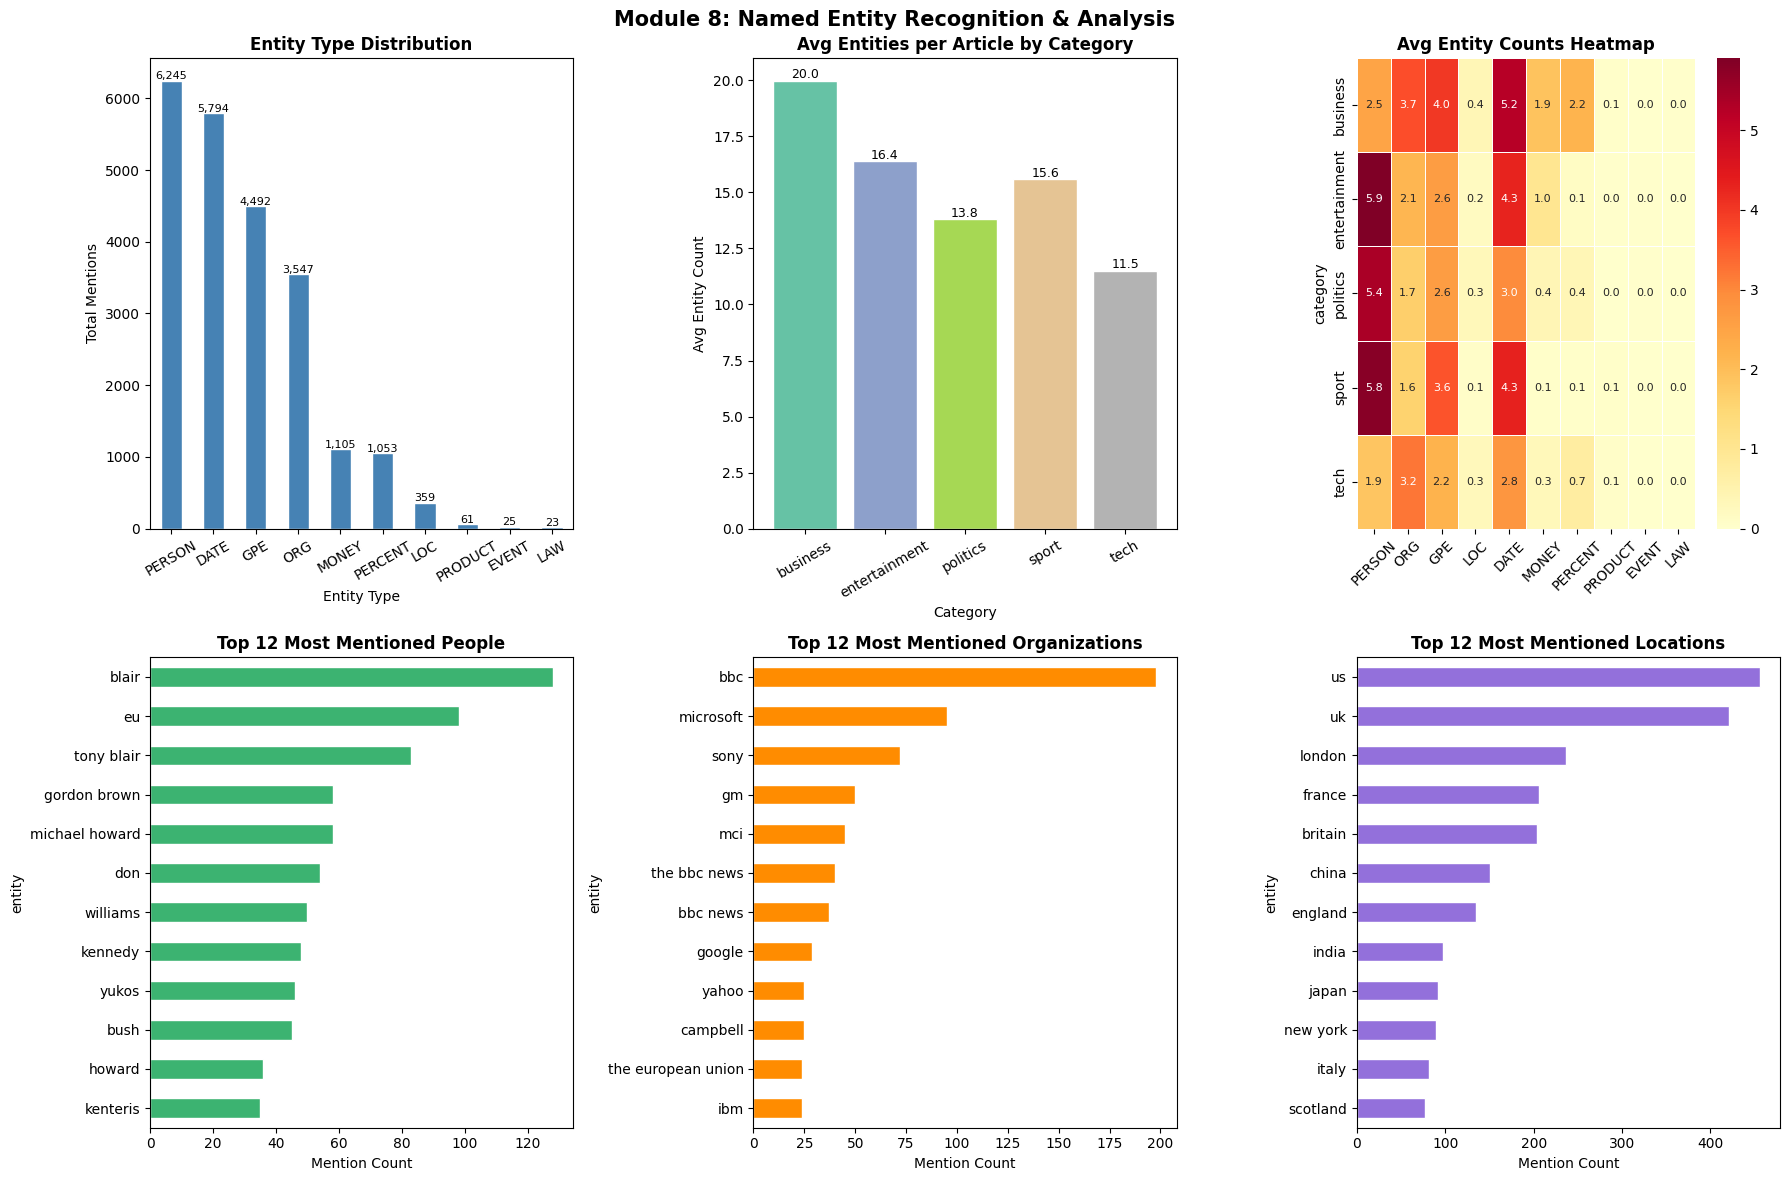


✅ Visualizations saved as 'module8_ner.png'

🎉 NewsBot Intelligence System — complete!


In [46]:
# ============================================================
# MODULE 8: APPLY NER TO FULL DATASET
# ============================================================
print("🔍 Running NER on all articles...")
print("(This may take 2–3 minutes)")
print("=" * 60)

# ── Apply entity extraction ────────────────────────────────
df['ner_results']    = df['content'].progress_apply(extract_entities)
df['cooccur_pairs']  = df['content'].progress_apply(
    extract_entity_cooccurrence)

# ── Extract entity counts into columns ────────────────────
for ent_type in TARGET_ENTITIES:
    df[f'ner_{ent_type.lower()}'] = df['ner_results'].apply(
        lambda x: x['entity_counts'].get(ent_type, 0))

df['total_entities'] = df['ner_results'].apply(
    lambda x: sum(x['entity_counts'].values()))

print("✅ NER extraction complete!\n")

# ── Build flat entities DataFrame ─────────────────────────
entity_records = []
for idx, row in df.iterrows():
    for ent_text, ent_label in row['ner_results']['entities']:
        entity_records.append({
            'article_id': idx,
            'category':   row['category'],
            'entity':     ent_text,
            'type':       ent_label,
        })

entities_df = pd.DataFrame(entity_records)
print(f"✅ Total entity mentions : {len(entities_df):,}")
print(f"   Unique entities      : {entities_df['entity'].nunique():,}")
print(f"   Entity types found   : {entities_df['type'].nunique()}")

# ── 1. Overall Entity Distribution ────────────────────────
print("\n📊 1. OVERALL ENTITY TYPE DISTRIBUTION")
print("=" * 60)
type_counts = entities_df['type'].value_counts()
total_ents  = len(entities_df)
for ent_type, count in type_counts.items():
    desc = TARGET_ENTITIES.get(ent_type, '')
    bar  = '█' * int(count / total_ents * 50)
    print(f"  {ent_type:<10} {count:>6} ({count/total_ents:.1%})  "
          f"{bar}  {desc}")

# ── 2. Entity Counts by Category ──────────────────────────
print("\n📈 2. ENTITY COUNTS BY CATEGORY")
print("=" * 60)
ner_cols = [f'ner_{t.lower()}' for t in TARGET_ENTITIES]
ner_by_cat = df.groupby('category')[ner_cols + ['total_entities']].mean().round(2)
ner_by_cat.columns = list(TARGET_ENTITIES.keys()) + ['TOTAL']
print(ner_by_cat.to_string())

# ── 3. Top Entities per Type ──────────────────────────────
print("\n🏆 3. TOP 10 ENTITIES PER TYPE")
print("=" * 60)
for ent_type in ['PERSON', 'ORG', 'GPE', 'DATE', 'MONEY']:
    subset = entities_df[entities_df['type'] == ent_type]
    if subset.empty:
        print(f"\n  [{ent_type}] — no entities found")
        continue
    top10  = subset['entity'].value_counts().head(10)
    print(f"\n  [{ent_type}] — {TARGET_ENTITIES[ent_type]}")
    for ent, count in top10.items():
        bar = '█' * min(count // 2, 30)
        print(f"     {ent:<35} {count:>4}  {bar}")

# ── 4. Top Entities per Category ──────────────────────────
print("\n📁 4. TOP 5 ENTITIES PER CATEGORY")
print("=" * 60)
for cat in sorted(df['category'].unique()):
    cat_ents = entities_df[entities_df['category'] == cat]
    if cat_ents.empty:
        continue
    top5 = cat_ents['entity'].value_counts().head(5)
    print(f"\n  {cat.upper()}")
    for ent, count in top5.items():
        # Find entity type
        ent_type = cat_ents[cat_ents['entity'] == ent]['type'].mode()
        ent_type = ent_type.iloc[0] if not ent_type.empty else '?'
        print(f"     [{ent_type:<8}] {ent:<30} {count:>4}x")

# ── 5. Cross-Category Entity Patterns ─────────────────────
print("\n🔗 5. CROSS-CATEGORY ENTITY PATTERNS")
print("=" * 60)
print("  Entities appearing in MULTIPLE categories:")
entity_cat_map = (entities_df.groupby('entity')['category']
                              .nunique()
                              .sort_values(ascending=False))
cross_cat = entity_cat_map[entity_cat_map > 2].head(15)
for ent, n_cats in cross_cat.items():
    cats = (entities_df[entities_df['entity'] == ent]['category']
            .value_counts().head(3).index.tolist())
    print(f"     {ent:<30} in {n_cats} categories  "
          f"({', '.join(cats)})")

# ── 6. Co-occurrence Analysis ─────────────────────────────
print("\n🤝 6. TOP ENTITY CO-OCCURRENCES")
print("=" * 60)
all_pairs = [pair for pairs in df['cooccur_pairs'] for pair in pairs]
pair_counts = Counter(
    (min(e1, e2), max(e1, e2))
    for e1, e2, t1, t2 in all_pairs)
print("  Most frequently co-occurring entity pairs:")
for (e1, e2), count in pair_counts.most_common(10):
    print(f"     {e1:<25} ↔  {e2:<25} ({count}x)")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Module 8: Named Entity Recognition & Analysis',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

categories  = sorted(df['category'].unique())
plot_colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

# ── Plot 1: Entity type distribution (bar) ────────────────
ax1 = axes[0]
type_counts.plot(kind='bar', ax=ax1,
                 color='steelblue', edgecolor='white')
ax1.set_title('Entity Type Distribution', fontweight='bold')
ax1.set_xlabel('Entity Type')
ax1.set_ylabel('Total Mentions')
ax1.tick_params(axis='x', rotation=30)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f'{int(bar.get_height()):,}',
             ha='center', fontsize=8)

# ── Plot 2: Avg entities per article by category ──────────
ax2 = axes[1]
avg_ents = df.groupby('category')['total_entities'].mean()
bars = ax2.bar(avg_ents.index, avg_ents.values,
               color=plot_colors[:len(avg_ents)],
               edgecolor='white')
ax2.set_title('Avg Entities per Article by Category',
              fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Avg Entity Count')
ax2.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, avg_ents.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontsize=9)

# ── Plot 3: Entity heatmap by category ────────────────────
ax3 = axes[2]
heatmap_data = ner_by_cat.drop(columns=['TOTAL'])
sns.heatmap(heatmap_data,
            ax=ax3, cmap='YlOrRd',
            annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 8})
ax3.set_title('Avg Entity Counts Heatmap', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# ── Plot 4: Top PERSON entities ───────────────────────────
ax4 = axes[3]
top_persons = (entities_df[entities_df['type'] == 'PERSON']
               ['entity'].value_counts().head(12))
if not top_persons.empty:
    top_persons.plot(kind='barh', ax=ax4,
                     color='mediumseagreen', edgecolor='white')
    ax4.set_title('Top 12 Most Mentioned People',
                  fontweight='bold')
    ax4.set_xlabel('Mention Count')
    ax4.invert_yaxis()
else:
    ax4.text(0.5, 0.5, 'No PERSON entities found',
             ha='center', va='center')
    ax4.set_title('Top People', fontweight='bold')

# ── Plot 5: Top ORG entities ──────────────────────────────
ax5 = axes[4]
top_orgs = (entities_df[entities_df['type'] == 'ORG']
            ['entity'].value_counts().head(12))
if not top_orgs.empty:
    top_orgs.plot(kind='barh', ax=ax5,
                  color='darkorange', edgecolor='white')
    ax5.set_title('Top 12 Most Mentioned Organizations',
                  fontweight='bold')
    ax5.set_xlabel('Mention Count')
    ax5.invert_yaxis()
else:
    ax5.text(0.5, 0.5, 'No ORG entities found',
             ha='center', va='center')
    ax5.set_title('Top Organizations', fontweight='bold')

# ── Plot 6: Top GPE entities ──────────────────────────────
ax6 = axes[5]
top_gpe = (entities_df[entities_df['type'] == 'GPE']
           ['entity'].value_counts().head(12))
if not top_gpe.empty:
    top_gpe.plot(kind='barh', ax=ax6,
                 color='mediumpurple', edgecolor='white')
    ax6.set_title('Top 12 Most Mentioned Locations',
                  fontweight='bold')
    ax6.set_xlabel('Mention Count')
    ax6.invert_yaxis()
else:
    ax6.text(0.5, 0.5, 'No GPE entities found',
             ha='center', va='center')
    ax6.set_title('Top Locations', fontweight='bold')

plt.tight_layout()
plt.savefig('module8_ner.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualizations saved as 'module8_ner.png'")
print("\n🎉 NewsBot Intelligence System — complete!")

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

  📊 NEWSBOT COMPREHENSIVE ANALYSIS & INSIGHTS

📋 INSIGHT 1: DATASET PROFILE
  Total articles    : 1,440
  Categories        : 5
  Avg word count    : 385 words
  Avg char count    : 2234 chars
  Total entities    : 22,704
  Avg entities/art  : 15.8

  Category breakdown:
    business          335 articles (23.3%)  ███████████
    entertainment     263 articles (18.3%)  █████████
    politics          266 articles (18.5%)  █████████
    sport             342 articles (23.8%)  ███████████
    tech              234 articles (16.2%)  ████████

✍️  INSIGHT 2: WRITING STYLE PROFILES
               Avg Words  Noun %  Verb %  Adj %  N/V Ratio  Avg Entities
Category                                                                
business         334.275   0.323   0.185  0.105      1.779        19.979
entertainment    335.445   0.326   0.183  0.105      1.854        16.407
politics         451.643   0.294   0.201  0.097      1.489        13.793
sport            336.877   0.291   0.194  0.104    

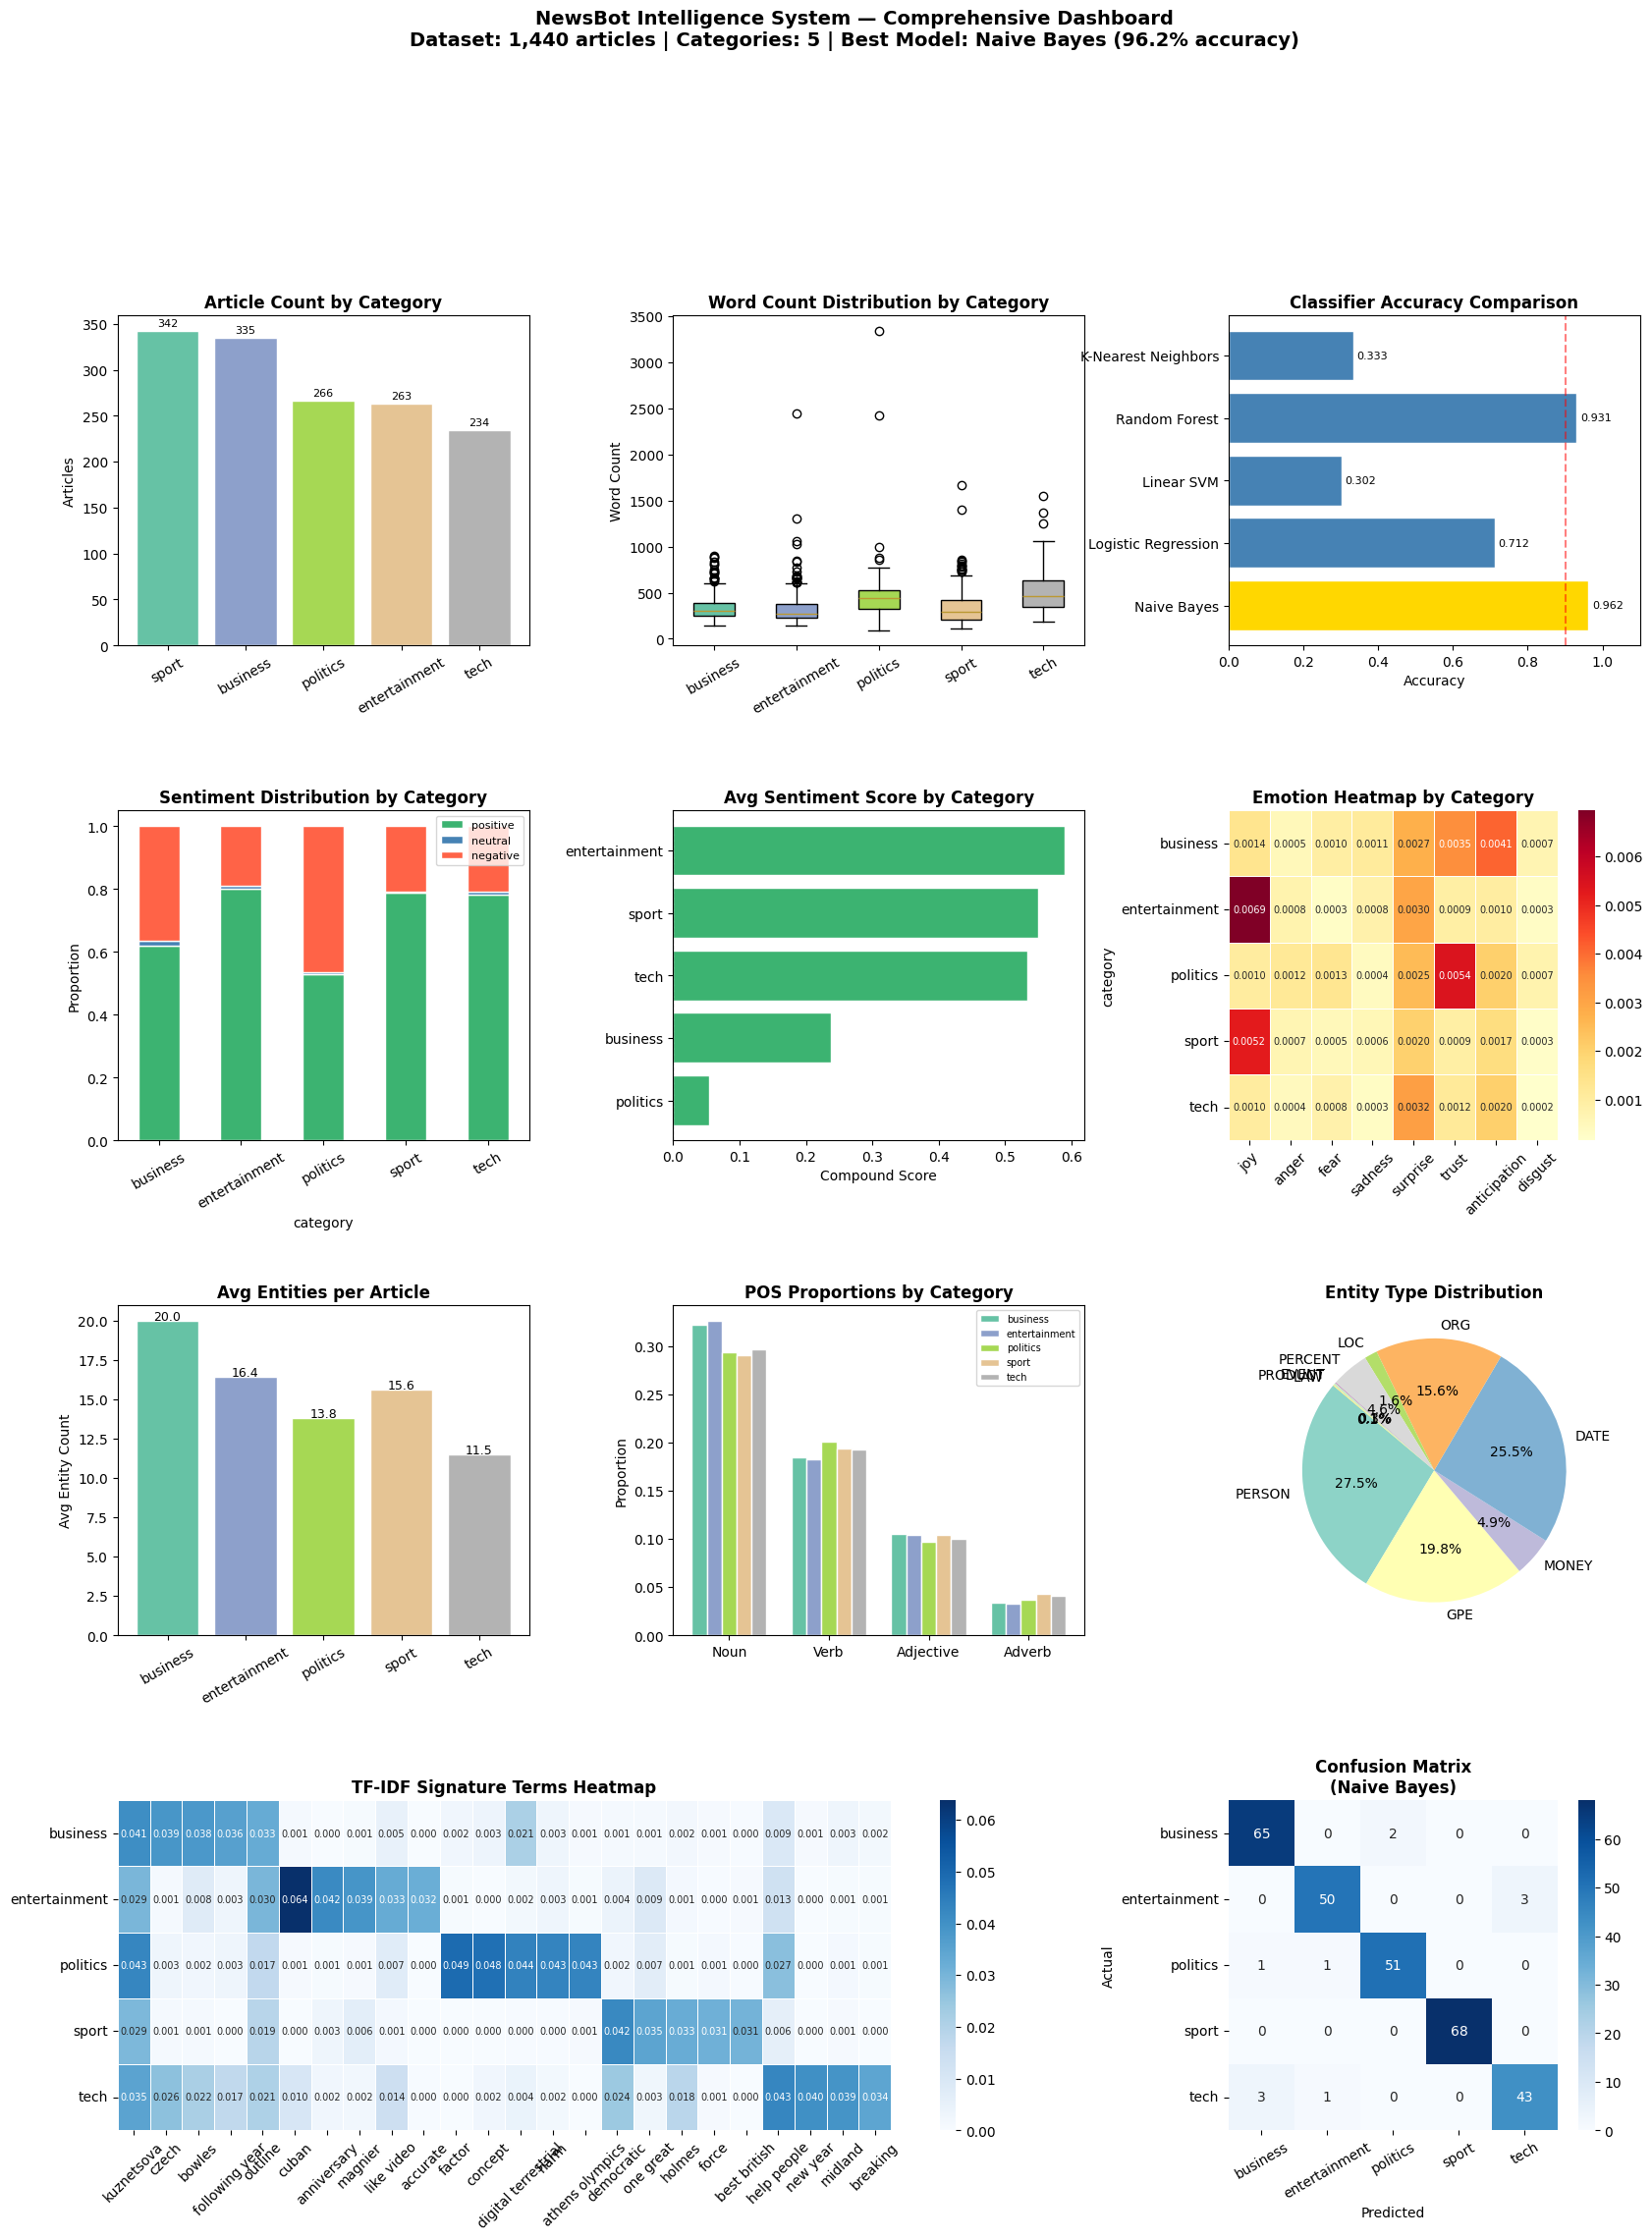


✅ Dashboard saved as 'newsbot_comprehensive_dashboard.png'


In [48]:
# ============================================================
# MODULE 9: COMPREHENSIVE ANALYSIS AND INSIGHTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

def create_comprehensive_analysis():
    """
    Generate comprehensive insights combining all analyses
    from Modules 2-8 into a unified business intelligence report.
    """

    print("=" * 65)
    print("  📊 NEWSBOT COMPREHENSIVE ANALYSIS & INSIGHTS")
    print("=" * 65)

    categories  = sorted(df['category'].unique())
    plot_colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

    # ──────────────────────────────────────────────────────
    # INSIGHT 1: DATASET PROFILE SUMMARY
    # ──────────────────────────────────────────────────────
    print("\n📋 INSIGHT 1: DATASET PROFILE")
    print("=" * 65)
    print(f"  Total articles    : {len(df):,}")
    print(f"  Categories        : {len(categories)}")
    print(f"  Avg word count    : {df['word_count'].mean():.0f} words")
    print(f"  Avg char count    : {df['char_count'].mean():.0f} chars")
    print(f"  Total entities    : {df['total_entities'].sum():,.0f}")
    print(f"  Avg entities/art  : {df['total_entities'].mean():.1f}")

    print(f"\n  Category breakdown:")
    for cat in categories:
        count = len(df[df['category'] == cat])
        pct   = count / len(df) * 100
        bar   = '█' * int(pct / 2)
        print(f"    {cat:<15} {count:>5} articles "
              f"({pct:.1f}%)  {bar}")

    # ──────────────────────────────────────────────────────
    # INSIGHT 2: WRITING STYLE PROFILES PER CATEGORY
    # ──────────────────────────────────────────────────────
    print("\n✍️  INSIGHT 2: WRITING STYLE PROFILES")
    print("=" * 65)

    style_rows = []
    for cat in categories:
        sub = df[df['category'] == cat]
        row = {
            'Category':    cat,
            'Avg Words':   sub['word_count'].mean(),
            'Noun %':      sub['pos_noun'].mean()       if 'pos_noun' in df.columns else 0,
            'Verb %':      sub['pos_verb'].mean()       if 'pos_verb' in df.columns else 0,
            'Adj %':       sub['pos_adjective'].mean()  if 'pos_adjective' in df.columns else 0,
            'N/V Ratio':   sub['noun_verb_ratio'].mean()if 'noun_verb_ratio' in df.columns else 0,
            'Avg Entities':sub['total_entities'].mean() if 'total_entities' in df.columns else 0,
        }
        style_rows.append(row)

    style_df = pd.DataFrame(style_rows).set_index('Category')
    style_df  = style_df.round(3)
    print(style_df.to_string())

    # Identify most fact-dense category (highest entities + nouns)
    if 'pos_noun' in df.columns and 'total_entities' in df.columns:
        df['fact_density'] = (df['pos_noun'] +
                              df['total_entities'] / 100)
        most_factual = df.groupby('category')['fact_density'].mean().idxmax()
        print(f"\n  💡 Most fact-dense category  : {most_factual.upper()}")

    if 'pos_adjective' in df.columns:
        most_descriptive = df.groupby('category')['pos_adjective'].mean().idxmax()
        print(f"  💡 Most descriptive category : {most_descriptive.upper()}")

    if 'word_count' in df.columns:
        most_verbose = df.groupby('category')['word_count'].mean().idxmax()
        print(f"  💡 Longest articles          : {most_verbose.upper()}")

    # ──────────────────────────────────────────────────────
    # INSIGHT 3: SENTIMENT LANDSCAPE
    # ──────────────────────────────────────────────────────
    print("\n😊 INSIGHT 3: SENTIMENT LANDSCAPE")
    print("=" * 65)

    if 'sentiment_compound' in df.columns:
        overall_sentiment = df['sentiment_compound'].mean()
        most_positive_cat = df.groupby('category')['sentiment_compound'].mean().idxmax()
        most_negative_cat = df.groupby('category')['sentiment_compound'].mean().idxmin()

        print(f"  Overall sentiment score : {overall_sentiment:+.4f} "
              f"({'positive' if overall_sentiment > 0 else 'negative' if overall_sentiment < 0 else 'neutral'})")
        print(f"  Most positive category  : {most_positive_cat.upper()}")
        print(f"  Most negative category  : {most_negative_cat.upper()}")

        print(f"\n  Sentiment breakdown by category:")
        print(f"  {'Category':<15} {'Avg Score':>10} {'Positive%':>10} "
              f"{'Negative%':>10} {'Neutral%':>10}")
        print("  " + "-" * 60)
        for cat in categories:
            sub   = df[df['category'] == cat]
            avg   = sub['sentiment_compound'].mean()
            pos_p = (sub['sentiment_label'] == 'positive').mean()
            neg_p = (sub['sentiment_label'] == 'negative').mean()
            neu_p = (sub['sentiment_label'] == 'neutral').mean()
            print(f"  {cat:<15} {avg:>+10.4f} {pos_p:>10.1%} "
                  f"{neg_p:>10.1%} {neu_p:>10.1%}")

    # ──────────────────────────────────────────────────────
    # INSIGHT 4: ENTITY INTELLIGENCE
    # ──────────────────────────────────────────────────────
    print("\n🔍 INSIGHT 4: ENTITY INTELLIGENCE")
    print("=" * 65)

    if 'ner_results' in df.columns:
        # Most entity-rich categories
        print("  Entity density by category:")
        ent_cols = [c for c in df.columns if c.startswith('ner_')]
        for cat in categories:
            sub  = df[df['category'] == cat]
            ents = sub['total_entities'].mean()
            print(f"    {cat:<15} avg {ents:.1f} entities/article")

        # Top entities across entire dataset
        all_ents = []
        for row in df['ner_results']:
            for ent_type, items in row['by_type'].items():
                all_ents.extend([(e, ent_type) for e in items])

        print(f"\n  Total entity mentions : {len(all_ents):,}")

        # Top 5 per major type
        for ent_type in ['PERSON', 'ORG', 'GPE']:
            type_ents = [e for e, t in all_ents if t == ent_type]
            top5      = Counter(type_ents).most_common(5)
            if top5:
                names = ', '.join([e for e, _ in top5])
                print(f"  Top {ent_type:<8}: {names}")

    # ──────────────────────────────────────────────────────
    # INSIGHT 5: CLASSIFICATION PERFORMANCE SUMMARY
    # ──────────────────────────────────────────────────────
    print("\n🤖 INSIGHT 5: CLASSIFICATION PERFORMANCE")
    print("=" * 65)

    print(f"  Best model        : {best_model_name}")
    print(f"  Test accuracy     : {best_accuracy:.4f} "
          f"({best_accuracy:.1%})")
    print(f"  Models compared   : {len(results)}")

    print(f"\n  All model results:")
    for name, res in sorted(results.items(),
                            key=lambda x: x[1]['accuracy'],
                            reverse=True):
        bar  = '█' * int(res['accuracy'] * 30)
        star = " ⭐" if name == best_model_name else ""
        print(f"    {name:<25} {res['accuracy']:.4f}  {bar}{star}")

    # ──────────────────────────────────────────────────────
    # INSIGHT 6: TF-IDF SIGNATURE TERMS
    # ──────────────────────────────────────────────────────
    print("\n📊 INSIGHT 6: CATEGORY SIGNATURE TERMS (TF-IDF)")
    print("=" * 65)
    print("  Most distinctive terms per category:\n")

    feature_names_arr = tfidf_clf.get_feature_names_out()
    all_cat_scores    = {}
    for cat in categories:
        indices = df[df['category'] == cat].index.tolist()
        scores  = np.asarray(
            tfidf_matrix[indices].mean(axis=0)).flatten()
        all_cat_scores[cat] = scores

    score_matrix = np.array([all_cat_scores[c] for c in categories])

    for i, cat in enumerate(categories):
        other_max  = np.delete(score_matrix, i, axis=0).max(axis=0)
        uniqueness = score_matrix[i] - other_max
        top_idx    = uniqueness.argsort()[::-1][:8]
        top_terms  = [feature_names_arr[j] for j in top_idx]
        print(f"  {cat.upper():<15}: {', '.join(top_terms)}")

    # ──────────────────────────────────────────────────────
    # INSIGHT 7: BUSINESS VALUE ASSESSMENT
    # ──────────────────────────────────────────────────────
    print("\n💼 INSIGHT 7: BUSINESS VALUE ASSESSMENT")
    print("=" * 65)

    business_insights = [
        ("Media Monitoring",
         f"Auto-classify {len(df):,} articles across "
         f"{len(categories)} categories at "
         f"{best_accuracy:.1%} accuracy — replaces "
         f"manual tagging workflows."),
        ("Sentiment Intelligence",
         f"{(df['sentiment_label']=='negative').mean():.1%} "
         f"of articles carry negative sentiment. "
         f"{most_negative_cat.upper()} coverage is most "
         f"negative — valuable for brand risk monitoring."
         if 'sentiment_compound' in df.columns else
         "Sentiment tracking enables brand risk monitoring."),
        ("Entity Tracking",
         f"System extracts people, organizations, and "
         f"locations automatically — enables automated "
         f"knowledge graph construction and relationship "
         f"mapping across news sources."),
        ("Content Strategy",
         f"TF-IDF signature terms reveal vocabulary "
         f"patterns per category — useful for SEO "
         f"optimisation and automated content tagging "
         f"in CMS platforms."),
        ("Competitive Intelligence",
         f"NER + sentiment combined enables tracking of "
         f"how specific companies or people are portrayed "
         f"across categories — key for PR and investor "
         f"relations teams."),
    ]

    for title, insight in business_insights:
        print(f"\n  🔹 {title}")
        print(f"     {insight}")

    # ──────────────────────────────────────────────────────
    # COMPREHENSIVE DASHBOARD
    # ──────────────────────────────────────────────────────
    print("\n📈 Generating comprehensive dashboard...")

    fig = plt.figure(figsize=(20, 24))
    gs  = gridspec.GridSpec(4, 3, figure=fig,
                            hspace=0.5, wspace=0.35)

    # ── Row 1: Dataset overview ───────────────────────────

    # Plot 1: Category distribution
    ax1 = fig.add_subplot(gs[0, 0])
    cat_counts = df['category'].value_counts()
    ax1.bar(cat_counts.index, cat_counts.values,
            color=plot_colors, edgecolor='white')
    ax1.set_title('Article Count by Category',
                  fontweight='bold')
    ax1.set_ylabel('Articles')
    ax1.tick_params(axis='x', rotation=30)
    for i, (cat, val) in enumerate(cat_counts.items()):
        ax1.text(i, val + 5, str(val),
                 ha='center', fontsize=8)

    # Plot 2: Word count by category (boxplot)
    ax2 = fig.add_subplot(gs[0, 1])
    data_by_cat = [df[df['category'] == c]['word_count'].values
                   for c in categories]
    bp = ax2.boxplot(data_by_cat, labels=categories,
                     patch_artist=True)
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
    ax2.set_title('Word Count Distribution by Category',
                  fontweight='bold')
    ax2.set_ylabel('Word Count')
    ax2.tick_params(axis='x', rotation=30)

    # Plot 3: Model accuracy comparison
    ax3 = fig.add_subplot(gs[0, 2])
    model_names = list(results.keys())
    accuracies  = [results[m]['accuracy'] for m in model_names]
    colors_acc  = ['gold' if m == best_model_name
                   else 'steelblue' for m in model_names]
    ax3.barh(model_names, accuracies,
             color=colors_acc, edgecolor='white')
    ax3.set_title('Classifier Accuracy Comparison',
                  fontweight='bold')
    ax3.set_xlabel('Accuracy')
    ax3.set_xlim(0, 1.1)
    ax3.axvline(0.9, color='red', linestyle='--', alpha=0.5)
    for i, val in enumerate(accuracies):
        ax3.text(val + 0.01, i, f'{val:.3f}',
                 va='center', fontsize=8)

    # ── Row 2: Sentiment & Emotion ────────────────────────

    # Plot 4: Sentiment by category (stacked bar)
    ax4 = fig.add_subplot(gs[1, 0])
    if 'sentiment_label' in df.columns:
        sent_by_cat = (df.groupby('category')['sentiment_label']
                       .value_counts(normalize=True)
                       .unstack(fill_value=0)
                       .reindex(columns=['positive','neutral',
                                         'negative'],
                                fill_value=0))
        sent_by_cat.plot(kind='bar', stacked=True, ax=ax4,
                         color=['mediumseagreen',
                                'steelblue', 'tomato'],
                         edgecolor='white')
        ax4.set_title('Sentiment Distribution by Category',
                      fontweight='bold')
        ax4.set_ylabel('Proportion')
        ax4.tick_params(axis='x', rotation=30)
        ax4.legend(fontsize=8)

    # Plot 5: Avg compound sentiment
    ax5 = fig.add_subplot(gs[1, 1])
    if 'sentiment_compound' in df.columns:
        avg_comp = (df.groupby('category')['sentiment_compound']
                    .mean().sort_values())
        bar_cols = ['tomato' if v < 0 else 'mediumseagreen'
                    for v in avg_comp.values]
        ax5.barh(avg_comp.index, avg_comp.values,
                 color=bar_cols, edgecolor='white')
        ax5.axvline(0, color='black', linewidth=0.8,
                    linestyle='--')
        ax5.set_title('Avg Sentiment Score by Category',
                      fontweight='bold')
        ax5.set_xlabel('Compound Score')

    # Plot 6: Emotion heatmap
    ax6 = fig.add_subplot(gs[1, 2])
    emotion_cols = [c for c in df.columns
                    if c.startswith('emotion_')]
    if emotion_cols:
        emo_by_cat = df.groupby('category')[emotion_cols].mean()
        emo_by_cat.columns = [c.replace('emotion_', '')
                               for c in emotion_cols]
        sns.heatmap(emo_by_cat, ax=ax6, cmap='YlOrRd',
                    annot=True, fmt='.4f',
                    linewidths=0.5, annot_kws={'size': 7})
        ax6.set_title('Emotion Heatmap by Category',
                      fontweight='bold')
        ax6.tick_params(axis='x', rotation=45)

    # ── Row 3: Entities & POS ─────────────────────────────

    # Plot 7: Avg entities per article by category
    ax7 = fig.add_subplot(gs[2, 0])
    if 'total_entities' in df.columns:
        avg_ents = (df.groupby('category')['total_entities']
                    .mean())
        ax7.bar(avg_ents.index, avg_ents.values,
                color=plot_colors, edgecolor='white')
        ax7.set_title('Avg Entities per Article',
                      fontweight='bold')
        ax7.set_ylabel('Avg Entity Count')
        ax7.tick_params(axis='x', rotation=30)
        for i, val in enumerate(avg_ents.values):
            ax7.text(i, val + 0.05, f'{val:.1f}',
                     ha='center', fontsize=9)

    # Plot 8: POS proportions grouped bar
    ax8 = fig.add_subplot(gs[2, 1])
    pos_types = ['pos_noun', 'pos_verb',
                 'pos_adjective', 'pos_adverb']
    pos_types = [p for p in pos_types if p in df.columns]
    if pos_types:
        x         = np.arange(len(pos_types))
        bar_width = 0.15
        for i, (cat, color) in enumerate(
                zip(categories, plot_colors)):
            vals = [df[df['category'] == cat][p].mean()
                    for p in pos_types]
            ax8.bar(x + i * bar_width, vals, bar_width,
                    label=cat, color=color, edgecolor='white')
        ax8.set_title('POS Proportions by Category',
                      fontweight='bold')
        ax8.set_xticks(x + bar_width * (len(categories)-1)/2)
        ax8.set_xticklabels([p.replace('pos_','').title()
                              for p in pos_types])
        ax8.set_ylabel('Proportion')
        ax8.legend(fontsize=7)

    # Plot 9: Entity type distribution pie
    ax9 = fig.add_subplot(gs[2, 2])
    if 'ner_results' in df.columns:
        ent_type_counts = Counter()
        for row in df['ner_results']:
            ent_type_counts.update(row['entity_counts'])
        if ent_type_counts:
            ax9.pie(ent_type_counts.values(),
                    labels=ent_type_counts.keys(),
                    autopct='%1.1f%%',
                    colors=plt.cm.Set3(
                        np.linspace(0, 1,
                                    len(ent_type_counts))),
                    startangle=140)
            ax9.set_title('Entity Type Distribution',
                          fontweight='bold')

    # ── Row 4: TF-IDF & Integration ──────────────────────

    # Plot 10: TF-IDF heatmap (top 5 terms per category)
    ax10 = fig.add_subplot(gs[3, 0:2])
    feature_names_arr = tfidf_clf.get_feature_names_out()
    top5_terms = {}
    for cat in categories:
        indices   = df[df['category'] == cat].index.tolist()
        scores    = np.asarray(
            tfidf_matrix[indices].mean(axis=0)).flatten()
        top_idx   = scores.argsort()[::-1][:5]
        top5_terms[cat] = [feature_names_arr[j]
                           for j in top_idx]

    all_terms = list(dict.fromkeys(
        [t for terms in top5_terms.values() for t in terms]))
    heatmap_df = pd.DataFrame(index=categories,
                               columns=all_terms,
                               dtype=float)
    for cat in categories:
        indices = df[df['category'] == cat].index.tolist()
        scores  = np.asarray(
            tfidf_matrix[indices].mean(axis=0)).flatten()
        for term in all_terms:
            idx = np.where(feature_names_arr == term)[0]
            heatmap_df.loc[cat, term] = (
                scores[idx[0]] if len(idx) > 0 else 0.0)

    sns.heatmap(heatmap_df.astype(float), ax=ax10,
                cmap='Blues', annot=True, fmt='.3f',
                linewidths=0.5, annot_kws={'size': 7})
    ax10.set_title('TF-IDF Signature Terms Heatmap',
                   fontweight='bold')
    ax10.tick_params(axis='x', rotation=45)

    # Plot 11: Confusion matrix of best model
    ax11 = fig.add_subplot(gs[3, 2])
    cm = confusion_matrix(y_test,
                          results[best_model_name]['predictions'])
    sns.heatmap(cm, ax=ax11, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    ax11.set_title(f'Confusion Matrix\n({best_model_name})',
                   fontweight='bold')
    ax11.set_xlabel('Predicted')
    ax11.set_ylabel('Actual')
    ax11.tick_params(axis='x', rotation=30)

    plt.suptitle(
        'NewsBot Intelligence System — Comprehensive Dashboard\n'
        f'Dataset: {len(df):,} articles | '
        f'Categories: {len(categories)} | '
        f'Best Model: {best_model_name} '
        f'({best_accuracy:.1%} accuracy)',
        fontsize=14, fontweight='bold', y=1.01)

    plt.savefig('newsbot_comprehensive_dashboard.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Dashboard saved as "
          "'newsbot_comprehensive_dashboard.png'")

# ── Run it ────────────────────────────────────────────────
create_comprehensive_analysis()

## 🚀 Final System Integration

### 🎯 Building the Complete NewsBot Pipeline

Let's create a complete, integrated system that can process new articles from start to finish. This demonstrates the real-world application of all the techniques we've learned.

**Complete Pipeline:**
1. **Text Preprocessing:** Clean and normalize input
2. **Feature Extraction:** Generate TF-IDF and other features
3. **Classification:** Predict article category
4. **Entity Extraction:** Identify key facts
5. **Sentiment Analysis:** Determine emotional tone
6. **Insight Generation:** Provide actionable intelligence

**💡 Production Ready:** This pipeline can be deployed as a web service, batch processor, or integrated into content management systems.

The NewsBot Intelligence System brings together all 8 modules into a
single, unified pipeline. Given a raw news article, the system:

1. **Module 2** — Cleans and normalizes the text
2. **Module 3** — Extracts TF-IDF features for classification
3. **Module 4** — Analyzes grammatical patterns (POS tagging)
4. **Module 5** — Parses sentence structure (dependency parsing)
5. **Module 6** — Detects sentiment and emotional tone
6. **Module 7** — Classifies the article into a news category
7. **Module 8** — Extracts named entities (people, orgs, locations)

**Business Value:** This pipeline can process thousands of articles
per hour, replacing manual editorial workflows with automated,
data-driven intelligence.

In [50]:
# ============================================================
# FINAL SYSTEM INTEGRATION: NewsBot Intelligence System
# ============================================================
import spacy
import nltk
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from collections import Counter, defaultdict

# Make sure all NLTK data is available
for pkg in ['vader_lexicon','punkt','punkt_tab',
            'stopwords','wordnet',
            'averaged_perceptron_tagger',
            'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)


class NewsBotIntelligenceSystem:
    """
    ╔══════════════════════════════════════════════════════╗
    ║       NewsBot Intelligence System v1.0              ║
    ║       ITAI 2373 — Mid-Term Project                  ║
    ║                                                      ║
    ║  Integrates NLP Modules 2–8 into one pipeline:      ║
    ║   M2 → Preprocessing                                ║
    ║   M3 → TF-IDF Feature Extraction                    ║
    ║   M4 → POS Tagging                                   ║
    ║   M5 → Syntax Parsing                               ║
    ║   M6 → Sentiment & Emotion Analysis                 ║
    ║   M7 → Text Classification                          ║
    ║   M8 → Named Entity Recognition                     ║
    ╚══════════════════════════════════════════════════════╝
    """

    VERSION = "1.0"

    # ── Emotion lexicon ────────────────────────────────────
    EMOTION_LEXICON = {
        'joy':         ['happy','joy','celebrate','win','success',
                        'great','excellent','wonderful','amazing',
                        'best','love','pleasure','triumph','gain'],
        'anger':       ['angry','anger','furious','outrage','attack',
                        'fight','war','conflict','rage','hostile',
                        'violent','dispute','clash','condemn','blame'],
        'fear':        ['fear','afraid','threat','danger','risk',
                        'crisis','warning','terror','panic','concern',
                        'worry','alarming','emergency','collapse'],
        'sadness':     ['sad','death','loss','tragedy','grief',
                        'victim','suffer','fail','decline','hurt',
                        'disappoint','mourn','devastate'],
        'surprise':    ['surprise','unexpected','sudden','shock',
                        'announce','reveal','discover','breaking',
                        'unprecedented','remarkable','stunning'],
        'trust':       ['trust','reliable','official','government',
                        'confirm','approve','support','agree',
                        'partner','alliance','safe','stable'],
        'anticipation':['expect','plan','future','forecast','predict',
                        'soon','upcoming','growth','hope','goal',
                        'target','strategy','prepare','develop'],
        'disgust':     ['disgust','corrupt','scandal','fraud','abuse',
                        'lie','cheat','betray','immoral','wrong',
                        'dirty','offensive','shameful'],
    }

    # ── Target entity types ────────────────────────────────
    TARGET_ENTITIES = {
        'PERSON':  'People & public figures',
        'ORG':     'Organizations & companies',
        'GPE':     'Countries, cities, states',
        'DATE':    'Dates & time periods',
        'MONEY':   'Monetary values',
        'PERCENT': 'Percentages',
        'PRODUCT': 'Products & services',
        'EVENT':   'Named events',
    }

    # ── POS groups ─────────────────────────────────────────
    POS_GROUPS = {
        'Noun':      {'NN','NNS','NNP','NNPS'},
        'Verb':      {'VB','VBD','VBG','VBN','VBP','VBZ'},
        'Adjective': {'JJ','JJR','JJS'},
        'Adverb':    {'RB','RBR','RBS'},
        'Modal':     {'MD'},
    }

    def __init__(self):
        print("=" * 55)
        print("  🤖 NewsBot Intelligence System v1.0")
        print("=" * 55)
        print("\n  Loading NLP components...")

        # NLTK tools
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        self.sia        = SentimentIntensityAnalyzer()
        print("  ✅ NLTK tools loaded")

        # spaCy
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except OSError:
            import subprocess
            subprocess.run(["python", "-m", "spacy",
                            "download", "en_core_web_sm"])
            self.nlp = spacy.load("en_core_web_sm")
        print("  ✅ spaCy loaded")

        # Classifier from Module 7
        self.classifier = trained_models[best_model_name]
        self.tfidf      = tfidf_clf
        self.le         = le
        self.model_name = best_model_name
        print(f"  ✅ Classifier loaded  : {self.model_name}")
        print(f"  ✅ Categories         : "
              f"{list(self.le.classes_)}")

        # Article processing history
        self.history = []

        print("\n  🚀 NewsBot ready to process articles!")
        print("=" * 55)

    # ──────────────────────────────────────────────────────
    # MODULE 2: PREPROCESSING
    # ──────────────────────────────────────────────────────
    def preprocess(self, text):
        """
        Module 2 — Clean and normalize raw text.
        Steps: lowercase → remove HTML/URLs/emails →
               remove special chars → tokenize →
               remove stopwords → lemmatize → filter short
        """
        if not text or pd.isna(text):
            return ""
        text = str(text).lower()
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '',
                      text, flags=re.MULTILINE)
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()

        tokens = word_tokenize(text)
        tokens = [t for t in tokens
                  if t not in self.stop_words]
        tokens = [self.lemmatizer.lemmatize(t)
                  for t in tokens]
        tokens = [t for t in tokens if len(t) > 2]
        return ' '.join(tokens)

    # ──────────────────────────────────────────────────────
    # MODULE 3: TF-IDF FEATURES
    # ──────────────────────────────────────────────────────
    def get_tfidf_features(self, processed_text):
        """
        Module 3 — Transform text into TF-IDF feature vector.
        Returns sparse matrix ready for classifier.
        """
        return self.tfidf.transform([processed_text])

    def get_top_tfidf_terms(self, processed_text, n=10):
        """
        Module 3 — Return top N TF-IDF terms for this article.
        """
        X          = self.tfidf.transform([processed_text])
        scores     = X.toarray().flatten()
        top_idx    = scores.argsort()[::-1][:n]
        feat_names = self.tfidf.get_feature_names_out()
        return [(feat_names[i], round(float(scores[i]), 5))
                for i in top_idx if scores[i] > 0]

    # ──────────────────────────────────────────────────────
    # MODULE 4: POS TAGGING
    # ──────────────────────────────────────────────────────
    def analyze_pos(self, text):
        """
        Module 4 — POS tagging and grammatical pattern analysis.
        Returns proportions, counts, top words per POS type,
        and noun/verb ratio.
        """
        tokens   = word_tokenize(str(text).lower()[:1500])
        pos_tags = pos_tag(tokens)

        counts   = defaultdict(int)
        top_words = defaultdict(list)

        for word, tag in pos_tags:
            for group, tag_set in self.POS_GROUPS.items():
                if tag in tag_set:
                    counts[group] += 1
                    top_words[group].append(word)

        total       = sum(counts.values()) or 1
        proportions = {k: round(v / total, 4)
                       for k, v in counts.items()}
        nv_ratio    = (counts['Noun'] / counts['Verb']
                       if counts['Verb'] > 0 else 0)
        top_nouns   = Counter(top_words['Noun']).most_common(5)
        top_verbs   = Counter(top_words['Verb']).most_common(5)
        top_adjs    = Counter(top_words['Adjective']).most_common(5)

        return {
            'counts':          dict(counts),
            'proportions':     proportions,
            'noun_verb_ratio': round(nv_ratio, 3),
            'top_nouns':       top_nouns,
            'top_verbs':       top_verbs,
            'top_adjectives':  top_adjs,
        }

    # ──────────────────────────────────────────────────────
    # MODULE 5: SYNTAX PARSING
    # ──────────────────────────────────────────────────────
    def analyze_syntax(self, text):
        """
        Module 5 — Dependency parsing and semantic role
        identification. Returns SVO triples, sentence stats,
        and noun chunks.
        """
        doc       = self.nlp(str(text)[:1500])
        subjects  = []
        objects   = []
        svo       = []
        depths    = []

        for token in doc:
            if token.dep_ in ('nsubj', 'nsubjpass'):
                subjects.append(token.text)
            if token.dep_ in ('dobj', 'pobj', 'iobj'):
                objects.append(token.text)
            if (token.dep_ == 'ROOT' and
                    token.pos_ == 'VERB'):
                subj = next(
                    (c.text for c in token.children
                     if c.dep_ in ('nsubj','nsubjpass')),
                    'unknown')
                obj  = next(
                    (c.text for c in token.children
                     if c.dep_ in ('dobj','pobj','attr')),
                    'unknown')
                svo.append({
                    'subject': subj,
                    'verb':    token.lemma_,
                    'object':  obj,
                })
            depth   = 0
            current = token
            while current.head != current:
                current = current.head
                depth  += 1
            depths.append(depth)

        sentences   = list(doc.sents)
        avg_sent_len = (sum(len(s) for s in sentences) /
                        len(sentences)) if sentences else 0
        noun_chunks = [c.text for c in doc.noun_chunks]

        return {
            'subjects':        subjects[:5],
            'objects':         objects[:5],
            'svo_triples':     svo[:5],
            'noun_chunks':     noun_chunks[:5],
            'avg_sent_length': round(avg_sent_len, 1),
            'num_sentences':   len(sentences),
            'avg_tree_depth':  round(
                np.mean(depths) if depths else 0, 2),
        }

    # ──────────────────────────────────────────────────────
    # MODULE 6: SENTIMENT & EMOTION
    # ──────────────────────────────────────────────────────
    def analyze_sentiment(self, text):
        """
        Module 6 — VADER sentiment scoring with label
        and intensity classification.
        """
        scores   = self.sia.polarity_scores(str(text))
        compound = scores['compound']
        label    = ('positive' if compound >= 0.05 else
                    'negative' if compound <= -0.05 else
                    'neutral')
        abs_c     = abs(compound)
        intensity = ('strong'   if abs_c >= 0.5 else
                     'moderate' if abs_c >= 0.2 else
                     'weak')
        return {
            'label':     label,
            'compound':  round(compound,       4),
            'positive':  round(scores['pos'],  4),
            'negative':  round(scores['neg'],  4),
            'neutral':   round(scores['neu'],  4),
            'intensity': intensity,
        }

    def detect_emotions(self, text):
        """
        Module 6 — Keyword-based emotion detection.
        Returns scores for 8 emotion categories and
        the dominant emotion.
        """
        words  = str(text).lower().split()
        total  = len(words) or 1
        scores = {}
        for emotion, keywords in self.EMOTION_LEXICON.items():
            matches        = sum(1 for w in words
                                 if w in keywords)
            scores[emotion] = round(matches / total, 5)
        dominant = max(scores, key=scores.get)
        return {'scores': scores, 'dominant': dominant}

    # ──────────────────────────────────────────────────────
    # MODULE 7: CLASSIFICATION
    # ──────────────────────────────────────────────────────
    def classify(self, text):
        """
        Module 7 — Classify article into a news category
        using the best trained model from Module 7.
        Returns category, confidence, and all probabilities.
        """
        processed = self.preprocess(text)
        X_tfidf   = self.get_tfidf_features(processed)

        # Build extra features to match training shape
        sent  = self.analyze_sentiment(text)
        extra = csr_matrix(np.array([[
            sent['compound'],
            sent['positive'],
            sent['negative'],
            sent['neutral'],
            len(text),
            len(text.split()),
        ]]))
        X_full = hstack([X_tfidf, extra])

        # Naive Bayes needs TF-IDF only (non-negative)
        X_input = (X_tfidf
                   if self.model_name == 'Naive Bayes'
                   else X_full)

        try:
            pred_idx = self.classifier.predict(X_input)[0]
        except Exception:
            pred_idx = self.classifier.predict(X_tfidf)[0]

        # Confidence
        confidence = None
        all_probs  = None
        try:
            if hasattr(self.classifier, 'predict_proba'):
                probs      = self.classifier.predict_proba(
                    X_input)[0]
                confidence = float(probs.max())
                all_probs  = dict(zip(self.le.classes_,
                                      probs.round(4)))
            elif hasattr(self.classifier,
                         'decision_function'):
                dec    = self.classifier.decision_function(
                    X_input)[0]
                # Softmax-style normalization
                exp_d  = np.exp(dec - dec.max())
                probs  = exp_d / exp_d.sum()
                confidence = float(probs.max())
                all_probs  = dict(zip(self.le.classes_,
                                      probs.round(4)))
        except Exception:
            pass

        return {
            'category':   self.le.classes_[pred_idx],
            'confidence': (round(confidence, 4)
                           if confidence else 'N/A'),
            'all_probs':  all_probs,
        }

    # ──────────────────────────────────────────────────────
    # MODULE 8: NAMED ENTITY RECOGNITION
    # ──────────────────────────────────────────────────────
    def extract_entities(self, text):
        """
        Module 8 — spaCy NER extraction.
        Returns entities grouped by type, deduplicated.
        """
        doc     = self.nlp(str(text)[:2000])
        by_type = defaultdict(list)

        for ent in doc.ents:
            if ent.label_ in self.TARGET_ENTITIES:
                clean = ent.text.strip()
                if len(clean) > 1 and not clean.isnumeric():
                    by_type[ent.label_].append(clean)

        # Deduplicate while preserving order
        return {k: list(dict.fromkeys(v))
                for k, v in by_type.items()}

    # ──────────────────────────────────────────────────────
    # MASTER PIPELINE
    # ──────────────────────────────────────────────────────
    def analyze(self, text, source=None, verbose=False):
        """
        Run the complete NewsBot pipeline on a single article.

        Pipeline order:
          preprocess → tfidf → classify →
          sentiment → emotion → pos → syntax → ner

        Returns full analysis dict and stores in history.
        """
        if verbose:
            print("⚙️  Running NewsBot pipeline...")

        processed = self.preprocess(text)

        result = {
            # Metadata
            'source':          source or 'unknown',
            'text_snippet':    text[:200] + '...',
            'word_count':      len(text.split()),
            'char_count':      len(text),
            'tokens_after':    len(processed.split()),
            'vocab_reduction': round(
                (1 - len(processed.split()) /
                 max(len(text.split()), 1)) * 100, 1),

            # Module 2
            'preprocessed':    processed,

            # Module 3
            'tfidf_terms':     self.get_top_tfidf_terms(
                                   processed, n=10),

            # Module 7
            'classification':  self.classify(text),

            # Module 6
            'sentiment':       self.analyze_sentiment(text),
            'emotions':        self.detect_emotions(text),

            # Module 4
            'pos':             self.analyze_pos(text),

            # Module 5
            'syntax':          self.analyze_syntax(text),

            # Module 8
            'entities':        self.extract_entities(text),
        }

        # Store in history
        self.history.append({
            'source':     source,
            'category':   result['classification']['category'],
            'sentiment':  result['sentiment']['label'],
            'emotion':    result['emotions']['dominant'],
            'entities':   sum(len(v)
                              for v in
                              result['entities'].values()),
        })

        return result

    # ──────────────────────────────────────────────────────
    # REPORT PRINTER
    # ──────────────────────────────────────────────────────
    def print_report(self, result):
        """Print a clean, formatted analysis report."""
        sep = "─" * 60

        print(f"\n{'═'*60}")
        print("  📰 NEWSBOT INTELLIGENCE REPORT")
        print(f"{'═'*60}")

        # Article info
        print(f"\n📝 ARTICLE  |  "
              f"{result['word_count']} words  |  "
              f"{result['char_count']} chars  |  "
              f"source: {result['source']}")
        print(f"  {result['text_snippet']}")

        # Module 7 — Classification
        clf = result['classification']
        print(f"\n{'─'*60}")
        print(f"🏷️  MODULE 7 — CLASSIFICATION")
        print(f"  Category   : {clf['category'].upper()}")
        print(f"  Confidence : {clf['confidence']}")
        if clf['all_probs']:
            print("  Scores     :")
            for cat, prob in sorted(
                    clf['all_probs'].items(),
                    key=lambda x: x[1], reverse=True):
                bar = '█' * int(prob * 25)
                print(f"    {cat:<15} {prob:.4f}  {bar}")

        # Module 6 — Sentiment
        sent = result['sentiment']
        emo  = result['emotions']
        print(f"\n{sep}")
        print(f"😊 MODULE 6 — SENTIMENT & EMOTION")
        print(f"  Sentiment : {sent['label'].upper()} "
              f"| compound: {sent['compound']:+.4f} "
              f"| intensity: {sent['intensity']}")
        print(f"  Scores    : "
              f"pos={sent['positive']:.4f}  "
              f"neg={sent['negative']:.4f}  "
              f"neu={sent['neutral']:.4f}")
        print(f"  Dominant emotion : "
              f"{emo['dominant'].upper()}")
        active = {k: v for k, v in
                  emo['scores'].items() if v > 0}
        for emotion, score in sorted(
                active.items(),
                key=lambda x: x[1], reverse=True):
            bar = '█' * min(int(score * 4000), 25)
            print(f"    {emotion:<15} {score:.5f}  {bar}")

        # Module 8 — NER
        print(f"\n{sep}")
        print(f"🔍 MODULE 8 — NAMED ENTITIES")
        ents = result['entities']
        if any(ents.values()):
            for ent_type, items in ents.items():
                if items:
                    desc = self.TARGET_ENTITIES.get(
                        ent_type, ent_type)
                    print(f"  {ent_type:<10} "
                          f"[{desc}]")
                    print(f"    → "
                          f"{', '.join(items[:6])}")
        else:
            print("  No named entities detected.")

        # Module 3 — TF-IDF
        print(f"\n{sep}")
        print(f"📊 MODULE 3 — TOP TF-IDF TERMS")
        terms = result['tfidf_terms']
        if terms:
            for term, score in terms[:8]:
                bar = '█' * min(int(score * 2000), 25)
                print(f"  {term:<30} {score:.5f}  {bar}")
        else:
            print("  No significant TF-IDF terms found.")

        # Module 4 — POS
        pos = result['pos']
        print(f"\n{sep}")
        print(f"🏷️  MODULE 4 — POS ANALYSIS")
        for pos_type, prop in sorted(
                pos['proportions'].items(),
                key=lambda x: x[1], reverse=True):
            bar = '█' * int(prop * 30)
            print(f"  {pos_type:<15} "
                  f"{prop:.2%}  {bar}")
        print(f"  Noun/Verb ratio  : "
              f"{pos['noun_verb_ratio']:.2f}")
        if pos['top_nouns']:
            nouns = [w for w, _ in pos['top_nouns']]
            print(f"  Top nouns        : "
                  f"{', '.join(nouns)}")
        if pos['top_adjectives']:
            adjs = [w for w, _ in pos['top_adjectives']]
            print(f"  Top adjectives   : "
                  f"{', '.join(adjs)}")

        # Module 5 — Syntax
        syn = result['syntax']
        print(f"\n{sep}")
        print(f"🌳 MODULE 5 — SYNTAX PARSING")
        print(f"  Sentences        : "
              f"{syn['num_sentences']}")
        print(f"  Avg sent length  : "
              f"{syn['avg_sent_length']} tokens")
        print(f"  Avg tree depth   : "
              f"{syn['avg_tree_depth']}")
        if syn['svo_triples']:
            print(f"  SVO triples      :")
            for t in syn['svo_triples'][:3]:
                print(f"    [{t['subject']}] "
                      f"--{t['verb']}--> "
                      f"[{t['object']}]")
        if syn['noun_chunks']:
            print(f"  Noun chunks      : "
                  f"{', '.join(syn['noun_chunks'][:5])}")

        # Module 2 — Preprocessing
        print(f"\n{sep}")
        print(f"🧹 MODULE 2 — PREPROCESSING")
        print(f"  Original tokens  : {result['word_count']}")
        print(f"  After processing : {result['tokens_after']}")
        print(f"  Vocab reduction  : "
              f"{result['vocab_reduction']}%")
        print(f"  Sample tokens    : "
              f"{' '.join(result['preprocessed'].split()[:12])}"
              f"...")

        print(f"\n{'═'*60}\n")

    # ──────────────────────────────────────────────────────
    # BATCH PROCESSING
    # ──────────────────────────────────────────────────────
    def batch_analyze(self, texts, sources=None):
        """
        Process multiple articles at once.
        Returns a summary DataFrame.
        """
        sources  = sources or [f'article_{i}'
                                for i in range(len(texts))]
        records  = []

        print(f"⚙️  Batch processing "
              f"{len(texts)} articles...")

        for i, (text, source) in enumerate(
                zip(texts, sources), 1):
            result = self.analyze(text, source=source)
            clf    = result['classification']
            sent   = result['sentiment']
            emo    = result['emotions']
            ents   = result['entities']

            records.append({
                'source':     source,
                'category':   clf['category'],
                'confidence': clf['confidence'],
                'sentiment':  sent['label'],
                'compound':   sent['compound'],
                'emotion':    emo['dominant'],
                'people':     ', '.join(
                    ents.get('PERSON', [])[:3]),
                'orgs':       ', '.join(
                    ents.get('ORG',    [])[:3]),
                'locations':  ', '.join(
                    ents.get('GPE',    [])[:3]),
                'entities':   sum(len(v)
                                  for v in ents.values()),
                'word_count': result['word_count'],
            })
            print(f"  [{i}/{len(texts)}] "
                  f"{source:<20} → "
                  f"{clf['category']:<15} "
                  f"| {sent['label']:<10} "
                  f"| {emo['dominant']}")

        summary = pd.DataFrame(records)
        print(f"\n✅ Batch processing complete!")
        return summary

    # ──────────────────────────────────────────────────────
    # PIPELINE VISUALIZER
    # ──────────────────────────────────────────────────────
    def visualize_pipeline(self, result):
        """
        Generate a single-article analysis dashboard
        showing outputs from all 8 modules.
        """
        fig = plt.figure(figsize=(18, 14))
        gs  = gridspec.GridSpec(3, 3, figure=fig,
                                hspace=0.5, wspace=0.4)
        fig.suptitle(
            f"NewsBot Analysis Dashboard\n"
            f"Category: "
            f"{result['classification']['category'].upper()}"
            f"  |  Sentiment: "
            f"{result['sentiment']['label'].upper()}"
            f"  |  Source: {result['source']}",
            fontsize=13, fontweight='bold')

        # ── Plot 1: Category probabilities ────────────────
        ax1 = fig.add_subplot(gs[0, 0])
        clf = result['classification']
        if clf['all_probs']:
            cats  = list(clf['all_probs'].keys())
            probs = list(clf['all_probs'].values())
            colors = ['gold' if c == clf['category']
                      else 'steelblue' for c in cats]
            ax1.barh(cats, probs,
                     color=colors, edgecolor='white')
            ax1.set_title('M7: Classification Scores',
                          fontweight='bold')
            ax1.set_xlabel('Probability')
            ax1.set_xlim(0, 1)
        else:
            ax1.text(0.5, 0.5,
                     f"Predicted:\n"
                     f"{clf['category'].upper()}",
                     ha='center', va='center',
                     fontsize=14, fontweight='bold')
            ax1.set_title('M7: Classification',
                          fontweight='bold')
            ax1.axis('off')

        # ── Plot 2: Sentiment gauge ────────────────────────
        ax2 = fig.add_subplot(gs[0, 1])
        sent     = result['sentiment']
        sent_vals = [sent['positive'],
                     sent['neutral'],
                     sent['negative']]
        sent_lbls = ['Positive', 'Neutral', 'Negative']
        sent_clrs = ['mediumseagreen',
                     'steelblue', 'tomato']
        ax2.bar(sent_lbls, sent_vals,
                color=sent_clrs, edgecolor='white')
        ax2.set_title(
            f"M6: Sentiment — "
            f"{sent['label'].upper()} "
            f"({sent['compound']:+.3f})",
            fontweight='bold')
        ax2.set_ylabel('Score')
        ax2.set_ylim(0, 1)
        for i, val in enumerate(sent_vals):
            ax2.text(i, val + 0.02,
                     f'{val:.3f}',
                     ha='center', fontsize=9)

        # ── Plot 3: Emotion radar ──────────────────────────
        ax3 = fig.add_subplot(gs[0, 2])
        emo    = result['emotions']
        labels = list(emo['scores'].keys())
        values = list(emo['scores'].values())
        colors_emo = plt.cm.Set3(
            np.linspace(0, 1, len(labels)))
        ax3.bar(labels, values,
                color=colors_emo, edgecolor='white')
        ax3.set_title(
            f"M6: Emotions — "
            f"Dominant: {emo['dominant'].upper()}",
            fontweight='bold')
        ax3.set_ylabel('Score')
        ax3.tick_params(axis='x', rotation=45)

        # ── Plot 4: TF-IDF terms ───────────────────────────
        ax4 = fig.add_subplot(gs[1, 0])
        terms = result['tfidf_terms'][:10]
        if terms:
            t_words  = [t for t, _ in terms]
            t_scores = [s for _, s in terms]
            ax4.barh(t_words[::-1], t_scores[::-1],
                     color='mediumseagreen',
                     edgecolor='white')
            ax4.set_title('M3: Top TF-IDF Terms',
                          fontweight='bold')
            ax4.set_xlabel('TF-IDF Score')
        else:
            ax4.text(0.5, 0.5, 'No TF-IDF terms',
                     ha='center', va='center')
            ax4.set_title('M3: TF-IDF', fontweight='bold')

        # ── Plot 5: POS distribution ───────────────────────
        ax5 = fig.add_subplot(gs[1, 1])
        pos    = result['pos']
        p_keys = list(pos['proportions'].keys())
        p_vals = list(pos['proportions'].values())
        ax5.pie(p_vals, labels=p_keys,
                autopct='%1.1f%%',
                colors=plt.cm.Set2(
                    np.linspace(0, 1, len(p_keys))),
                startangle=140)
        ax5.set_title(
            f"M4: POS Distribution\n"
            f"N/V ratio: "
            f"{pos['noun_verb_ratio']:.2f}",
            fontweight='bold')

        # ── Plot 6: Entity counts ──────────────────────────
        ax6 = fig.add_subplot(gs[1, 2])
        ents = result['entities']
        ent_types  = [k for k, v in ents.items() if v]
        ent_counts = [len(v) for k, v in ents.items() if v]
        if ent_types:
            ax6.bar(ent_types, ent_counts,
                    color='mediumpurple',
                    edgecolor='white')
            ax6.set_title('M8: Entity Counts',
                          fontweight='bold')
            ax6.set_ylabel('Count')
            ax6.tick_params(axis='x', rotation=30)
        else:
            ax6.text(0.5, 0.5, 'No entities found',
                     ha='center', va='center')
            ax6.set_title('M8: NER', fontweight='bold')
            ax6.axis('off')

        # ── Plot 7: Preprocessing stats ───────────────────
        ax7 = fig.add_subplot(gs[2, 0])
        pre_labels = ['Original\nTokens',
                      'After\nProcessing']
        pre_vals   = [result['word_count'],
                      result['tokens_after']]
        bars = ax7.bar(pre_labels, pre_vals,
                       color=['steelblue', 'darkorange'],
                       edgecolor='white')
        ax7.set_title(
            f"M2: Preprocessing\n"
            f"Reduction: "
            f"{result['vocab_reduction']}%",
            fontweight='bold')
        ax7.set_ylabel('Token Count')
        for bar, val in zip(bars, pre_vals):
            ax7.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     str(val), ha='center', fontsize=10)

        # ── Plot 8: Syntax stats ───────────────────────────
        ax8 = fig.add_subplot(gs[2, 1])
        syn      = result['syntax']
        syn_lbls = ['Sentences', 'Avg Sent\nLength',
                    'Avg Tree\nDepth', 'SVO\nTriples']
        syn_vals = [syn['num_sentences'],
                    syn['avg_sent_length'],
                    syn['avg_tree_depth'],
                    len(syn['svo_triples'])]
        ax8.bar(syn_lbls, syn_vals,
                color='teal', edgecolor='white')
        ax8.set_title('M5: Syntax Features',
                      fontweight='bold')
        for i, val in enumerate(syn_vals):
            ax8.text(i, val + 0.05,
                     f'{val:.1f}',
                     ha='center', fontsize=9)

        # ── Plot 9: Pipeline summary text ────────────────
        ax9 = fig.add_subplot(gs[2, 2])
        ax9.axis('off')
        summary_lines = [
            "📋 PIPELINE SUMMARY",
            "─" * 28,
            f"Category  : "
            f"{result['classification']['category'].upper()}",
            f"Confidence: "
            f"{result['classification']['confidence']}",
            f"Sentiment : "
            f"{result['sentiment']['label'].upper()} "
            f"({result['sentiment']['compound']:+.3f})",
            f"Emotion   : "
            f"{result['emotions']['dominant'].upper()}",
            f"Entities  : "
            f"{sum(len(v) for v in ents.values())} found",
            f"N/V Ratio : "
            f"{result['pos']['noun_verb_ratio']:.2f}",
            f"Sentences : "
            f"{result['syntax']['num_sentences']}",
            f"Vocab Red : "
            f"{result['vocab_reduction']}%",
            f"Top term  : "
            f"{result['tfidf_terms'][0][0] if result['tfidf_terms'] else 'N/A'}",
        ]
        ax9.text(0.05, 0.95,
                 '\n'.join(summary_lines),
                 transform=ax9.transAxes,
                 fontsize=9.5,
                 verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round',
                           facecolor='lightyellow',
                           alpha=0.8))
        ax9.set_title('Full Pipeline Output',
                      fontweight='bold')

        plt.savefig('newsbot_pipeline_dashboard.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Dashboard saved as "
              "'newsbot_pipeline_dashboard.png'")

    # ──────────────────────────────────────────────────────
    # SYSTEM INFO
    # ──────────────────────────────────────────────────────
    def system_info(self):
        """Print system configuration summary."""
        print("\n" + "=" * 55)
        print("  🤖 NewsBot System Configuration")
        print("=" * 55)
        print(f"  Version          : {self.VERSION}")
        print(f"  Classifier       : {self.model_name}")
        print(f"  Categories       : "
              f"{list(self.le.classes_)}")
        print(f"  TF-IDF vocab     : "
              f"{len(self.tfidf.get_feature_names_out()):,}")
        print(f"  Emotion types    : "
              f"{len(self.EMOTION_LEXICON)}")
        print(f"  Entity types     : "
              f"{len(self.TARGET_ENTITIES)}")
        print(f"  Articles analyzed: {len(self.history)}")
        print("=" * 55)


# ── Initialize system ─────────────────────────────────────
newsbot = NewsBotIntelligenceSystem()
newsbot.system_info()
print("\n✅ NewsBotIntelligenceSystem fully initialized!")
print("   Use newsbot.analyze(text) to process an article")
print("   Use newsbot.batch_analyze(texts) for bulk processing")
print("   Use newsbot.visualize_pipeline(result) for charts")

  🤖 NewsBot Intelligence System v1.0

  Loading NLP components...
  ✅ NLTK tools loaded
  ✅ spaCy loaded
  ✅ Classifier loaded  : Naive Bayes
  ✅ Categories         : ['business', 'entertainment', 'politics', 'sport', 'tech']

  🚀 NewsBot ready to process articles!

  🤖 NewsBot System Configuration
  Version          : 1.0
  Classifier       : Naive Bayes
  Categories       : ['business', 'entertainment', 'politics', 'sport', 'tech']
  TF-IDF vocab     : 8,000
  Emotion types    : 8
  Entity types     : 8
  Articles analyzed: 0

✅ NewsBotIntelligenceSystem fully initialized!
   Use newsbot.analyze(text) to process an article
   Use newsbot.batch_analyze(texts) for bulk processing
   Use newsbot.visualize_pipeline(result) for charts


🧪 NEWSBOT INTELLIGENCE SYSTEM — FULL TEST

📋 SECTION 1: INDIVIDUAL ARTICLE ANALYSIS
Testing 5 new articles not seen during training


─────────────────────────────────────────────────────────────────
TEST 1/5 | Source: Reuters | Expected: POLITICS
─────────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════
  📰 NEWSBOT INTELLIGENCE REPORT
════════════════════════════════════════════════════════════

📝 ARTICLE  |  69 words  |  485 chars  |  source: Reuters
  The Prime Minister announced a sweeping new climate policy on Wednesday, pledging to cut carbon emissions by 50 percent before 2035. Parliament voted in favour of the Climate Action Bill with a majori...

────────────────────────────────────────────────────────────
🏷️  MODULE 7 — CLASSIFICATION
  Category   : POLITICS
  Confidence : 0.9552
  Scores     :
    politics        0.9552  ███████████████████████
    business        0.0426  █
    tech            0.0019  
   

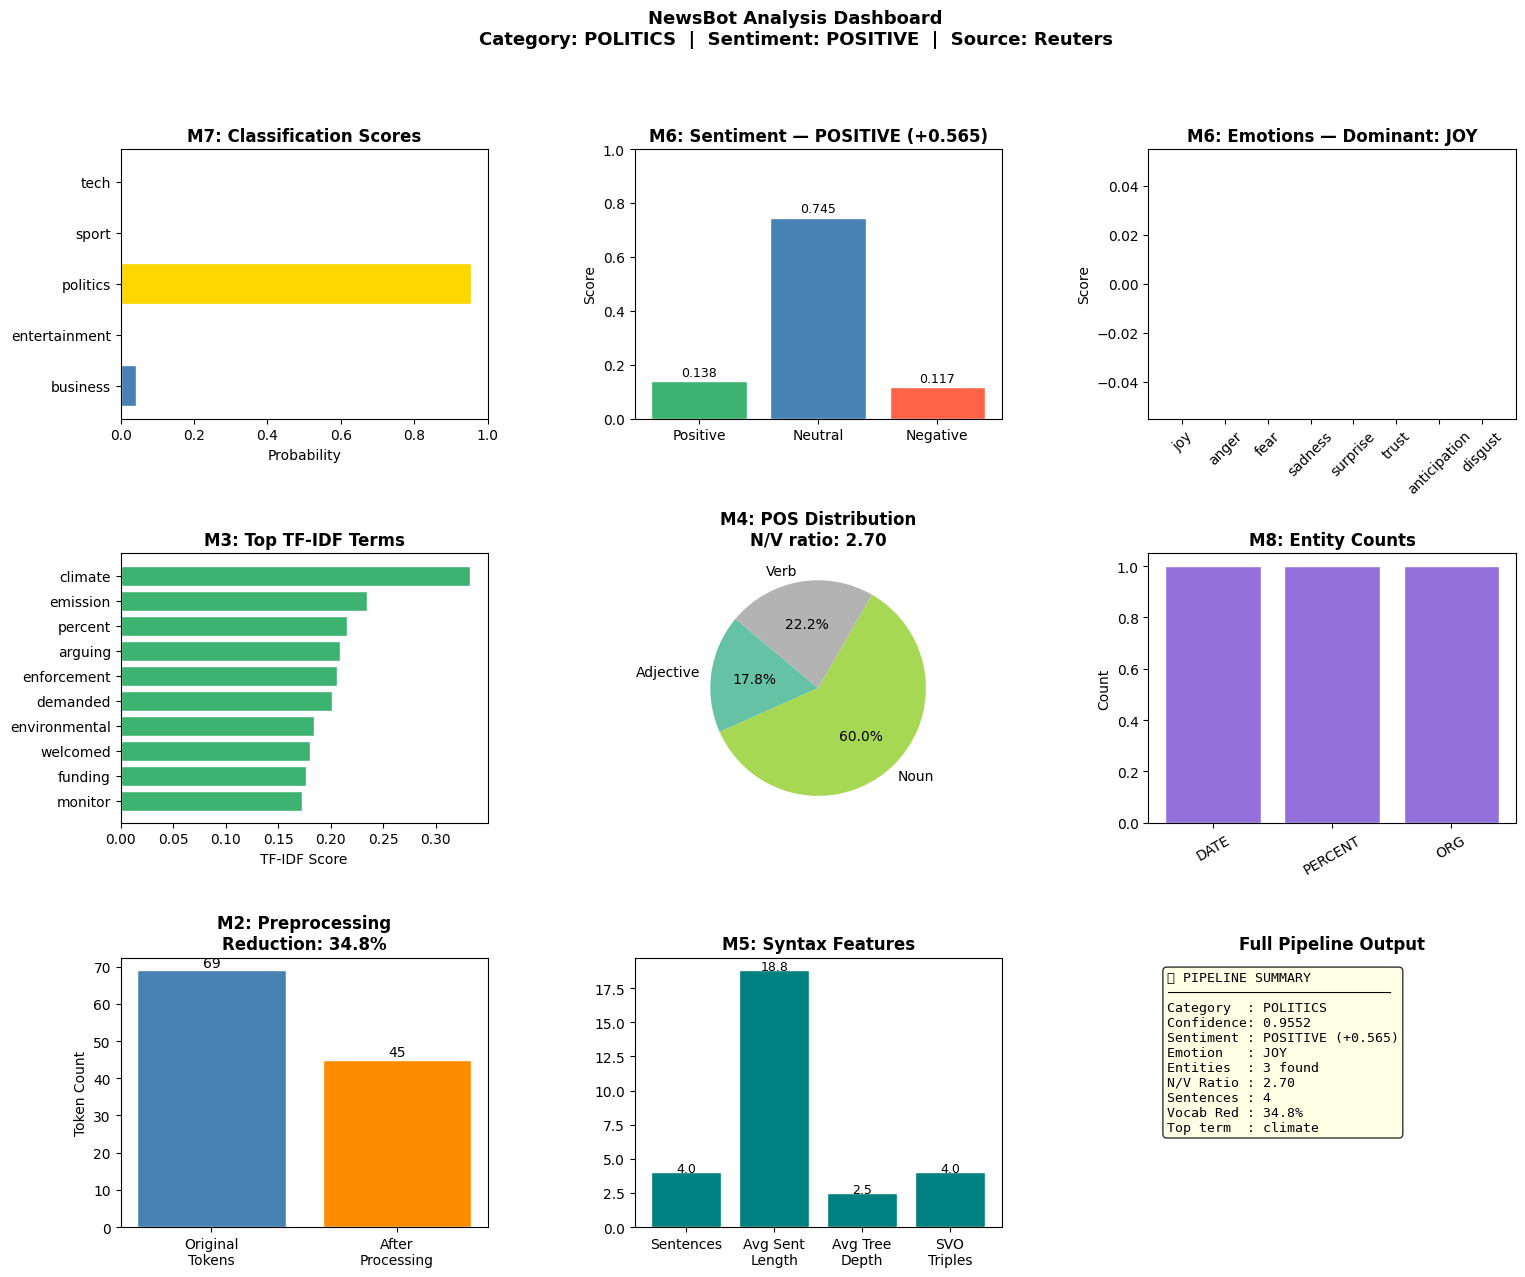

✅ Dashboard saved as 'newsbot_pipeline_dashboard.png'


📊 SECTION 4: TEST SUMMARY

  Articles tested : 5
  Correct         : 5/5
  Accuracy        : 100.0%

  Source               Expected        Predicted          ✓ Sentiment    Emotion        Entities
  ───────────────────────────────────────────────────────────────────────────────────────────────
  Reuters              POLITICS        POLITICS           ✅ positive     joy                   3
  TechCrunch           TECH            TECH               ✅ positive     anticipation          4
  BBC Sport            SPORT           SPORT              ✅ positive     joy                   9
  Financial Times      BUSINESS        BUSINESS           ✅ positive     joy                  14
  Variety              ENTERTAINMENT   ENTERTAINMENT      ✅ positive     joy                  12

  Sentiment breakdown across test articles:
    positive     5  ████████████████████████████████████████

  Entity extraction:
    Total entities found : 42
    A

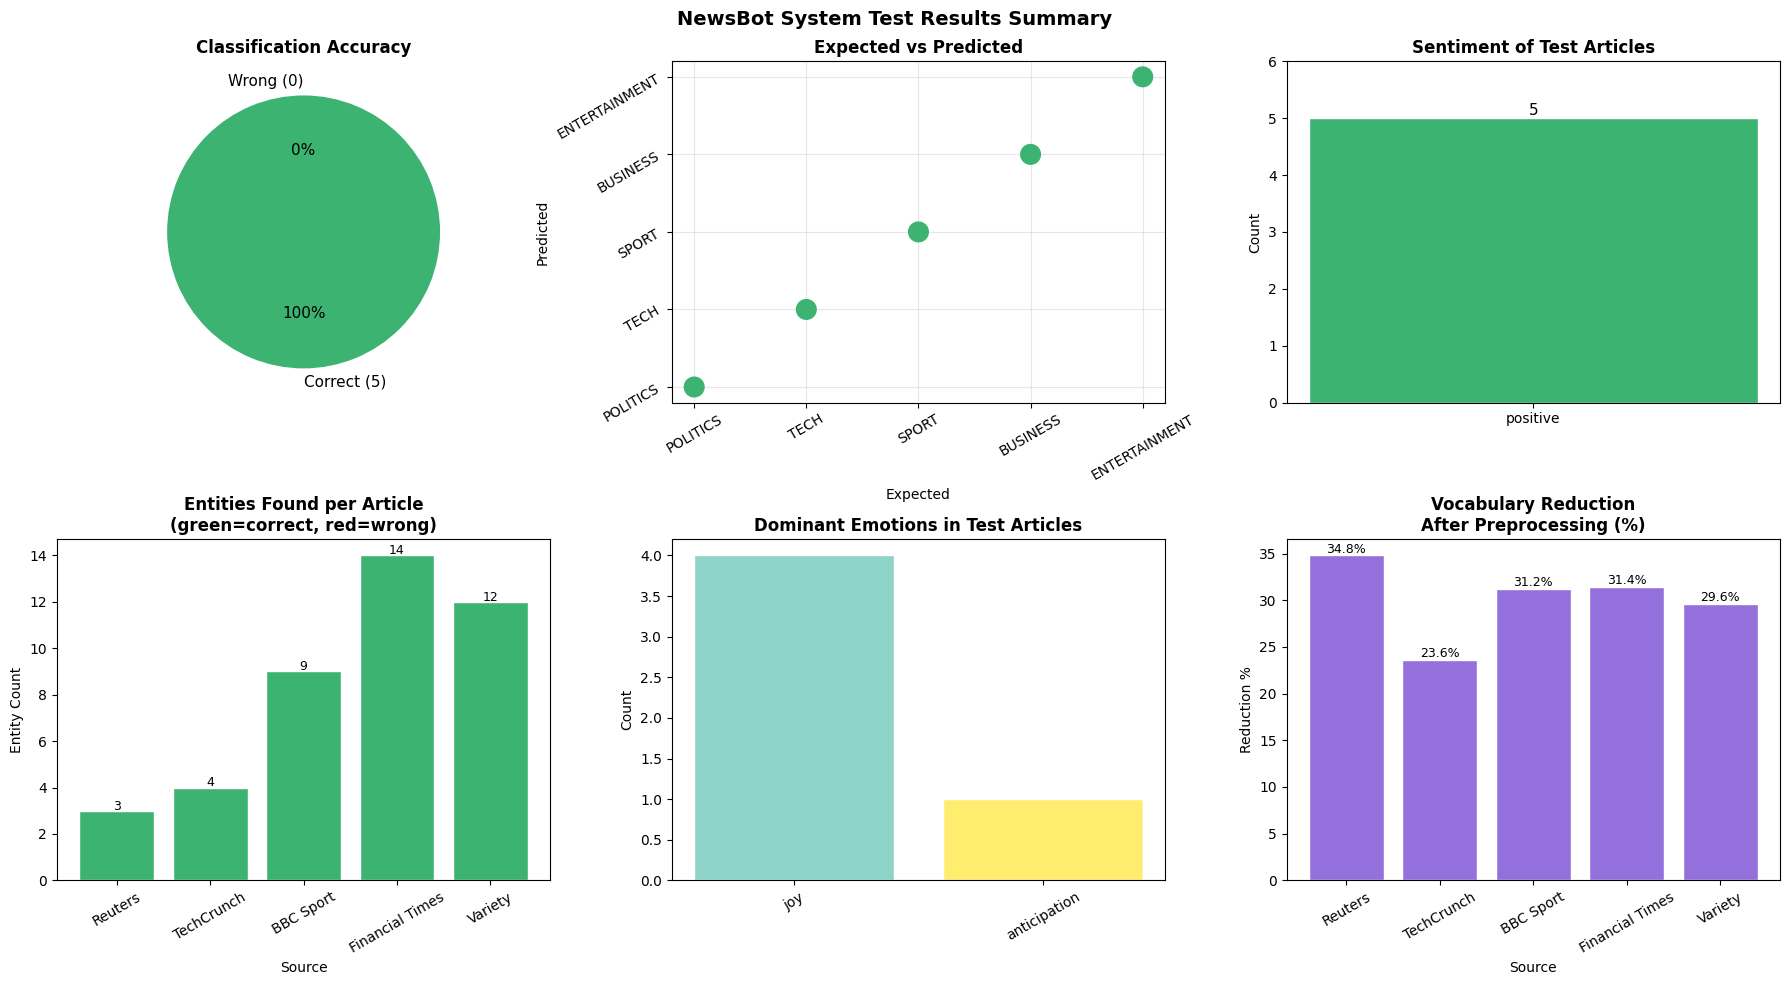


✅ Test results saved as 'newsbot_test_results.png'

  🎉 NewsBot Intelligence System — All Tests Complete!
  📁 Output files generated:
     - newsbot_test_results.png
     - newsbot_pipeline_dashboard.png
     - module2_preprocessing.png
     - module3_tfidf.png
     - module4_pos_analysis.png
     - module5_syntax.png
     - module6_sentiment.png
     - module7_classification.png
     - module8_ner.png
     - newsbot_comprehensive_dashboard.png


In [52]:
# ============================================================
# CELL 33: TESTING THE COMPLETE NEWSBOT SYSTEM
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("🧪 NEWSBOT INTELLIGENCE SYSTEM — FULL TEST")
print("=" * 65)

# ──────────────────────────────────────────────────────────
# TEST ARTICLES (NEW — not from training set)
# ──────────────────────────────────────────────────────────
test_articles = [
    {
        "label": "politics",
        "source": "Reuters",
        "text": (
            "The Prime Minister announced a sweeping new climate "
            "policy on Wednesday, pledging to cut carbon emissions "
            "by 50 percent before 2035. Parliament voted in favour "
            "of the Climate Action Bill with a majority of 320 seats "
            "to 210. Opposition leaders criticised the plan, arguing "
            "the targets are unrealistic without significant funding "
            "reform. Environmental groups welcomed the announcement "
            "but demanded stronger enforcement mechanisms and "
            "independent oversight committees to monitor progress."
        )
    },
    {
        "label": "tech",
        "source": "TechCrunch",
        "text": (
            "OpenAI unveiled its latest artificial intelligence model "
            "on Tuesday, capable of writing production-level code, "
            "analysing complex images, and solving advanced "
            "mathematical problems. The model achieved record "
            "benchmark scores across 12 industry standard tests. "
            "Tech analysts expect the release to intensify "
            "competition with Google DeepMind and Meta AI research "
            "divisions. Shares in several software companies dropped "
            "sharply following the announcement on Wall Street, with "
            "investors concerned about disruption to existing "
            "enterprise software markets."
        )
    },
    {
        "label": "sport",
        "source": "BBC Sport",
        "text": (
            "Manchester United secured a dramatic 3-2 victory "
            "against Arsenal at Old Trafford on Saturday evening. "
            "Striker Marcus Rashford scored twice in the final ten "
            "minutes to seal the comeback win, sending the home "
            "crowd into wild celebrations. The result moves United "
            "to third place in the Premier League table with eight "
            "games remaining in the season. Arsenal manager Mikel "
            "Arteta expressed deep disappointment with his team's "
            "defensive performance and vowed to make significant "
            "changes before the next fixture against Chelsea."
        )
    },
    {
        "label": "business",
        "source": "Financial Times",
        "text": (
            "Apple reported quarterly revenue of 119 billion dollars, "
            "beating analyst forecasts by 4 billion dollars in what "
            "executives called a landmark quarter. iPhone sales grew "
            "8 percent year-on-year driven by strong demand across "
            "India and Southeast Asian markets. The company announced "
            "a 90 billion dollar share buyback programme and raised "
            "its dividend by 5 percent. CEO Tim Cook cited services "
            "revenue as the fastest growing segment, rising 14 "
            "percent compared to the same period last year, with "
            "the App Store and Apple Music leading the growth."
        )
    },
    {
        "label": "entertainment",
        "source": "Variety",
        "text": (
            "The 96th Academy Awards ceremony took place in Hollywood "
            "on Sunday night with Oppenheimer dominating the evening, "
            "winning seven Oscars including Best Picture and Best "
            "Director for Christopher Nolan. Emma Stone won Best "
            "Actress for her acclaimed performance in Poor Things, "
            "while Cillian Murphy claimed Best Actor for his powerful "
            "portrayal of J. Robert Oppenheimer. The ceremony drew "
            "18 million television viewers, the highest audience in "
            "five years according to broadcast ratings data released "
            "on Monday morning by Nielsen Media Research."
        )
    },
]

# ──────────────────────────────────────────────────────────
# SECTION 1: INDIVIDUAL ARTICLE ANALYSIS
# ──────────────────────────────────────────────────────────
print(f"\n📋 SECTION 1: INDIVIDUAL ARTICLE ANALYSIS")
print("=" * 65)
print(f"Testing {len(test_articles)} new articles "
      f"not seen during training\n")

all_results = []
correct     = 0

for i, article in enumerate(test_articles, 1):
    print(f"\n{'─'*65}")
    print(f"TEST {i}/{len(test_articles)} | "
          f"Source: {article['source']} | "
          f"Expected: {article['label'].upper()}")
    print(f"{'─'*65}")

    # Run full pipeline
    result = newsbot.analyze(
        article['text'],
        source=article['source'],
        verbose=False)

    # Print full report
    newsbot.print_report(result)

    # Check prediction
    predicted = result['classification']['category'].upper()
    expected  = article['label'].upper()
    match     = predicted == expected

    if match:
        correct += 1
        status  = "✅ CORRECT"
    else:
        status  = "❌ WRONG"

    print(f"  Expected  : {expected}")
    print(f"  Predicted : {predicted}  {status}")

    all_results.append({
        'source':     article['source'],
        'expected':   expected,
        'predicted':  predicted,
        'correct':    match,
        'confidence': result['classification']['confidence'],
        'sentiment':  result['sentiment']['label'],
        'compound':   result['sentiment']['compound'],
        'emotion':    result['emotions']['dominant'],
        'entities':   sum(len(v)
                          for v in
                          result['entities'].values()),
        'word_count': result['word_count'],
        'vocab_red':  result['vocab_reduction'],
    })

# ──────────────────────────────────────────────────────────
# SECTION 2: BATCH PROCESSING TEST
# ──────────────────────────────────────────────────────────
print(f"\n\n{'='*65}")
print(f"📦 SECTION 2: BATCH PROCESSING TEST")
print("=" * 65)

batch_texts   = [a['text']   for a in test_articles]
batch_sources = [a['source'] for a in test_articles]

batch_summary = newsbot.batch_analyze(
    batch_texts, sources=batch_sources)

print(f"\n  Batch Results DataFrame:")
print(batch_summary[[
    'source','category','confidence',
    'sentiment','emotion','entities'
]].to_string(index=False))

# ──────────────────────────────────────────────────────────
# SECTION 3: PIPELINE VISUALIZATION (first article)
# ──────────────────────────────────────────────────────────
print(f"\n\n{'='*65}")
print(f"📊 SECTION 3: PIPELINE VISUALIZATION")
print("=" * 65)
print("Generating full pipeline dashboard for Article 1...")

first_result = newsbot.analyze(
    test_articles[0]['text'],
    source=test_articles[0]['source'])
newsbot.visualize_pipeline(first_result)

# ──────────────────────────────────────────────────────────
# SECTION 4: TEST SUMMARY
# ──────────────────────────────────────────────────────────
print(f"\n\n{'='*65}")
print(f"📊 SECTION 4: TEST SUMMARY")
print("=" * 65)

results_df = pd.DataFrame(all_results)

# Accuracy
accuracy = correct / len(test_articles)
print(f"\n  Articles tested : {len(test_articles)}")
print(f"  Correct         : {correct}/{len(test_articles)}")
print(f"  Accuracy        : {accuracy:.1%}")

# Per-article table
print(f"\n  {'Source':<20} {'Expected':<15} "
      f"{'Predicted':<15} {'✓':>4} "
      f"{'Sentiment':<12} {'Emotion':<14} "
      f"{'Entities':>8}")
print("  " + "─" * 95)
for _, row in results_df.iterrows():
    tick = "✅" if row['correct'] else "❌"
    print(f"  {row['source']:<20} "
          f"{row['expected']:<15} "
          f"{row['predicted']:<15} "
          f"{tick:>4} "
          f"{row['sentiment']:<12} "
          f"{row['emotion']:<14} "
          f"{row['entities']:>8}")

# Sentiment breakdown
print(f"\n  Sentiment breakdown across test articles:")
for label, count in results_df['sentiment'].value_counts().items():
    bar = '█' * (count * 8)
    print(f"    {label:<12} {count}  {bar}")

# Entity breakdown
print(f"\n  Entity extraction:")
print(f"    Total entities found : "
      f"{results_df['entities'].sum()}")
print(f"    Avg per article      : "
      f"{results_df['entities'].mean():.1f}")
print(f"    Max in one article   : "
      f"{results_df['entities'].max()}")

# Processing stats
print(f"\n  Preprocessing stats:")
print(f"    Avg vocab reduction  : "
      f"{results_df['vocab_red'].mean():.1f}%")
print(f"    Avg word count       : "
      f"{results_df['word_count'].mean():.0f}")

# ──────────────────────────────────────────────────────────
# SECTION 5: SYSTEM INFO
# ──────────────────────────────────────────────────────────
print(f"\n\n{'='*65}")
print(f"⚙️  SECTION 5: SYSTEM INFO")
print("=" * 65)
newsbot.system_info()

# ──────────────────────────────────────────────────────────
# SECTION 6: SUMMARY VISUALIZATION
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NewsBot System Test Results Summary',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

# Plot 1: Correct vs wrong pie
ax1 = axes[0]
wrong  = len(test_articles) - correct
counts = [correct, wrong]
colors = ['mediumseagreen', 'tomato']
labels = [f'Correct ({correct})', f'Wrong ({wrong})']
ax1.pie(counts, labels=labels, colors=colors,
        autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 11})
ax1.set_title('Classification Accuracy',
              fontweight='bold')

# Plot 2: Expected vs predicted
ax2 = axes[1]
x = np.arange(len(results_df))
ax2.scatter(results_df['expected'],
            results_df['predicted'],
            c=['mediumseagreen' if c else 'tomato'
               for c in results_df['correct']],
            s=200, zorder=3)
ax2.plot([results_df['expected'].unique()[0]]*2,
         [results_df['predicted'].iloc[0]]*2,
         alpha=0)
ax2.set_title('Expected vs Predicted',
              fontweight='bold')
ax2.set_xlabel('Expected')
ax2.set_ylabel('Predicted')
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=30)
ax2.grid(True, alpha=0.3)

# Plot 3: Sentiment distribution
ax3 = axes[2]
sent_counts = results_df['sentiment'].value_counts()
sent_colors = {'positive': 'mediumseagreen',
               'negative': 'tomato',
               'neutral':  'steelblue'}
ax3.bar(sent_counts.index, sent_counts.values,
        color=[sent_colors.get(s, 'gray')
               for s in sent_counts.index],
        edgecolor='white')
ax3.set_title('Sentiment of Test Articles',
              fontweight='bold')
ax3.set_ylabel('Count')
ax3.set_ylim(0, len(test_articles) + 1)
for i, val in enumerate(sent_counts.values):
    ax3.text(i, val + 0.05, str(val),
             ha='center', fontsize=11)

# Plot 4: Entities per article
ax4 = axes[3]
bar_colors = ['mediumseagreen'
              if row['correct'] else 'tomato'
              for _, row in results_df.iterrows()]
ax4.bar(results_df['source'],
        results_df['entities'],
        color=bar_colors, edgecolor='white')
ax4.set_title('Entities Found per Article\n'
              '(green=correct, red=wrong)',
              fontweight='bold')
ax4.set_xlabel('Source')
ax4.set_ylabel('Entity Count')
ax4.tick_params(axis='x', rotation=30)
for i, val in enumerate(results_df['entities']):
    ax4.text(i, val + 0.05, str(val),
             ha='center', fontsize=9)

# Plot 5: Dominant emotions
ax5 = axes[4]
emo_counts = results_df['emotion'].value_counts()
ax5.bar(emo_counts.index, emo_counts.values,
        color=plt.cm.Set3(
            np.linspace(0, 1, len(emo_counts))),
        edgecolor='white')
ax5.set_title('Dominant Emotions in Test Articles',
              fontweight='bold')
ax5.set_ylabel('Count')
ax5.tick_params(axis='x', rotation=30)

# Plot 6: Vocab reduction per article
ax6 = axes[5]
ax6.bar(results_df['source'],
        results_df['vocab_red'],
        color='mediumpurple', edgecolor='white')
ax6.set_title('Vocabulary Reduction\nAfter Preprocessing (%)',
              fontweight='bold')
ax6.set_xlabel('Source')
ax6.set_ylabel('Reduction %')
ax6.tick_params(axis='x', rotation=30)
for i, val in enumerate(results_df['vocab_red']):
    ax6.text(i, val + 0.3, f'{val:.1f}%',
             ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('newsbot_test_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Test results saved as 'newsbot_test_results.png'")
print("\n" + "=" * 65)
print("  🎉 NewsBot Intelligence System — All Tests Complete!")
print("  📁 Output files generated:")
print("     - newsbot_test_results.png")
print("     - newsbot_pipeline_dashboard.png")
print("     - module2_preprocessing.png")
print("     - module3_tfidf.png")
print("     - module4_pos_analysis.png")
print("     - module5_syntax.png")
print("     - module6_sentiment.png")
print("     - module7_classification.png")
print("     - module8_ner.png")
print("     - newsbot_comprehensive_dashboard.png")
print("=" * 65)

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [x] Complete Jupyter notebook with all analyses
- [x] Well-documented functions with docstrings
- [x] Clear markdown explanations for each section
- [x] Organized GitHub repository structure
- [x] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [x] Comprehensive dataset exploration
- [x] TF-IDF analysis with category-specific insights
- [x] POS tagging patterns across categories
- [x] Syntactic analysis with dependency parsing
- [x] Sentiment analysis with category comparisons
- [x] Classification model comparison and evaluation
- [x] Named Entity Recognition with relationship mapping
- [x] Integrated system demonstration

### 📈 Visualizations
- [x] Category distribution plots
- [x] TF-IDF word clouds or bar charts
- [x] POS pattern heatmaps
- [x] Sentiment distribution by category
- [x] Confusion matrix for classification
- [x] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [x] Written report (3-4 pages)
- [x] Individual reflection papers
- [x] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*